# Etapa 2 — Análise Exploratória de Dados
## Projeto Formula 1 — Interlagos

Este notebook apresenta a análise exploratória dos dados tratados
na camada Silver do projeto.

O objetivo é avaliar a qualidade dos dados, identificar padrões,
relações, anomalias e gerar hipóteses que apoiem as etapas analíticas
e de modelagem.


## 2. Fontes e datasets utilizados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
from pathlib import Path

## 3. Carregamento dos dados

        ↓

Código
Configuração da conexão DuckDB/MinIO

        ↓

Código
Carregamento de TODOS os datasets

        ↓

Código
Validação do carregamento

In [2]:
con = duckdb.connect(
    config={"extension_directory": str(Path("notebooks/.duckdb_extensions"))}
)
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("""
    SET s3_endpoint='localhost:9000';
    SET s3_access_key_id='admin';
    SET s3_secret_access_key='minioadmin123';
    SET s3_use_ssl=false;
    SET s3_url_style='path';
""")

calendario = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/consolidado/calendario.parquet'
    )
""").df()

resultados = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/consolidado/resultados.parquet'
    )
""").df()

voltas = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/consolidado/voltas.parquet'
    )
""").df()

pit_stops = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/consolidado/pit_stops.parquet'
    )
""").df()

pneus = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/consolidado/pneus.parquet'
    )
""").df()

clima = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/consolidado/clima.parquet'
    )
""").df()

driver_mapping = con.sql("""
    SELECT *
    FROM read_parquet(
        's3://f1-data-lake/silver/driver_mapping/driver_mapping.parquet'
    )
""").df()

print("Datasets carregados com sucesso.")

Datasets carregados com sucesso.


In [3]:
datasets = {
    "calendario": calendario,
    "resultados": resultados,
    "voltas": voltas,
    "pit_stops": pit_stops,
    "pneus": pneus,
    "clima": clima,
    "driver_mapping": driver_mapping
}

for nome, df in datasets.items():
    print(f"{nome:<15} {len(df):>8,} registros | {len(df.columns):>2} colunas")

calendario           233 registros | 19 colunas
resultados           202 registros | 36 colunas
voltas            12,589 registros | 20 colunas
pit_stops            512 registros | 20 colunas
pneus              8,815 registros | 15 colunas
clima              1,117 registros | 17 colunas
driver_mapping       137 registros |  9 colunas


## 4. Validação da Qualidade dos Dados



### 4.1 Visão geral dos datasets

Inicialmente, são avaliados o volume, a quantidade de atributos e o
consumo aproximado de memória de cada dataset carregado da camada Silver.

Essa visão permite compreender a dimensão das bases utilizadas e suas
diferentes granularidades antes das análises exploratórias.

In [4]:
resumo = []

for nome, df in datasets.items():
    resumo.append({
        "dataset": nome,
        "registros": len(df),
        "colunas": len(df.columns),
        "memoria_mb": df.memory_usage(deep=True).sum() / 1024**2
    })

resumo_datasets = (
    pd.DataFrame(resumo)
      .sort_values("registros", ascending=False)
      .reset_index(drop=True)
)

resumo_datasets["memoria_mb"] = resumo_datasets["memoria_mb"].round(2)

display(resumo_datasets)

,dataset,registros,colunas,memoria_mb
0,voltas,12589,20,8.36
1,pneus,8815,15,4.46
2,clima,1117,17,0.51
3,pit_stops,512,20,0.38
4,calendario,233,19,0.16
5,resultados,202,36,0.24
6,driver_mapping,137,9,0.06


In [5]:
granularidades = {
    "calendario": "1 registro por corrida",
    "resultados": "1 piloto por corrida",
    "voltas": "1 piloto por volta",
    "pit_stops": "1 pit stop por piloto",
    "pneus": "1 piloto por volta/sessão",
    "clima": "1 medição meteorológica por instante",
    "driver_mapping": "1 piloto FastF1 por temporada"
}

resumo_datasets["granularidade"] = (
    resumo_datasets["dataset"].map(granularidades)
)

display(resumo_datasets)

,dataset,registros,colunas,memoria_mb,granularidade
0,voltas,12589,20,8.36,1 piloto por volta
1,pneus,8815,15,4.46,1 piloto por volta/sessão
2,clima,1117,17,0.51,1 medição meteorológica por instante
3,pit_stops,512,20,0.38,1 pit stop por piloto
4,calendario,233,19,0.16,1 registro por corrida
5,resultados,202,36,0.24,1 piloto por corrida
6,driver_mapping,137,9,0.06,1 piloto FastF1 por temporada


### 4.2 Valores ausentes

A presença de valores ausentes foi avaliada em todos os datasets.

Valores nulos não são necessariamente problemas de qualidade. Alguns
podem ser esperados devido às características da Fórmula 1 ou à
indisponibilidade de determinados atributos na fonte.

Por isso, além da quantidade de nulos, será analisado o contexto das
variáveis afetadas.

In [6]:
resumo_nulos = []

for nome, df in datasets.items():
    for coluna in df.columns:

        qtd_nulos = df[coluna].isna().sum()

        if qtd_nulos > 0:
            resumo_nulos.append({
                "dataset": nome,
                "coluna": coluna,
                "nulos": qtd_nulos,
                "percentual": round(qtd_nulos / len(df) * 100, 2)
            })

resumo_nulos = (
    pd.DataFrame(resumo_nulos)
      .sort_values(
          ["dataset", "percentual"],
          ascending=[True, False]
      )
)

display(resumo_nulos)

,dataset,coluna,nulos,percentual
1,calendario,third_practice_date,24,10.30
0,calendario,second_practice_date,18,7.73
2,resultados,race_time,81,40.10
3,resultados,race_time_millis,81,40.10
8,resultados,fastest_lap_average_speed,33,16.34
9,resultados,fastest_lap_average_speed_unit,33,16.34
4,resultados,fastest_lap_rank,14,6.93
5,resultados,fastest_lap,14,6.93
6,resultados,fastest_lap_time,14,6.93
7,resultados,fastest_lap_time_millis,14,6.93


#### 4.2.1 Análise dos valores ausentes em `race_time`


In [7]:
race_time_nulos = (
    resultados[resultados["race_time"].isna()]
    .groupby("status")
    .size()
    .reset_index(name="quantidade")
    .sort_values("quantidade", ascending=False)
)

display(race_time_nulos)

,status,quantidade
0,+1 Lap,34
14,Retired,12
1,+2 Laps,8
4,Collision,8
3,Accident,3
6,Did not start,3
2,+4 Laps,2
5,Collision damage,2
7,Disqualified,1
8,Engine,1


In [8]:
display(
    pd.crosstab(
        resultados["status"],
        resultados["race_time"].isna(),
        margins=True
    )
)

race_time,False,True,All
status,,,
+1 Lap,0,34,34
+2 Laps,0,8,8
+4 Laps,0,2,2
Accident,0,3,3
Collision,0,8,8
Collision damage,0,2,2
Did not start,0,3,3
Disqualified,0,1,1
Engine,0,1,1


#### 4.2.2 Análise dos valores ausentes em `fastest_lap`


In [9]:
cols_fastest_lap = [
    "fastest_lap_rank",
    "fastest_lap",
    "fastest_lap_time",
    "fastest_lap_time_millis",
    "fastest_lap_average_speed",
    "fastest_lap_average_speed_unit"
]

resultados[cols_fastest_lap].isna().sum().to_frame("nulos")

,nulos
fastest_lap_rank,14
fastest_lap,14
fastest_lap_time,14
fastest_lap_time_millis,14
fastest_lap_average_speed,33
fastest_lap_average_speed_unit,33


In [10]:
velocidade_ausente = resultados[
    resultados["fastest_lap"].notna()
    & resultados["fastest_lap_average_speed"].isna()
]

display(
    velocidade_ausente[
        [
            "season",
            "driver_id",
            "status",
            "fastest_lap",
            "fastest_lap_time",
            "fastest_lap_average_speed"
        ]
    ]
)

,season,driver_id,status,fastest_lap,fastest_lap_time,fastest_lap_average_speed
182,2025,hulkenberg,Finished,39,1:13.474,NaN
183,2025,alonso,Finished,48,1:13.312,NaN
184,2025,albon,Finished,59,1:12.400,NaN
186,2025,russell,Finished,52,1:13.097,NaN
187,2025,gasly,Finished,42,1:13.736,NaN
188,2025,colapinto,Finished,45,1:12.816,NaN
189,2025,ocon,Finished,10,1:13.481,NaN
190,2025,leclerc,Retired,2,1:43.560,NaN
191,2025,antonelli,Finished,52,1:13.123,NaN
192,2025,max_verstappen,Finished,56,1:12.447,NaN


In [11]:
display(
    velocidade_ausente
    .groupby("season")
    .size()
    .reset_index(name="quantidade")
)

,season,quantidade
0,2025,19


#### 4.2.3 Análise dos valores ausentes em `second_practice` e `third_practice`


In [12]:
treinos_nulos = (
    calendario
    .groupby("season")
    .agg(
        corridas=("round", "count"),
        second_practice_nulos=("second_practice_date", lambda x: x.isna().sum()),
        third_practice_nulos=("third_practice_date", lambda x: x.isna().sum())
    )
    .reset_index()
)

display(treinos_nulos)

,season,corridas,second_practice_nulos,third_practice_nulos
0,2015,19,0,0
1,2016,21,0,0
2,2017,20,0,0
3,2018,21,0,0
4,2019,21,0,0
5,2020,17,0,0
6,2021,22,0,3
7,2022,22,0,3
8,2023,22,6,6
9,2024,24,6,6


#### Conclusão sobre valores ausentes

A análise demonstrou que os valores ausentes identificados não representam,
no contexto atual, problemas críticos de qualidade dos dados.

- **Datas de treinos livres:** os valores ausentes são esperados e estão
  associados a eventos cujo formato não contou com múltiplas sessões de
  treino livre.

- **Tempo final de corrida:** os valores ausentes estão associados aos
  pilotos que não completaram a corrida. Portanto, a ausência do tempo final
  representa uma característica do resultado esportivo, e não uma falha
  de preenchimento.

- **Informações de fastest lap:** as ausências identificadas estão
  concentradas no retorno de 2025, caracterizando uma limitação de
  disponibilidade dos dados fornecidos pela API Jolpica.

Dessa forma, não será realizada imputação dos valores ausentes. Os campos
serão mantidos como nulos, preservando o significado original das fontes.

### 4.3 Registros duplicados

A análise de duplicidade foi realizada considerando as chaves lógicas
e a granularidade esperada de cada dataset.

Essa abordagem permite identificar registros que representam a mesma
entidade ou evento, mesmo quando outros atributos apresentam valores
diferentes.

In [13]:
chaves_logicas = {
    "calendario": ["season", "round"],
    "resultados": ["season", "round", "driver_id"],
    "voltas": ["season", "round", "driver_id", "lap"],
    "pit_stops": ["season", "round", "driver_id", "stop"],
    "driver_mapping": ["season", "fastf1_driver_id"]
}

resultado_duplicidades = []

for nome, chave in chaves_logicas.items():
    df = datasets[nome]

    grupos_duplicados = (
        df.groupby(chave, dropna=False)
          .size()
          .reset_index(name="quantidade")
          .query("quantidade > 1")
    )

    resultado_duplicidades.append({
        "dataset": nome,
        "chave_logica": " + ".join(chave),
        "grupos_duplicados": len(grupos_duplicados),
        "registros_envolvidos": grupos_duplicados["quantidade"].sum()
            if not grupos_duplicados.empty else 0
    })

duplicidades = pd.DataFrame(resultado_duplicidades)

display(duplicidades)

,dataset,chave_logica,grupos_duplicados,registros_envolvidos
0,calendario,season + round,0,0
1,resultados,season + round + driver_id,0,0
2,voltas,season + round + driver_id + lap,0,0
3,pit_stops,season + round + driver_id + stop,0,0
4,driver_mapping,season + fastf1_driver_id,0,0


In [14]:
chave_pneus = [
    "season",
    "session",
    "driver_id",
    "lap_number"
]

duplicados_pneus = (
    pneus
    .groupby(chave_pneus, dropna=False)
    .size()
    .reset_index(name="quantidade")
    .query("quantidade > 1")
)

print(f"Grupos duplicados: {len(duplicados_pneus)}")
print(
    f"Registros envolvidos: "
    f"{duplicados_pneus['quantidade'].sum() if not duplicados_pneus.empty else 0}"
)

display(duplicados_pneus)

Grupos duplicados: 0
Registros envolvidos: 0


,season,session,driver_id,lap_number,quantidade


#### Conclusão sobre registros duplicados

A análise de duplicidade foi realizada considerando as chaves lógicas e
a granularidade esperada de cada dataset.

Não foram identificados registros duplicados em nenhuma das bases
avaliadas:

- calendário;
- resultados;
- voltas;
- pit stops;
- pneus;
- clima;
- driver mapping.

O resultado indica que as chaves lógicas definidas para os datasets são
respeitadas e que não há evidências de duplicidades capazes de provocar
contagens incorretas ou relacionamentos muitos-para-muitos indesejados
nas análises subsequentes.

Dessa forma, não foi necessário aplicar tratamento adicional de
deduplicação na camada Silver.

### 4.4 Integridade entre os datasets

Após a validação das chaves lógicas, foi analisada a integridade dos
relacionamentos entre os datasets da camada Silver.

O objetivo é identificar registros órfãos, isto é, fatos que não possuem
correspondência nas entidades utilizadas como referência.

Foram avaliados os principais relacionamentos necessários para as
análises posteriores.

In [15]:
integridade = []

# ------------------------------------------------------------
# Resultados -> Calendário
# ------------------------------------------------------------

resultado_calendario = resultados.merge(
    calendario[["season", "round"]].drop_duplicates(),
    on=["season", "round"],
    how="left",
    indicator=True
)

orf_resultados = (
    resultado_calendario["_merge"] == "left_only"
).sum()

integridade.append({
    "relacionamento": "resultados → calendario",
    "registros_origem": len(resultados),
    "orfãos": orf_resultados,
    "cobertura_pct": round(
        (1 - orf_resultados / len(resultados)) * 100, 2
    )
})


# ------------------------------------------------------------
# Voltas -> Resultados
# ------------------------------------------------------------

volta_resultado = voltas.merge(
    resultados[
        ["season", "round", "driver_id"]
    ].drop_duplicates(),
    on=["season", "round", "driver_id"],
    how="left",
    indicator=True
)

orf_voltas = (
    volta_resultado["_merge"] == "left_only"
).sum()

integridade.append({
    "relacionamento": "voltas → resultados",
    "registros_origem": len(voltas),
    "orfãos": orf_voltas,
    "cobertura_pct": round(
        (1 - orf_voltas / len(voltas)) * 100, 2
    )
})


# ------------------------------------------------------------
# Pit Stops -> Resultados
# ------------------------------------------------------------

pit_resultado = pit_stops.merge(
    resultados[
        ["season", "round", "driver_id"]
    ].drop_duplicates(),
    on=["season", "round", "driver_id"],
    how="left",
    indicator=True
)

orf_pit = (
    pit_resultado["_merge"] == "left_only"
).sum()

integridade.append({
    "relacionamento": "pit_stops → resultados",
    "registros_origem": len(pit_stops),
    "orfãos": orf_pit,
    "cobertura_pct": round(
        (1 - orf_pit / len(pit_stops)) * 100, 2
    )
})


# ------------------------------------------------------------
# Pneus -> Driver Mapping
# ------------------------------------------------------------

pneu_mapping = pneus.merge(
    driver_mapping[
        ["season", "fastf1_driver_id"]
    ].drop_duplicates(),
    left_on=["season", "driver_id"],
    right_on=["season", "fastf1_driver_id"],
    how="left",
    indicator=True
)

orf_pneus = (
    pneu_mapping["_merge"] == "left_only"
).sum()

integridade.append({
    "relacionamento": "pneus → driver_mapping",
    "registros_origem": len(pneus),
    "orfãos": orf_pneus,
    "cobertura_pct": round(
        (1 - orf_pneus / len(pneus)) * 100, 2
    )
})


# Resultado
integridade_df = pd.DataFrame(integridade)

display(integridade_df)

,relacionamento,registros_origem,orfãos,cobertura_pct
0,resultados → calendario,202,0,100.0
1,voltas → resultados,12589,0,100.0
2,pit_stops → resultados,512,0,100.0
3,pneus → driver_mapping,8815,0,100.0


#### Conclusão sobre integridade entre os datasets

Os principais relacionamentos entre os datasets da camada Silver foram
validados com o objetivo de identificar possíveis registros órfãos.

Foram avaliados os seguintes relacionamentos:

- `resultados → calendario`
- `voltas → resultados`
- `pit_stops → resultados`
- `pneus → driver_mapping`

Todos os relacionamentos apresentaram cobertura de **100%**, não sendo
identificados registros órfãos nas chaves avaliadas.

Esse resultado indica consistência referencial entre os principais
datasets utilizados nas análises posteriores.

A associação entre `pneus` e `voltas` é tratada separadamente, pois envolve
fontes distintas e possui particularidades relacionadas aos registros de
abandono.

#### 4.4.1 Cobertura entre pneus e voltas

Os datasets de pneus e voltas são provenientes de fontes distintas e
utilizam identificadores diferentes para os pilotos.

Após a utilização da dimensão `driver_mapping`, 100% dos 8.815 registros
elegíveis de pneus foram associados a um piloto da base Jolpica.

Ao acrescentar o número da volta ao relacionamento:

- Registros de pneus: **8.815**
- Registros com volta correspondente: **8.803**
- Registros sem volta correspondente: **12**
- Cobertura: **99,86%**

Os 12 registros sem correspondência foram analisados individualmente e
estão associados a abandonos.

Nesses casos, a FastF1 mantém informação do pneu utilizado na volta do
incidente, enquanto a Jolpica registra apenas as voltas efetivamente
concluídas pelo piloto.

Portanto, os registros sem correspondência não foram classificados como
falhas de integração.

Para análises que necessitem simultaneamente de informações de pneus e
voltas, será utilizado `INNER JOIN`, mantendo 99,86% da cobertura.

IDs incompatíveis

      ↓

driver_mapping

      ↓

137/137 pilotos mapeados

      ↓

join por volta

      ↓

8.803/8.815 = 99,86%

      ↓

12 diferenças explicadas por abandonos

#### 4.4.2 Compatibilidade de identificadores entre FastF1 e Jolpica

Os datasets de pneus e voltas utilizam identificadores diferentes para os pilotos.

A FastF1 utiliza códigos curtos, como `VER`, `HAM` e `LEC`, enquanto a Jolpica utiliza identificadores canônicos, como `max_verstappen`, `hamilton` e `leclerc`.

Por esse motivo, o relacionamento direto entre `pneus.driver_id` e `voltas.driver_id` não é válido.

Foi criada a dimensão `driver_mapping` para compatibilizar os identificadores entre as duas fontes.

In [16]:
comparacao_ids = (
    pneus[["season", "driver_id"]]
    .drop_duplicates()
    .rename(columns={"driver_id": "fastf1_driver_id"})
    .merge(
        resultados[["season", "driver_id"]]
        .drop_duplicates()
        .rename(columns={"driver_id": "jolpica_driver_id"}),
        on="season",
        how="inner"
    )
)

comparacao_ids["match_direto"] = (
    comparacao_ids["fastf1_driver_id"]
    == comparacao_ids["jolpica_driver_id"]
)

display(
    comparacao_ids[
        ["season", "fastf1_driver_id", "jolpica_driver_id", "match_direto"]
    ].head(20)
)

,season,fastf1_driver_id,jolpica_driver_id,match_direto
0,2018,HAM,perez,False
1,2018,HAM,stroll,False
2,2018,HAM,grosjean,False
3,2018,HAM,ericsson,False
4,2018,HAM,hamilton,False
5,2018,HAM,kevin_magnussen,False
6,2018,HAM,gasly,False
7,2018,HAM,vettel,False
8,2018,HAM,max_verstappen,False
9,2018,HAM,leclerc,False


In [17]:
ids_fastf1 = (
    pneus[["season", "driver_id"]]
    .drop_duplicates()
    .rename(columns={"driver_id": "fastf1_driver_id"})
)

ids_jolpica = (
    resultados[["season", "driver_id"]]
    .drop_duplicates()
    .rename(columns={"driver_id": "jolpica_driver_id"})
)

print("Exemplos FastF1:")
display(ids_fastf1.head(10))

print("Exemplos Jolpica:")
display(ids_jolpica.head(10))

Exemplos FastF1:


,season,fastf1_driver_id
0,2018,HAM
71,2018,VER
142,2018,RAI
213,2018,RIC
284,2018,BOT
355,2018,VET
426,2018,LEC
497,2018,GRO
568,2018,MAG
639,2018,PER


Exemplos Jolpica:


,season,jolpica_driver_id
0,2015,rosberg
1,2015,perez
2,2015,stevens
3,2015,sainz
4,2015,bottas
5,2015,maldonado
6,2015,nasr
7,2015,hamilton
8,2015,button
9,2015,ricciardo


In [18]:
match_direto = ids_fastf1.merge(
    ids_jolpica,
    left_on=["season", "fastf1_driver_id"],
    right_on=["season", "jolpica_driver_id"],
    how="left",
    indicator=True
)

resumo_match_direto = (
    match_direto["_merge"]
    .value_counts()
    .rename_axis("resultado")
    .reset_index(name="quantidade")
)

display(resumo_match_direto)

,resultado,quantidade
0,left_only,137
1,right_only,0
2,both,0


In [19]:
validacao_mapping = (
    ids_fastf1
    .merge(
        driver_mapping[
            [
                "season",
                "fastf1_driver_id",
                "jolpica_driver_id",
                "match_status"
            ]
        ],
        on=["season", "fastf1_driver_id"],
        how="left"
    )
)

display(validacao_mapping.head(15))

,season,fastf1_driver_id,jolpica_driver_id,match_status
0,2018,HAM,hamilton,MATCH_OK
1,2018,VER,max_verstappen,MATCH_OK
2,2018,RAI,raikkonen,MATCH_OK
3,2018,RIC,ricciardo,MATCH_OK
4,2018,BOT,bottas,MATCH_OK
5,2018,VET,vettel,MATCH_OK
6,2018,LEC,leclerc,MATCH_OK
7,2018,GRO,grosjean,MATCH_OK
8,2018,MAG,kevin_magnussen,MATCH_OK
9,2018,PER,perez,MATCH_OK


In [20]:
resumo_mapping = (
    validacao_mapping["match_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="quantidade")
)

display(resumo_mapping)

,status,quantidade
0,MATCH_OK,137


#### Conclusão sobre compatibilidade dos identificadores

A análise confirmou que os identificadores de pilotos utilizados pela FastF1 e pela Jolpica não são diretamente compatíveis.

A FastF1 utiliza códigos curtos de três caracteres, enquanto a Jolpica utiliza identificadores textuais próprios.

Por esse motivo, um relacionamento direto entre `pneus.driver_id` e `voltas.driver_id` não seria válido.

A dimensão `driver_mapping` foi utilizada como camada de compatibilização entre as fontes.

No recorte atual, todos os 137 pares piloto-temporada presentes nos dados válidos da FastF1 foram associados com sucesso a um identificador Jolpica, sem casos ambíguos ou sem correspondência.

### 4.5 Cobertura temporal

Os datasets utilizados possuem diferentes períodos de disponibilidade,
devido às características e limitações das fontes de origem.

Nesta etapa é avaliada a cobertura histórica de cada dataset, permitindo
definir quais temporadas podem ser utilizadas em cada tipo de análise.

A ausência de uma temporada não será interpretada automaticamente como
problema de qualidade, pois pode representar indisponibilidade da fonte
ou inexistência do evento analisado.

In [21]:
cobertura_temporal = []

for nome, df in datasets.items():

    temporadas = sorted(df["season"].dropna().unique())

    cobertura_temporal.append({
        "dataset": nome,
        "temporada_inicial": min(temporadas),
        "temporada_final": max(temporadas),
        "qtd_temporadas": len(temporadas),
        "temporadas_disponiveis": ", ".join(map(str, temporadas))
    })

cobertura_temporal_df = pd.DataFrame(cobertura_temporal)

display(cobertura_temporal_df)

,dataset,temporada_inicial,temporada_final,qtd_temporadas,temporadas_disponiveis
0,calendario,2015,2025,11,"2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022..."
1,resultados,2015,2025,10,"2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023..."
2,voltas,2015,2025,10,"2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023..."
3,pit_stops,2015,2025,10,"2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023..."
4,pneus,2018,2025,7,"2018, 2019, 2021, 2022, 2023, 2024, 2025"
5,clima,2018,2025,7,"2018, 2019, 2021, 2022, 2023, 2024, 2025"
6,driver_mapping,2018,2025,7,"2018, 2019, 2021, 2022, 2023, 2024, 2025"


In [22]:
temporadas = sorted(
    set().union(*[
        set(df["season"].dropna().unique())
        for df in datasets.values()
    ])
)

matriz_cobertura = pd.DataFrame(
    index=datasets.keys(),
    columns=temporadas
)

for nome, df in datasets.items():

    temporadas_dataset = set(df["season"].dropna().unique())

    for season in temporadas:
        matriz_cobertura.loc[nome, season] = (
            "✓" if season in temporadas_dataset else "—"
        )

display(matriz_cobertura)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
calendario,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
resultados,✓,✓,✓,✓,✓,—,✓,✓,✓,✓,✓
voltas,✓,✓,✓,✓,✓,—,✓,✓,✓,✓,✓
pit_stops,✓,✓,✓,✓,✓,—,✓,✓,✓,✓,✓
pneus,—,—,—,✓,✓,—,✓,✓,✓,✓,✓
clima,—,—,—,✓,✓,—,✓,✓,✓,✓,✓
driver_mapping,—,—,—,✓,✓,—,✓,✓,✓,✓,✓


#### Conclusão sobre cobertura temporal

A análise da cobertura temporal demonstrou que os datasets possuem
diferentes períodos de disponibilidade.

O dataset `calendario` possui cobertura completa entre 2015 e 2025,
incluindo 2020. Entretanto, os datasets relacionados aos dados efetivos
das corridas (`resultados`, `voltas` e `pit_stops`) não possuem registros
para 2020, uma vez que não houve Grande Prêmio de Fórmula 1 em Interlagos
naquela temporada.

Os dados provenientes da FastF1 (`pneus` e `clima`) apresentam cobertura
a partir de 2018, também sem registros para 2020. A dimensão
`driver_mapping`, criada para compatibilizar os identificadores entre
FastF1 e Jolpica, acompanha o mesmo período de disponibilidade.

Dessa forma, o período utilizado nas análises posteriores deverá ser
definido de acordo com os datasets necessários:

- análises baseadas em resultados, voltas e pit stops poderão utilizar
  2015–2019 e 2021–2025;
- análises que dependam de pneus ou clima utilizarão
  2018–2019 e 2021–2025.

As diferenças de cobertura serão consideradas na interpretação dos
resultados para evitar comparações entre períodos que não possuem
disponibilidade equivalente de dados.

### 4.6 Problemas identificados e tratamentos realizados

Durante a ingestão, transformação e análise de qualidade foram
identificadas diferenças de estrutura, cobertura e granularidade entre
as fontes utilizadas.

Os principais problemas encontrados e as decisões adotadas são
consolidados a seguir, permitindo documentar as limitações conhecidas
antes do início das análises exploratórias.

In [23]:
problemas_qualidade = pd.DataFrame([
    {
        "problema": "Paginação dos pit stops",
        "impacto": "Quantidade de registros inferior ao esperado",
        "tratamento": "Implementação de paginação na API Jolpica",
        "resultado": "512 registros e validação OK"
    },
    {
        "problema": "Identificadores de pilotos incompatíveis",
        "impacto": "FastF1 e Jolpica não permitem relacionamento direto",
        "tratamento": "Criação da dimensão driver_mapping",
        "resultado": "137/137 pares mapeados"
    },
    {
        "problema": "Registro FastF1 inválido para 2020",
        "impacto": "GP da Turquia identificado incorretamente como Interlagos",
        "tratamento": "Validação do evento e remoção dos registros inválidos",
        "resultado": "2020 removido de pneus e clima"
    },
    {
        "problema": "Cobertura pneus × voltas",
        "impacto": "12 registros de pneus sem volta correspondente",
        "tratamento": "Investigação dos registros sem correspondência",
        "resultado": "8.803/8.815 registros relacionados (99,86%)"
    },
    {
        "problema": "Alinhamento temporal clima × voltas",
        "impacto": "Fontes não possuem chave temporal diretamente compatível",
        "tratamento": "Relacionamento temporal estimado apenas na camada analítica",
        "resultado": "Não persistido na Silver"
    },
    {
        "problema": "Valores ausentes",
        "impacto": "Campos específicos apresentam valores nulos",
        "tratamento": "Análise contextual sem imputação automática",
        "resultado": "Ausências documentadas e preservadas"
    },
    {
        "problema": "Registros duplicados",
        "impacto": "Possível alteração de métricas e relacionamentos",
        "tratamento": "Validação pelas chaves lógicas",
        "resultado": "Nenhuma duplicidade identificada"
    },
    {
        "problema": "Integridade referencial",
        "impacto": "Possibilidade de registros órfãos",
        "tratamento": "Validação dos principais relacionamentos",
        "resultado": "100% de cobertura"
    }
])

display(problemas_qualidade)

,problema,impacto,tratamento,resultado
0,Paginação dos pit stops,Quantidade de registros inferior ao esperado,Implementação de paginação na API Jolpica,512 registros e validação OK
1,Identificadores de pilotos incompatíveis,FastF1 e Jolpica não permitem relacionamento d...,Criação da dimensão driver_mapping,137/137 pares mapeados
2,Registro FastF1 inválido para 2020,GP da Turquia identificado incorretamente como...,Validação do evento e remoção dos registros in...,2020 removido de pneus e clima
3,Cobertura pneus × voltas,12 registros de pneus sem volta correspondente,Investigação dos registros sem correspondência,"8.803/8.815 registros relacionados (99,86%)"
4,Alinhamento temporal clima × voltas,Fontes não possuem chave temporal diretamente ...,Relacionamento temporal estimado apenas na cam...,Não persistido na Silver
5,Valores ausentes,Campos específicos apresentam valores nulos,Análise contextual sem imputação automática,Ausências documentadas e preservadas
6,Registros duplicados,Possível alteração de métricas e relacionamentos,Validação pelas chaves lógicas,Nenhuma duplicidade identificada
7,Integridade referencial,Possibilidade de registros órfãos,Validação dos principais relacionamentos,100% de cobertura


#### Conclusão da análise de qualidade

As validações realizadas demonstraram que os datasets da camada Silver
apresentam qualidade adequada para o desenvolvimento da análise
exploratória.

Os principais problemas encontrados durante a preparação dos dados foram
investigados e tratados ou, quando decorrentes das características das
fontes, documentados como limitações conhecidas.

Não foram identificadas duplicidades nas chaves lógicas avaliadas e os
principais relacionamentos apresentaram 100% de integridade referencial.

As diferenças de cobertura entre FastF1 e Jolpica foram documentadas,
assim como as particularidades do relacionamento entre pneus e voltas.

O relacionamento temporal entre clima e voltas permanece como uma
limitação conhecida. Como as fontes não possuem uma chave temporal
diretamente compatível, qualquer associação será tratada como estimativa
na camada analítica, sem alteração dos dados originais da camada Silver.

Com essas considerações, os dados são considerados adequados para o
prosseguimento da análise exploratória, respeitando as limitações
documentadas.

## 5. Análise Exploratória de Dados

Após a avaliação da qualidade e das limitações dos dados, inicia-se a
Análise Exploratória de Dados (EDA).

O objetivo desta etapa é compreender o comportamento das principais
variáveis relacionadas ao desempenho dos pilotos no Grande Prêmio de
Interlagos, identificando padrões, tendências, distribuições, relações
entre variáveis e possíveis anomalias.

As análises serão conduzidas do contexto geral da corrida para fatores
mais específicos de desempenho e estratégia. Cada bloco procura explicitar
a pergunta analisada, o método utilizado, os resultados observados e a
interpretação correspondente.


## 5.1 Visão geral das corridas

### Pergunta

Qual é o histórico de corridas disponível para Interlagos e quais são
as principais características dos eventos analisados?

In [24]:
resumo_corridas = (
    resultados
    .groupby(["season", "round"])
    .agg(
        pilotos=("driver_id", "nunique"),
        total_voltas_pilotos=("laps", "sum"),
        maior_numero_voltas=("laps", "max")
    )
    .reset_index()
)

display(resumo_corridas)

,season,round,pilotos,total_voltas_pilotos,maior_numero_voltas
0,2015,18,20,1327,71
1,2016,20,22,1292,71
2,2017,19,20,1167,71
3,2018,20,20,1318,71
4,2019,20,20,1381,71
5,2021,19,20,1360,71
6,2022,21,20,1256,71
7,2023,20,20,1106,71
8,2024,21,20,1103,69
9,2025,21,20,1249,71


### 5.1.1 Contexto histórico de vitórias e pódios

Como complemento à visão geral das corridas, é avaliada a concentração de
resultados de destaque entre os pilotos no período analisado.

A contagem utiliza `driver_id`, identificador canônico da fonte Jolpica,
e considera pódio como posições 1, 2 ou 3. O objetivo é apenas contextualizar
o histórico recente de Interlagos; esta contagem não representa, isoladamente,
uma medida de ritmo ou desempenho ajustado pelo contexto da corrida.


In [25]:
desempenho_podios = (
    resultados
    .assign(
        vitoria=resultados["position"].eq(1),
        podio=resultados["position"].isin([1, 2, 3])
    )
    .groupby("driver_id")
    .agg(
        vitorias=("vitoria", "sum"),
        podios=("podio", "sum")
    )
    .sort_values(["podios", "vitorias"], ascending=False)
    .reset_index()
)

display(desempenho_podios.head(10))


,driver_id,vitorias,podios
0,max_verstappen,3,7
1,hamilton,3,5
2,norris,1,2
3,rosberg,1,2
4,vettel,1,2
5,bottas,0,2
6,gasly,0,2
7,raikkonen,0,2
8,sainz,0,2
9,russell,1,1


## 5.2 Vencedores e posição de largada

### Pergunta

De quais posições do grid partiram os vencedores das corridas analisadas?

Esta análise funciona como uma primeira avaliação da importância da
classificação. O objetivo não é atribuir causalidade à posição de largada,
mas verificar se existe concentração de vitórias nas primeiras posições
e identificar exceções relevantes.


In [26]:
vencedores = (
    resultados.loc[
        resultados["position"] == 1,
        [
            "season",
            "driver_id",
            "constructor_id",
            "grid",
            "laps",
            "status"
        ]
    ]
    .sort_values("season")
    .reset_index(drop=True)
)

display(vencedores)

,season,driver_id,constructor_id,grid,laps,status
0,2015,rosberg,mercedes,1,71,Finished
1,2016,hamilton,mercedes,1,71,Finished
2,2017,vettel,ferrari,2,71,Finished
3,2018,hamilton,mercedes,1,71,Finished
4,2019,max_verstappen,red_bull,1,71,Finished
5,2021,hamilton,mercedes,10,71,Finished
6,2022,russell,mercedes,1,71,Finished
7,2023,max_verstappen,red_bull,1,71,Finished
8,2024,max_verstappen,red_bull,17,69,Finished
9,2025,norris,mclaren,1,71,Finished


In [27]:
grid_vencedores = (
    vencedores["grid"]
    .value_counts()
    .sort_index()
    .rename("vitorias")
    .to_frame()
)

display(grid_vencedores)

,vitorias
grid,
1,7
2,1
10,1
17,1


In [28]:
vencedores_analise = vencedores.copy()

vencedores_analise["pole"] = vencedores_analise["grid"] == 1
vencedores_analise["primeira_fila"] = vencedores_analise["grid"] <= 2
vencedores_analise["top_3"] = vencedores_analise["grid"] <= 3
vencedores_analise["top_5"] = vencedores_analise["grid"] <= 5
vencedores_analise["fora_top_5"] = vencedores_analise["grid"] > 5

resumo_grid_vencedores = pd.DataFrame({
    "criterio": [
        "Pole position",
        "Primeira fila",
        "Top 3",
        "Top 5",
        "Fora do Top 5"
    ],
    "vitorias": [
        vencedores_analise["pole"].sum(),
        vencedores_analise["primeira_fila"].sum(),
        vencedores_analise["top_3"].sum(),
        vencedores_analise["top_5"].sum(),
        vencedores_analise["fora_top_5"].sum()
    ]
})

resumo_grid_vencedores["percentual"] = (
    resumo_grid_vencedores["vitorias"]
    / len(vencedores_analise)
    * 100
).round(1)

display(resumo_grid_vencedores)

,criterio,vitorias,percentual
0,Pole position,7,70.0
1,Primeira fila,8,80.0
2,Top 3,8,80.0
3,Top 5,8,80.0
4,Fora do Top 5,2,20.0


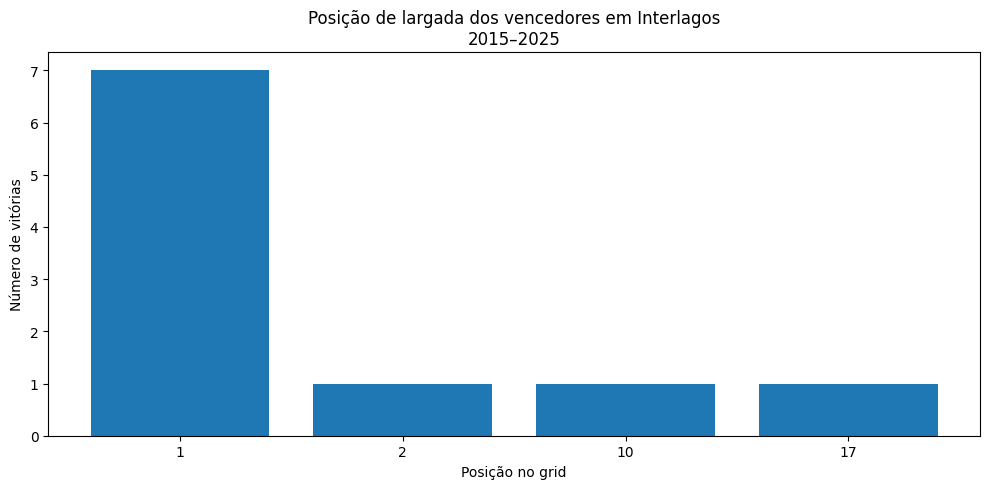

In [29]:

grid_vitorias = (
    vencedores["grid"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    grid_vitorias.index.astype(str),
    grid_vitorias.values
)

plt.title(
    "Posição de largada dos vencedores em Interlagos\n"
    "2015–2025"
)
plt.xlabel("Posição no grid")
plt.ylabel("Número de vitórias")

plt.tight_layout()
plt.show()

#### Insight

A posição de largada apresenta forte associação inicial com a vitória
no período analisado.

Das 10 corridas avaliadas, 7 (70%) foram vencidas pelo piloto que largou
na pole position e 8 (80%) foram vencidas por pilotos que partiram da
primeira fila.

Entretanto, foram identificadas duas exceções relevantes: em 2021 o
vencedor largou da 10ª posição e, em 2024, da 17ª posição.

Esses resultados indicam que uma posição de largada favorável está
frequentemente presente entre os vencedores, mas não constitui condição
necessária para a vitória.

Os casos de 2021 e 2024 serão tratados como eventos de interesse para
investigar quais fatores permitiram recuperações significativamente
superiores ao comportamento predominante.

In [30]:
resultados_grid = resultados[
    ["season", "driver_id", "grid", "position", "status"]
].copy()

resultados_grid["posicoes_ganhas"] = (
    resultados_grid["grid"]
    - resultados_grid["position"]
)

display(
    resultados_grid[
        [
            "season",
            "driver_id",
            "grid",
            "position",
            "posicoes_ganhas",
            "status"
        ]
    ].sort_values(
        "posicoes_ganhas",
        ascending=False
    ).head(15)
)

,season,driver_id,grid,position,posicoes_ganhas,status
92,2019,sainz,20,3,17,Finished
46,2017,hamilton,20,4,16,Finished
192,2025,max_verstappen,19,3,16,Finished
179,2024,max_verstappen,17,1,16,Finished
130,2022,alonso,17,5,12,Finished
25,2016,nasr,21,9,12,Finished
24,2016,ocon,22,12,10,Finished
168,2024,gasly,13,3,10,Finished
112,2021,hamilton,10,1,9,Finished
26,2016,sainz,15,6,9,Finished


## 5.3 Relação entre posição de largada e posição final

Após observar que 80% dos vencedores partiram da primeira fila, a análise
é ampliada para todos os pilotos com posição válida de largada e chegada.

O objetivo é avaliar se posições melhores no grid estão associadas a
melhores resultados finais e, ao mesmo tempo, identificar corridas em que
ocorreram recuperações ou perdas de posição fora do comportamento esperado.

Pilotos classificados com voltas de atraso são mantidos, pois possuem
posição final válida. Registros sem posição de largada válida são
desconsiderados nesta análise.


In [31]:
analise_grid = resultados.loc[
    (resultados["grid"] > 0) &
    (resultados["position"].notna()),
    [
        "season",
        "driver_id",
        "grid",
        "position",
        "status"
    ]
].copy()

analise_grid["posicoes_ganhas"] = (
    analise_grid["grid"] - analise_grid["position"]
)

print(f"Observações utilizadas: {len(analise_grid)}")

display(
    analise_grid[
        ["grid", "position", "posicoes_ganhas"]
    ].describe().T
)

Observações utilizadas: 200


,count,mean,std,min,25%,50%,75%,max
grid,200.0,10.515,5.807617,1.0,5.75,10.5,15.25,22.0
position,200.0,10.570,5.865760,1.0,5.75,10.5,16.00,22.0
posicoes_ganhas,200.0,-0.055,5.753039,-18.0,-3.00,0.0,3.00,17.0


In [32]:
correlacao_pearson = analise_grid[
    ["grid", "position"]
].corr(method="pearson").iloc[0, 1]

correlacao_spearman = analise_grid[
    ["grid", "position"]
].corr(method="spearman").iloc[0, 1]

print(
    f"Correlação de Pearson: {correlacao_pearson:.3f}"
)

print(
    f"Correlação de Spearman: {correlacao_spearman:.3f}"
)

Correlação de Pearson: 0.514
Correlação de Spearman: 0.519


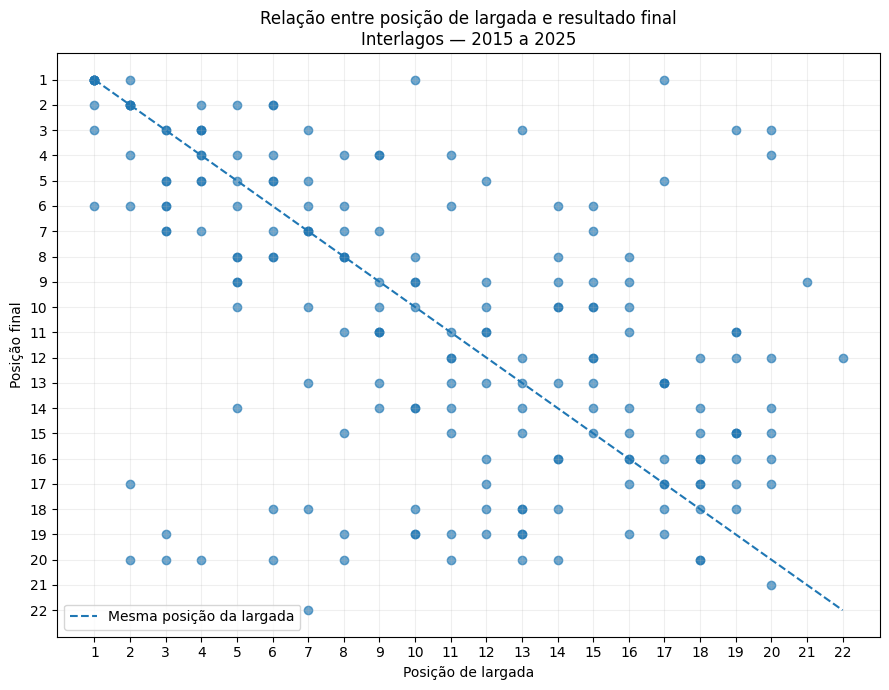

In [33]:
plt.figure(figsize=(9, 7))

plt.scatter(
    analise_grid["grid"],
    analise_grid["position"],
    alpha=0.65
)

# Linha de referência:
# largou Pn e terminou Pn
limite = max(
    analise_grid["grid"].max(),
    analise_grid["position"].max()
)

plt.plot(
    [1, limite],
    [1, limite],
    linestyle="--",
    label="Mesma posição da largada"
)

plt.xlabel("Posição de largada")
plt.ylabel("Posição final")
plt.title(
    "Relação entre posição de largada e resultado final\n"
    "Interlagos — 2015 a 2025"
)

plt.xticks(range(1, int(limite) + 1))
plt.yticks(range(1, int(limite) + 1))

plt.gca().invert_yaxis()

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [34]:
resumo_movimentacao = pd.DataFrame({
    "metrica": [
        "Ganhou posições",
        "Manteve posição",
        "Perdeu posições",
        "Ganhou 5+ posições",
        "Ganhou 10+ posições"
    ],
    "pilotos": [
        (analise_grid["posicoes_ganhas"] > 0).sum(),
        (analise_grid["posicoes_ganhas"] == 0).sum(),
        (analise_grid["posicoes_ganhas"] < 0).sum(),
        (analise_grid["posicoes_ganhas"] >= 5).sum(),
        (analise_grid["posicoes_ganhas"] >= 10).sum()
    ]
})

resumo_movimentacao["percentual"] = (
    resumo_movimentacao["pilotos"]
    / len(analise_grid)
    * 100
).round(1)

display(resumo_movimentacao)

,metrica,pilotos,percentual
0,Ganhou posições,87,43.5
1,Manteve posição,33,16.5
2,Perdeu posições,80,40.0
3,Ganhou 5+ posições,33,16.5
4,Ganhou 10+ posições,8,4.0


#### Insight — influência da posição de largada

A análise considerando todos os 200 pilotos com posição válida de largada
e chegada apresentou correlação de **0,514 pelo coeficiente de Pearson**
e **0,519 pelo coeficiente de Spearman** entre posição de largada e
posição final.

Os resultados indicam uma **associação positiva moderada**: pilotos que
largam nas primeiras posições tendem a terminar a corrida em posições
melhores, enquanto posições de largada mais baixas tendem a estar
associadas a posições finais também mais baixas.

Entretanto, a posição de largada não determina isoladamente o resultado
da corrida. Entre as observações analisadas:

- 43,5% dos pilotos ganharam posições;
- 16,5% mantiveram a posição de largada;
- 40,0% perderam posições;
- 16,5% ganharam cinco ou mais posições;
- 4,0% ganharam dez ou mais posições.

Entre os vencedores, a importância da classificação é ainda mais evidente:
70% largaram da pole position e 80% partiram da primeira fila.

Ao mesmo tempo, foram identificadas recuperações excepcionais, como
vitórias partindo da 10ª posição em 2021 e da 17ª posição em 2024.

Portanto, os dados sugerem que uma boa posição de largada representa uma
vantagem relevante em Interlagos, mas outros fatores ocorridos durante a
corrida também possuem potencial para alterar significativamente o
resultado final.

#### Hipótese para análises posteriores

A posição de largada apresenta poder explicativo sobre o resultado final,
mas a associação moderada e a existência de grandes recuperações indicam
que outras variáveis devem contribuir para explicar o desempenho.

Nas próximas análises serão investigados fatores como ritmo de corrida,
pit stops, estratégia de pneus e condições climáticas, buscando entender
em quais situações o comportamento esperado a partir do grid é alterado.

## 5.4 Análise dos tempos de volta

### Pergunta

Como os tempos de volta se distribuem nas corridas analisadas e quais
valores podem representar condições atípicas de corrida?

Antes de comparar o ritmo dos pilotos, é necessário compreender a
distribuição dos tempos de volta e identificar observações que possam
representar pit stops, incidentes, períodos de Safety Car, condições
climáticas adversas ou outras situações que alterem o ritmo normal da
corrida.

### 5.4.1 Distribuição dos tempos de volta

Primeiro é analisada a distribuição bruta de `lap_time_seconds`.
Média, mediana, percentis e valores extremos são avaliados antes de qualquer
decisão de filtragem, evitando classificar automaticamente um outlier
estatístico como erro de dados.


In [35]:
estatisticas_voltas = (
    voltas["lap_time_seconds"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(estatisticas_voltas)

count    12589.000000
mean        91.473702
std        122.243874
min         70.540000
1%          72.060320
5%          73.060200
25%         74.744000
50%         76.437000
75%         84.360000
90%        105.934600
95%        120.729200
99%        143.645080
max       2126.744000
Name: lap_time_seconds, dtype: float64

#### Observação inicial sobre os tempos de volta

A distribuição dos tempos de volta apresenta forte assimetria à direita.

Embora a mediana seja de aproximadamente **76,44 segundos**, a média é
de **91,47 segundos**, indicando influência de tempos elevados na
distribuição.

Cerca de 75% das voltas possuem duração inferior a **84,36 segundos**,
enquanto 95% estão abaixo de **120,73 segundos** e 99% abaixo de
**143,65 segundos**.

O maior tempo registrado é de aproximadamente **2.126,74 segundos
(35,4 minutos)**, muito distante do comportamento predominante.

Esses valores extremos não serão removidos automaticamente, pois podem
representar eventos reais da corrida, como interrupções, incidentes,
Safety Car, bandeira vermelha ou outras condições atípicas.

Antes de qualquer tratamento, os registros extremos serão investigados
individualmente.

In [36]:
faixas_voltas = pd.cut(
    voltas["lap_time_seconds"],
    bins=[
        0,
        90,
        120,
        150,
        180,
        300,
        600,
        float("inf")
    ],
    labels=[
        "até 90s",
        "90–120s",
        "120–150s",
        "150–180s",
        "3–5 min",
        "5–10 min",
        "10+ min"
    ],
    right=False
)

distribuicao_faixas = (
    faixas_voltas
    .value_counts(sort=False)
    .rename("voltas")
    .to_frame()
)

distribuicao_faixas["percentual"] = (
    distribuicao_faixas["voltas"]
    / len(voltas)
    * 100
).round(2)

display(distribuicao_faixas)

,voltas,percentual
lap_time_seconds,,
até 90s,10564,83.91
90–120s,1328,10.55
120–150s,595,4.73
150–180s,32,0.25
3–5 min,1,0.01
5–10 min,0,0.00
10+ min,69,0.55


#### Investigação dos valores extremos

A inspeção dos maiores tempos de volta demonstrou que os valores extremos
não ocorrem apenas de forma isolada.

Em 2016, diversos pilotos apresentam tempos superiores a 2.100 segundos
na volta 21. Também foram observadas concentrações coletivas relevantes
na volta 29 de 2016, na volta 3 de 2023 e na volta 33 de 2024.

A concentração de valores extremos na mesma temporada e volta é compatível
com condições coletivas atípicas de corrida, como interrupções, reinícios
ou outros eventos que afetam simultaneamente vários pilotos. Sem uma fonte
específica de eventos de pista nesta etapa, a causa exata não é inferida
apenas a partir dos tempos de volta.

Portanto, esses registros são tratados como outliers estatísticos
relevantes para investigação, e não automaticamente como problemas de
qualidade.


In [37]:
voltas_extremas = (
    voltas[
        [
            "season",
            "driver_id",
            "lap",
            "lap_time_seconds"
        ]
    ]
    .sort_values(
        "lap_time_seconds",
        ascending=False
    )
    .head(20)
)

display(voltas_extremas)

,season,driver_id,lap,lap_time_seconds
1737,2016,hamilton,21,2126.744
1738,2016,rosberg,21,2124.601
1740,2016,hulkenberg,21,2123.869
1739,2016,max_verstappen,21,2123.754
1741,2016,perez,21,2123.365
1743,2016,nasr,21,2122.939
1742,2016,sainz,21,2122.068
1744,2016,ricciardo,21,2121.562
1745,2016,ocon,21,2121.063
1746,2016,wehrlein,21,2118.880


In [38]:
voltas_acima_180 = (
    voltas[
        voltas["lap_time_seconds"] > 180
    ]
    .groupby("season")
    .agg(
        quantidade=("lap_time_seconds", "size"),
        maior_tempo=("lap_time_seconds", "max"),
        pilotos=("driver_id", "nunique")
    )
    .reset_index()
)

voltas_acima_180["maior_tempo_min"] = (
    voltas_acima_180["maior_tempo"] / 60
).round(2)

display(voltas_acima_180)

,season,quantidade,maior_tempo,pilotos,maior_tempo_min
0,2016,36,2126.744,18,35.45
1,2023,17,1684.821,17,28.08
2,2024,17,1557.824,17,25.96


In [39]:
eventos_coletivos = (
    voltas[
        voltas["lap_time_seconds"] > 180
    ]
    .groupby(["season", "lap"])
    .agg(
        pilotos_afetados=("driver_id", "nunique"),
        tempo_min=("lap_time_seconds", "min"),
        tempo_mediano=("lap_time_seconds", "median"),
        tempo_max=("lap_time_seconds", "max")
    )
    .reset_index()
    .sort_values(
        ["pilotos_afetados", "season"],
        ascending=[False, True]
    )
)

display(eventos_coletivos)

,season,lap,pilotos_afetados,tempo_min,tempo_mediano,tempo_max
0,2016,21,18,2116.816,2119.9715,2126.744
1,2016,29,18,1587.639,1594.2260,1597.686
3,2023,3,15,1525.170,1533.4030,1562.851
6,2024,33,15,1520.559,1537.7980,1557.824
2,2023,2,2,1679.112,1681.9665,1684.821
4,2024,27,1,230.215,230.2150,230.215
5,2024,32,1,1392.307,1392.3070,1392.307


#### Conclusão sobre os tempos extremos

A investigação demonstrou que os maiores tempos de volta estão
concentrados em temporadas e voltas específicas, afetando vários
pilotos simultaneamente.

Em 2016, 18 pilotos apresentam tempos excepcionalmente elevados nas
voltas 21 e 29. Comportamento semelhante foi identificado em 2023 e
2024, também envolvendo diversos pilotos na mesma volta.

Essa concentração indica que os valores extremos estão associados a
eventos coletivos da corrida, e não a erros isolados de medição ou
desempenho individual.

Do total de 12.589 voltas analisadas, 83,91% possuem tempo inferior a
90 segundos e apenas uma pequena parcela apresenta tempos extremamente
elevados.

Os registros extremos serão preservados no conjunto original, pois são
compatíveis com condições atípicas e coletivas de corrida.

Entretanto, eles não serão utilizados diretamente em métricas destinadas
a representar o ritmo normal dos pilotos, pois poderiam distorcer médias
e comparações de desempenho.

### 5.4.2 Construção de uma referência de ritmo

A média simples do tempo de volta não é adequada para representar ritmo
competitivo, pois a distribuição é assimétrica e contém pit stops e
eventos coletivos extremos.

A construção da métrica é feita em etapas. Primeiro, o tempo de cada volta
é comparado com a mediana da corrida (`delta_mediana_pct`). Em seguida,
é utilizada uma referência mais contextual: a mediana dos pilotos na
mesma volta (`delta_volta_pct`). Essa segunda medida reduz diferenças
decorrentes do momento da corrida e permite avaliar o desempenho relativo
do piloto frente aos concorrentes presentes naquela volta.


In [40]:
mediana_corrida = (
    voltas
    .groupby(["season", "round"])["lap_time_seconds"]
    .median()
    .reset_index(name="mediana_corrida")
)

display(mediana_corrida)

,season,round,mediana_corrida
0,2015,18,77.7900
1,2016,20,99.7895
2,2017,19,74.5240
3,2018,20,74.5170
4,2019,20,74.8230
5,2021,19,75.6240
6,2022,21,77.1600
7,2023,20,76.3420
8,2024,21,84.9150
9,2025,21,75.0080


In [41]:
voltas_ritmo = voltas.merge(
    mediana_corrida,
    on=["season", "round"],
    how="left"
)

voltas_ritmo["delta_mediana_pct"] = (
    (
        voltas_ritmo["lap_time_seconds"]
        / voltas_ritmo["mediana_corrida"]
    ) - 1
) * 100

display(
    voltas_ritmo[
        [
            "season",
            "driver_id",
            "lap",
            "lap_time_seconds",
            "mediana_corrida",
            "delta_mediana_pct"
        ]
    ].head()
)

,season,driver_id,lap,lap_time_seconds,mediana_corrida,delta_mediana_pct
0,2015,rosberg,1,80.546,77.79,3.542872
1,2015,hamilton,1,81.209,77.79,4.395166
2,2015,vettel,1,82.124,77.79,5.571410
3,2015,raikkonen,1,82.683,77.79,6.290012
4,2015,bottas,1,83.692,77.79,7.587093


In [42]:
display(
    voltas_ritmo["delta_mediana_pct"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    12589.000000
mean        14.333126
std        133.725568
min        -14.515054
1%         -12.613291
5%          -5.015035
25%         -1.381186
50%          0.000000
75%          1.928238
90%         22.250455
95%         42.389660
99%         85.147442
max       2106.938514
Name: delta_mediana_pct, dtype: float64

### 5.4.3 Impacto dos pit stops

As voltas associadas a paradas nos boxes são identificadas por meio do
dataset `pit_stops` e comparadas às demais voltas. O objetivo é verificar
empiricamente se elas devem participar da métrica de ritmo de pista.


In [43]:
pit_laps = (
    pit_stops[
        ["season", "round", "driver_id", "lap"]
    ]
    .drop_duplicates()
    .assign(pit_stop=True)
)

voltas_ritmo = voltas_ritmo.merge(
    pit_laps,
    on=["season", "round", "driver_id", "lap"],
    how="left"
)

voltas_ritmo["pit_stop"] = (
    voltas_ritmo["pit_stop"]
    .fillna(False)
    .astype(bool)
)

display(
    voltas_ritmo["pit_stop"]
    .value_counts()
    .rename_axis("pit_stop")
    .reset_index(name="voltas")
)

C:\Users\vinic\AppData\Local\Temp\ipykernel_26292\3514739388.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,pit_stop,voltas
0,False,12077
1,True,512


In [44]:
comparacao_pit = (
    voltas_ritmo
    .groupby("pit_stop")["lap_time_seconds"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .round(2)
)

display(comparacao_pit)

,quantidade,media,mediana,minimo,maximo
pit_stop,,,,,
False,12077,90.63,76.30,70.54,2126.74
True,512,111.44,86.73,76.09,1684.82


#### Impacto dos pit stops nos tempos de volta

A comparação entre voltas com e sem pit stop demonstrou diferença
relevante na distribuição dos tempos.

As 512 voltas associadas a pit stops apresentaram mediana de
aproximadamente **86,73 segundos**, enquanto as demais voltas
apresentaram mediana de **76,30 segundos**.

A diferença de aproximadamente **10,4 segundos na mediana** demonstra
que as voltas associadas a paradas nos boxes não representam
adequadamente o ritmo normal de pista dos pilotos.

Por esse motivo, as voltas identificadas como pit stop serão preservadas
no conjunto original, mas excluídas das métricas destinadas
especificamente à comparação de ritmo de corrida.

A exclusão das voltas de pit stop, entretanto, não elimina todos os
tempos extremos, pois eventos coletivos de corrida permanecem presentes
entre as voltas sem pit stop.

### 5.4.4 Normalização pelo contexto da mesma volta

A primeira normalização compara cada registro com a mediana de toda a
corrida, mas não controla adequadamente mudanças de contexto ao longo da
prova. Por isso, é criada `delta_volta_pct`, calculada em relação à mediana
dos pilotos na mesma temporada, corrida e número de volta.

Valores negativos indicam tempo inferior à referência da volta; valores
positivos indicam tempo superior. A métrica é relativa ao contexto da
corrida e não representa comparação direta de velocidade absoluta entre
temporadas.


In [45]:
mediana_por_volta = (
    voltas
    .groupby(
        ["season", "round", "lap"]
    )["lap_time_seconds"]
    .median()
    .reset_index(
        name="mediana_volta_corrida"
    )
)

voltas_contexto = voltas_ritmo.merge(
    mediana_por_volta,
    on=["season", "round", "lap"],
    how="left"
)

voltas_contexto["delta_volta_pct"] = (
    (
        voltas_contexto["lap_time_seconds"]
        / voltas_contexto["mediana_volta_corrida"]
    ) - 1
) * 100

In [46]:
display(
    voltas_contexto[
        [
            "season",
            "driver_id",
            "lap",
            "lap_time_seconds",
            "mediana_corrida",
            "delta_mediana_pct",
            "mediana_volta_corrida",
            "delta_volta_pct",
            "pit_stop"
        ]
    ].head(15)
)

,season,driver_id,lap,lap_time_seconds,mediana_corrida,delta_mediana_pct,mediana_volta_corrida,delta_volta_pct,pit_stop
0,2015,rosberg,1,80.546,77.79,3.542872,86.628,-7.020825,False
1,2015,hamilton,1,81.209,77.79,4.395166,86.628,-6.255483,False
2,2015,vettel,1,82.124,77.79,5.571410,86.628,-5.199243,False
3,2015,raikkonen,1,82.683,77.79,6.290012,86.628,-4.553955,False
4,2015,bottas,1,83.692,77.79,7.587093,86.628,-3.389204,False
5,2015,kvyat,1,84.771,77.79,8.974161,86.628,-2.143649,False
6,2015,hulkenberg,1,85.143,77.79,9.452372,86.628,-1.714226,False
7,2015,massa,1,85.884,77.79,10.404936,86.628,-0.858845,False
8,2015,perez,1,86.566,77.79,11.281656,86.628,-0.071570,False
9,2015,max_verstappen,1,86.628,77.79,11.361358,86.628,0.000000,False


In [47]:
estatisticas_delta_volta = (
    voltas_contexto["delta_volta_pct"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(estatisticas_delta_volta)

count    12589.000000
mean         0.987711
std         15.969263
min        -93.227500
1%          -7.086772
5%          -2.379666
25%         -0.828048
50%          0.000000
75%          0.838365
90%          2.839784
95%          5.958661
99%         24.362629
max       1065.474091
Name: delta_volta_pct, dtype: float64

### 5.4.5 Avaliação de extremos individuais e coletivos


In [48]:
extremos_positivos = (
    voltas_contexto[
        [
            "season",
            "round",
            "driver_id",
            "lap",
            "lap_time_seconds",
            "mediana_volta_corrida",
            "delta_volta_pct",
            "pit_stop"
        ]
    ]
    .sort_values(
        "delta_volta_pct",
        ascending=False
    )
    .head(20)
)

display(extremos_positivos)

,season,round,driver_id,lap,lap_time_seconds,mediana_volta_corrida,delta_volta_pct,pit_stop
9133,2023,20,piastri,2,1684.821,144.5610,1065.474091,True
9134,2023,20,ricciardo,2,1679.112,144.5610,1061.524893,True
10778,2024,21,zhou,32,1392.307,160.3700,768.184199,True
10692,2024,21,hulkenberg,27,230.215,97.8765,135.209678,True
3730,2017,19,stroll,67,120.270,73.8820,62.786606,True
9152,2023,20,max_verstappen,4,132.670,82.2750,61.251899,False
9153,2023,20,norris,4,130.857,82.2750,59.048314,False
9155,2023,20,hamilton,4,125.489,82.2750,52.523853,False
6219,2019,20,hamilton,57,120.582,79.6160,51.454482,False
9158,2023,20,stroll,4,123.170,82.2750,49.705257,False


In [49]:
extremos_negativos = (
    voltas_contexto[
        [
            "season",
            "round",
            "driver_id",
            "lap",
            "lap_time_seconds",
            "mediana_volta_corrida",
            "delta_volta_pct",
            "pit_stop"
        ]
    ]
    .sort_values(
        "delta_volta_pct"
    )
    .head(20)
)

display(extremos_negativos)

,season,round,driver_id,lap,lap_time_seconds,mediana_volta_corrida,delta_volta_pct,pit_stop
9151,2023,20,ricciardo,3,103.821,1532.9790,-93.227500,False
9150,2023,20,piastri,3,109.154,1532.9790,-92.879615,False
10793,2024,21,zhou,33,173.772,1536.9435,-88.693664,False
6453,2019,20,kubica,69,79.597,133.8855,-40.548454,False
8896,2022,21,latifi,59,75.327,115.7270,-34.909744,False
8879,2022,21,latifi,58,75.499,114.9660,-34.329280,False
8878,2022,21,albon,58,77.680,114.9660,-32.432197,False
8897,2022,21,tsunoda,59,83.332,115.7270,-27.992603,False
8895,2022,21,albon,59,83.449,115.7270,-27.891503,False
6644,2021,19,norris,8,97.267,132.8565,-26.787925,True


In [50]:
pilotos_por_volta = (
    voltas
    .groupby(
        ["season", "round", "lap"]
    )
    .agg(
        pilotos_na_volta=("driver_id", "nunique")
    )
    .reset_index()
)

voltas_contexto = voltas_contexto.merge(
    pilotos_por_volta,
    on=["season", "round", "lap"],
    how="left"
)

In [51]:
display(
    voltas_contexto[
        [
            "season",
            "driver_id",
            "lap",
            "lap_time_seconds",
            "mediana_volta_corrida",
            "delta_volta_pct",
            "pit_stop",
            "pilotos_na_volta"
        ]
    ]
    .sort_values(
        "delta_volta_pct",
        ascending=False
    )
    .head(20)
)

,season,driver_id,lap,lap_time_seconds,mediana_volta_corrida,delta_volta_pct,pit_stop,pilotos_na_volta
9133,2023,piastri,2,1684.821,144.5610,1065.474091,True,17
9134,2023,ricciardo,2,1679.112,144.5610,1061.524893,True,17
10778,2024,zhou,32,1392.307,160.3700,768.184199,True,16
10692,2024,hulkenberg,27,230.215,97.8765,135.209678,True,18
3730,2017,stroll,67,120.270,73.8820,62.786606,True,16
9152,2023,max_verstappen,4,132.670,82.2750,61.251899,False,17
9153,2023,norris,4,130.857,82.2750,59.048314,False,17
9155,2023,hamilton,4,125.489,82.2750,52.523853,False,17
6219,2019,hamilton,57,120.582,79.6160,51.454482,False,19
9158,2023,stroll,4,123.170,82.2750,49.705257,False,17


In [52]:
display(
    voltas_contexto[
        [
            "season",
            "driver_id",
            "lap",
            "lap_time_seconds",
            "mediana_volta_corrida",
            "delta_volta_pct",
            "pit_stop",
            "pilotos_na_volta"
        ]
    ]
    .sort_values(
        "delta_volta_pct"
    )
    .head(20)
)

,season,driver_id,lap,lap_time_seconds,mediana_volta_corrida,delta_volta_pct,pit_stop,pilotos_na_volta
9151,2023,ricciardo,3,103.821,1532.9790,-93.227500,False,17
9150,2023,piastri,3,109.154,1532.9790,-92.879615,False,17
10793,2024,zhou,33,173.772,1536.9435,-88.693664,False,16
6453,2019,kubica,69,79.597,133.8855,-40.548454,False,16
8896,2022,latifi,59,75.327,115.7270,-34.909744,False,17
8879,2022,latifi,58,75.499,114.9660,-34.329280,False,17
8878,2022,albon,58,77.680,114.9660,-32.432197,False,17
8897,2022,tsunoda,59,83.332,115.7270,-27.992603,False,17
8895,2022,albon,59,83.449,115.7270,-27.891503,False,17
6644,2021,norris,8,97.267,132.8565,-26.787925,True,20


A inspeção de `delta_volta_pct` mostrou que a própria referência da volta
pode se tornar atípica quando grande parte do grid é afetada por um evento
coletivo. Para separar anomalias individuais de mudanças coletivas de
contexto, é criada `delta_contexto_volta_pct`:

`(mediana_volta_corrida / mediana_corrida - 1) × 100`

Essa métrica não mede o desempenho de um piloto. Ela mede o quanto a volta,
como contexto coletivo, se afasta do comportamento central da corrida.


In [53]:
voltas_contexto["delta_contexto_volta_pct"] = (
    (
        voltas_contexto["mediana_volta_corrida"]
        / voltas_contexto["mediana_corrida"]
    ) - 1
) * 100

In [54]:
display(
    voltas_contexto[
        [
            "season",
            "round",
            "lap",
            "mediana_corrida",
            "mediana_volta_corrida",
            "delta_contexto_volta_pct"
        ]
    ]
    .drop_duplicates(
        subset=["season", "round", "lap"]
    )
    ["delta_contexto_volta_pct"]
    .describe(
        percentiles=[
            .01,
            .05,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

count     708.000000
mean       13.747515
std       135.203922
min       -12.423151
1%        -11.943180
5%         -7.033305
25%        -1.203604
50%        -0.142037
75%         0.845593
90%        20.280240
95%        38.664850
99%        79.475814
max      2024.443453
Name: delta_contexto_volta_pct, dtype: float64

In [55]:
comparacao_delta_pit = (
    voltas_contexto
    .groupby("pit_stop")["delta_volta_pct"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .round(2)
)

display(comparacao_delta_pit)

,quantidade,media,mediana,desvio_padrao,minimo,maximo
pit_stop,,,,,,
False,12077,0.61,-0.00,5.13,-93.23,61.25
True,512,9.84,4.81,74.69,-26.79,1065.47


In [56]:
display(
    voltas_contexto
    .groupby("pit_stop")["delta_volta_pct"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    .unstack()
    .round(2)
)

,0.25,0.50,0.75,0.90,0.95
pit_stop,,,,,
False,-0.85,-0.00,0.73,2.21,4.31
True,0.21,4.81,6.39,8.56,10.87


In [57]:
voltas_contexto_anormal = (
    voltas_contexto[
        [
            "season",
            "round",
            "lap",
            "pilotos_na_volta",
            "mediana_corrida",
            "mediana_volta_corrida",
            "delta_contexto_volta_pct"
        ]
    ]
    .drop_duplicates(
        subset=["season", "round", "lap"]
    )
    .sort_values(
        "delta_contexto_volta_pct",
        ascending=False
    )
    .head(30)
)

display(voltas_contexto_anormal)

,season,round,lap,pilotos_na_volta,mediana_corrida,mediana_volta_corrida,delta_contexto_volta_pct
1737,2016,20,21,18,99.7895,2119.9715,2024.443453
9135,2023,20,3,17,76.3420,1532.9790,1908.041445
10779,2024,21,33,16,84.9150,1536.9435,1709.978802
1881,2016,20,29,18,99.7895,1594.2260,1497.588925
9118,2023,20,2,17,76.3420,144.5610,89.359723
10763,2024,21,32,16,84.9150,160.3700,88.859448
2636,2017,19,2,17,74.5240,138.4430,85.769685
6645,2021,19,9,20,75.6240,135.7575,79.516423
6438,2019,20,69,16,74.8230,133.8855,78.936290
9101,2023,20,1,17,76.3420,135.9090,78.026512


In [58]:
delta_por_temporada = (
    voltas_contexto
    .groupby("season")["delta_volta_pct"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std"
    )
    .round(2)
)

display(delta_por_temporada)

,quantidade,media,mediana,desvio_padrao
season,,,,
2015,1327,1.17,0.0,4.79
2016,1292,0.39,0.0,5.18
2017,1167,0.53,0.0,3.78
2018,1318,0.72,0.0,3.95
2019,1381,0.84,0.0,6.42
2021,1360,0.69,0.0,4.91
2022,1256,0.90,0.0,5.91
2023,1106,3.00,0.0,45.73
2024,1133,1.11,0.0,23.64


In [59]:
percentis_temporada = (
    voltas_contexto
    .groupby("season")["delta_volta_pct"]
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .unstack()
    .round(2)
)

percentis_temporada.columns = [
    "p05",
    "p25",
    "p50",
    "p75",
    "p95"
]

display(percentis_temporada)

,p05,p25,p50,p75,p95
season,,,,,
2015,-2.21,-0.82,0.0,0.86,7.39
2016,-4.78,-0.86,0.0,0.95,6.80
2017,-2.03,-0.93,0.0,0.95,3.86
2018,-1.87,-0.94,0.0,0.96,4.63
2019,-3.12,-1.24,0.0,0.73,9.80
2021,-2.73,-1.07,0.0,1.05,5.24
2022,-2.13,-0.92,0.0,0.78,8.81
2023,-1.42,-0.42,0.0,0.57,6.29
2024,-2.97,-0.53,0.0,0.75,4.36


#### Impacto dos pit stops no desempenho relativo

A análise do `delta_volta_pct` confirmou que as voltas associadas a pit
stops apresentam comportamento significativamente diferente das demais.

Enquanto as voltas sem pit stop possuem mediana próxima de 0%, as voltas
com parada apresentam mediana de aproximadamente +4,81%.

Além disso, 95% das voltas sem pit stop apresentam delta de até +4,31%,
enquanto entre as voltas com pit stop esse valor sobe para +10,87%.

Os resultados indicam que a realização de uma parada nos boxes afeta
substancialmente o tempo relativo daquela volta.

Por esse motivo, as pit laps serão preservadas no conjunto original,
mas não serão consideradas no cálculo específico do ritmo representativo
de pista dos pilotos.

In [60]:
limites = [5, 10, 20, 30, 40, 50, 75, 100]

voltas_unicas = (
    voltas_contexto[
        [
            "season",
            "round",
            "lap",
            "delta_contexto_volta_pct"
        ]
    ]
    .drop_duplicates(
        subset=["season", "round", "lap"]
    )
)

analise_limites = []

for limite in limites:
    quantidade = (
        voltas_unicas["delta_contexto_volta_pct"]
        > limite
    ).sum()

    analise_limites.append(
        {
            "limite_pct": limite,
            "voltas_acima": quantidade,
            "percentual": round(
                quantidade / len(voltas_unicas) * 100,
                2
            )
        }
    )

analise_limites = pd.DataFrame(analise_limites)

display(analise_limites)

,limite_pct,voltas_acima,percentual
0,5,102,14.41
1,10,91,12.85
2,20,74,10.45
3,30,49,6.92
4,40,35,4.94
5,50,22,3.11
6,75,12,1.69
7,100,4,0.56


In [61]:
resumo_pilotos_volta = (
    voltas_contexto[
        [
            "season",
            "round",
            "lap",
            "pilotos_na_volta"
        ]
    ]
    .drop_duplicates(
        subset=["season", "round", "lap"]
    )
    ["pilotos_na_volta"]
    .describe()
)

display(resumo_pilotos_volta)

count    708.000000
mean      17.781073
std        1.830539
min        4.000000
25%       17.000000
50%       18.000000
75%       19.000000
max       21.000000
Name: pilotos_na_volta, dtype: float64

### 5.4.6 Definição de volta comparável

A análise dos limites mostrou que, nesta amostra, apenas quatro voltas
únicas apresentam `delta_contexto_volta_pct > 100%`. São justamente os
quatro eventos coletivos extremos identificados anteriormente:
2016/volta 21, 2016/volta 29, 2023/volta 3 e 2024/volta 33.

O valor de 100% não é tratado como regra estatística universal. Ele é um
critério analítico específico desta amostra, validado pela distribuição e
pela investigação prévia dos extremos.

Para o cálculo de ritmo, uma volta é considerada comparável quando:
- não está associada a pit stop; e
- não pertence a um desses eventos coletivos extremos.

Deltas individualmente altos não são removidos automaticamente, pois podem
representar perda real de desempenho. Os registros também permanecem
preservados no dataset original.


In [62]:
voltas_contexto["evento_coletivo_extremo"] = (
    voltas_contexto["delta_contexto_volta_pct"] > 100
)

voltas_contexto["volta_comparavel"] = (
    (~voltas_contexto["pit_stop"])
    &
    (~voltas_contexto["evento_coletivo_extremo"])
)

In [63]:
resumo_comparabilidade = (
    voltas_contexto["volta_comparavel"]
    .value_counts()
    .rename_axis("volta_comparavel")
    .reset_index(name="quantidade")
)

resumo_comparabilidade["percentual"] = (
    resumo_comparabilidade["quantidade"]
    / len(voltas_contexto)
    * 100
).round(2)

display(resumo_comparabilidade)

,volta_comparavel,quantidade,percentual
0,True,12008,95.38
1,False,581,4.62


In [64]:
motivos_nao_comparavel = pd.DataFrame({
    "motivo": [
        "Pit stop",
        "Evento coletivo extremo"
    ],
    "quantidade": [
        voltas_contexto["pit_stop"].sum(),
        voltas_contexto["evento_coletivo_extremo"].sum()
    ]
})

display(motivos_nao_comparavel)

,motivo,quantidade
0,Pit stop,512
1,Evento coletivo extremo,69


### 5.4.7 Ritmo representativo por piloto e corrida

Após definir as voltas comparáveis, a referência da mesma volta é
recalculada utilizando apenas os registros elegíveis. O
`delta_ritmo_pct` representa a diferença percentual entre o tempo do
piloto e essa referência definitiva.

O ritmo representativo de cada piloto-corrida é definido pela mediana de
`delta_ritmo_pct`, reduzindo a influência de observações individuais
extremas. Quanto menor o valor, melhor o desempenho relativo.


In [65]:
# Dataset destinado especificamente à análise de ritmo
voltas_ritmo = (
    voltas_contexto[
        voltas_contexto["volta_comparavel"]
    ]
    .copy()
)

# Referência definitiva da volta utilizando somente voltas comparáveis
referencia_volta = (
    voltas_ritmo
    .groupby(
        ["season", "round", "lap"]
    )["lap_time_seconds"]
    .median()
    .rename("mediana_volta_comparavel")
    .reset_index()
)

voltas_ritmo = voltas_ritmo.merge(
    referencia_volta,
    on=["season", "round", "lap"],
    how="left"
)

# Delta definitivo utilizado para análise de ritmo
voltas_ritmo["delta_ritmo_pct"] = (
    (
        voltas_ritmo["lap_time_seconds"]
        / voltas_ritmo["mediana_volta_comparavel"]
    ) - 1
) * 100

In [66]:
ritmo_piloto_corrida = (
    voltas_ritmo
    .groupby(
        [
            "season",
            "round",
            "driver_id"
        ]
    )
    .agg(
        ritmo_representativo_pct=(
            "delta_ritmo_pct",
            "median"
        ),
        media_delta_pct=(
            "delta_ritmo_pct",
            "mean"
        ),
        voltas_analisadas=(
            "lap",
            "count"
        ),
        melhor_delta_pct=(
            "delta_ritmo_pct",
            "min"
        ),
        pior_delta_pct=(
            "delta_ritmo_pct",
            "max"
        )
    )
    .reset_index()
)

In [67]:
display(
    ritmo_piloto_corrida
    .sort_values(
        ["season", "ritmo_representativo_pct"]
    )
)

,season,round,driver_id,ritmo_representativo_pct,media_delta_pct,voltas_analisadas,melhor_delta_pct,pior_delta_pct
15,2015,18,rosberg,-2.086756,-1.252149,68,-7.020825,20.641198
18,2015,18,vettel,-1.915227,-1.004130,68,-5.199243,20.528211
5,2015,18,hamilton,-1.885755,-1.075393,68,-6.255483,19.671416
13,2015,18,raikkonen,-1.039037,-0.324969,69,-4.553955,23.945360
1,2015,18,bottas,-0.541148,0.268456,68,-3.389204,24.234869
...,...,...,...,...,...,...,...,...
186,2025,21,sainz,0.365945,0.954652,69,-2.569222,24.761175
179,2025,21,lawson,0.455419,0.965615,70,-3.107368,22.605944
177,2025,21,hamilton,0.597133,1.894983,34,-13.400114,35.190847
178,2025,21,hulkenberg,0.620421,0.973593,70,-2.079799,22.650358


In [68]:
display(
    ritmo_piloto_corrida["voltas_analisadas"]
    .describe(
        percentiles=[
            .05,
            .10,
            .25,
            .50,
            .75,
            .90,
            .95
        ]
    )
)

count    189.000000
mean      63.534392
std       11.743497
min        5.000000
5%        34.400000
10%       53.600000
25%       66.000000
50%       67.000000
75%       69.000000
90%       69.000000
95%       69.600000
max       70.000000
Name: voltas_analisadas, dtype: float64

In [69]:
ritmo_piloto_corrida = ritmo_piloto_corrida.merge(
    resultados[
        [
            "season",
            "round",
            "driver_id",
            "position",
            "grid",
            "laps",
            "status"
        ]
    ],
    on=["season", "round", "driver_id"],
    how="left"
)


### 5.4.8 Cobertura e representatividade da amostra

A cobertura da métrica deve responder quanto dos registros de volta
efetivamente disponíveis permaneceu após os critérios de comparabilidade.

Durante a validação, o resultado oficial de Hülkenberg em 2024 apresentou
`laps = 0` com status `Disqualified`, embora existam 30 registros na base
`voltas`. Por isso, `resultados.laps` não é utilizado como denominador da
cobertura. O denominador passa a ser a quantidade efetiva de registros
disponíveis em `voltas`.

`cobertura_ritmo_pct = voltas_analisadas / voltas_disponiveis × 100`

Casos com menos de 20 voltas comparáveis são mantidos, mas sinalizados
como amostra reduzida para permitir análises de sensibilidade posteriores.


In [70]:
voltas_disponiveis = (
    voltas
    .groupby(
        ["season", "round", "driver_id"]
    )
    .agg(
        voltas_disponiveis=("lap", "count")
    )
    .reset_index()
)

display(
    voltas_disponiveis
    .sort_values("voltas_disponiveis")
    .head(20)
)

,season,round,driver_id,voltas_disponiveis
180,2025,21,leclerc,5
22,2016,20,ericsson,11
34,2016,20,raikkonen,19
60,2018,20,ericsson,20
26,2016,20,jolyon_palmer,20
151,2023,20,zhou,22
155,2024,21,colapinto,30
158,2024,21,hulkenberg,30
64,2018,20,hulkenberg,32
177,2025,21,hamilton,37


In [71]:
ritmo_piloto_corrida = ritmo_piloto_corrida.merge(
    voltas_disponiveis,
    on=["season", "round", "driver_id"],
    how="left"
)

ritmo_piloto_corrida["cobertura_ritmo_pct"] = (
    ritmo_piloto_corrida["voltas_analisadas"]
    / ritmo_piloto_corrida["voltas_disponiveis"]
    * 100
)

In [72]:
display(
    ritmo_piloto_corrida[
        (ritmo_piloto_corrida["season"] == 2024)
        &
        (ritmo_piloto_corrida["driver_id"] == "hulkenberg")
    ][
        [
            "season",
            "driver_id",
            "laps",
            "voltas_disponiveis",
            "voltas_analisadas",
            "cobertura_ritmo_pct",
            "status"
        ]
    ]
)

,season,driver_id,laps,voltas_disponiveis,voltas_analisadas,cobertura_ritmo_pct,status
158,2024,hulkenberg,0,30,27,90.0,Disqualified


In [73]:
for limite in [10, 20, 30, 40, 50]:
    qtd = (
        ritmo_piloto_corrida["voltas_analisadas"]
        < limite
    ).sum()

    print(
        f"< {limite} voltas: "
        f"{qtd} pilotos "
        f"({qtd / len(ritmo_piloto_corrida) * 100:.2f}%)"
    )

< 10 voltas: 1 pilotos (0.53%)
< 20 voltas: 6 pilotos (3.17%)
< 30 voltas: 8 pilotos (4.23%)
< 40 voltas: 13 pilotos (6.88%)
< 50 voltas: 18 pilotos (9.52%)


In [74]:
ritmo_piloto_corrida["amostra_reduzida"] = (
    ritmo_piloto_corrida["voltas_analisadas"] < 20
)

display(
    ritmo_piloto_corrida["amostra_reduzida"]
    .value_counts()
    .rename_axis("amostra_reduzida")
    .reset_index(name="pilotos_corrida")
)


,amostra_reduzida,pilotos_corrida
0,False,183
1,True,6


In [75]:
display(
    ritmo_piloto_corrida["cobertura_ritmo_pct"]
    .describe(
        percentiles=[
            .05,
            .10,
            .25,
            .50,
            .75,
            .90,
            .95
        ]
    )
)

count    189.000000
mean      95.257532
std        2.507611
min       81.818182
5%        90.448143
10%       92.753623
25%       94.285714
50%       95.714286
75%       97.183099
90%       97.183099
95%       98.591549
max      100.000000
Name: cobertura_ritmo_pct, dtype: float64

In [76]:
print(
    "Valores infinitos:",
    np.isinf(
        ritmo_piloto_corrida["cobertura_ritmo_pct"]
    ).sum()
)

print(
    "Cobertura > 100%:",
    (
        ritmo_piloto_corrida["cobertura_ritmo_pct"] > 100
    ).sum()
)

print(
    "Cobertura < 0%:",
    (
        ritmo_piloto_corrida["cobertura_ritmo_pct"] < 0
    ).sum()
)

Valores infinitos: 0
Cobertura > 100%: 0
Cobertura < 0%: 0


### 5.4.9 Visualizações de síntese

Após a investigação e definição metodológica, são apresentados gráficos
de síntese. Os limites P99 e P1–P99 são aplicados apenas à visualização
para evitar que poucos extremos comprimam a escala; nenhum registro é
removido do dataset original por esse motivo.


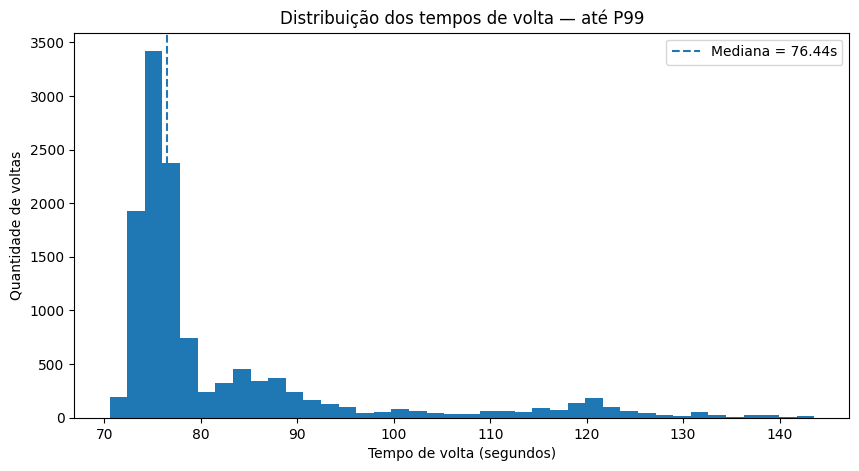

In [77]:

limite_p99 = voltas["lap_time_seconds"].quantile(0.99)

dados_plot = voltas[
    voltas["lap_time_seconds"] <= limite_p99
]

plt.figure(figsize=(10, 5))

plt.hist(
    dados_plot["lap_time_seconds"],
    bins=40
)

plt.axvline(
    voltas["lap_time_seconds"].median(),
    linestyle="--",
    label=f"Mediana = {voltas['lap_time_seconds'].median():.2f}s"
)

plt.xlabel("Tempo de volta (segundos)")
plt.ylabel("Quantidade de voltas")
plt.title("Distribuição dos tempos de volta — até P99")

plt.legend()
plt.show()

A distribuição dos tempos de volta apresenta forte assimetria à direita.
A mediana foi de aproximadamente 76,44 segundos, enquanto a média atingiu
91,47 segundos, influenciada por uma pequena quantidade de voltas
extremamente longas.

Para preservar a legibilidade, a visualização foi limitada ao percentil
99. Os registros acima desse limite não foram removidos da base e foram
investigados separadamente.

#### Pit stop versus volta sem parada

O boxplot compara a distribuição dos tempos com e sem pit stop. Os fliers
são ocultados apenas no gráfico (`showfliers=False`) para melhorar a
legibilidade; continuam preservados nos dados.


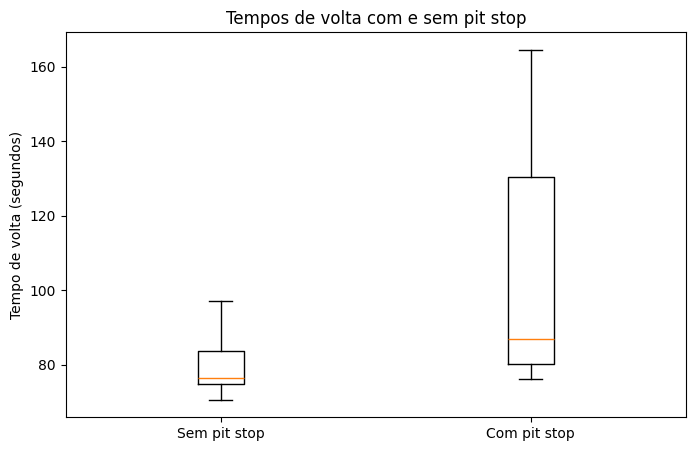

In [78]:
dados_boxplot = [
    voltas_contexto.loc[
        ~voltas_contexto["pit_stop"],
        "lap_time_seconds"
    ],
    voltas_contexto.loc[
        voltas_contexto["pit_stop"],
        "lap_time_seconds"
    ]
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    dados_boxplot,
    tick_labels=[
        "Sem pit stop",
        "Com pit stop"
    ],
    showfliers=False
)

plt.ylabel("Tempo de volta (segundos)")
plt.title("Tempos de volta com e sem pit stop")

plt.show()

#### Distribuição do ritmo relativo

A distribuição de `delta_ritmo_pct` mostra a concentração do desempenho
relativo em torno da referência da mesma volta. A visualização é limitada
entre P1 e P99 somente para fins gráficos.


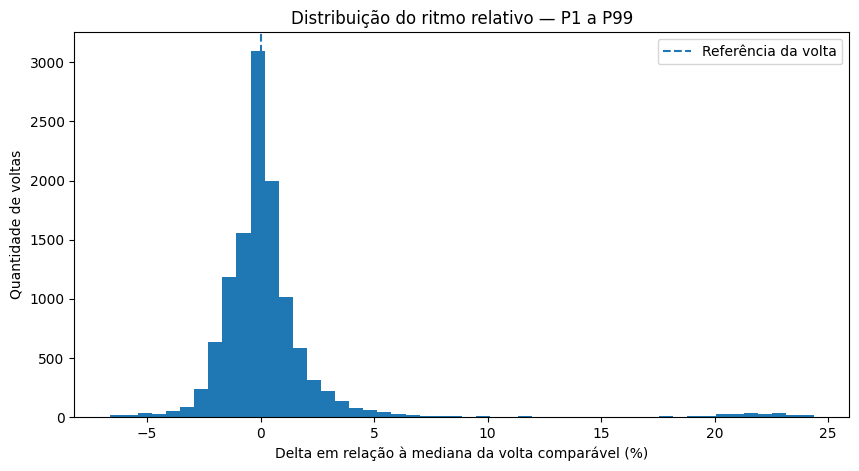

In [79]:
p01 = voltas_ritmo["delta_ritmo_pct"].quantile(0.01)
p99 = voltas_ritmo["delta_ritmo_pct"].quantile(0.99)

dados_delta = voltas_ritmo[
    voltas_ritmo["delta_ritmo_pct"].between(
        p01,
        p99
    )
]

plt.figure(figsize=(10, 5))

plt.hist(
    dados_delta["delta_ritmo_pct"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--",
    label="Referência da volta"
)

plt.xlabel("Delta em relação à mediana da volta comparável (%)")
plt.ylabel("Quantidade de voltas")
plt.title("Distribuição do ritmo relativo — P1 a P99")

plt.legend()
plt.show()

#### Destaques de ritmo

Para evitar rankings sustentados por amostras muito pequenas, o Top 10
descritivo considera apenas piloto-corrida com pelo menos 20 voltas
comparáveis. Esse critério não remove os demais registros do dataset.


In [80]:
top_ritmos = (
    ritmo_piloto_corrida[
        ritmo_piloto_corrida["voltas_analisadas"] >= 20
    ]
    .nsmallest(
        10,
        "ritmo_representativo_pct"
    )
    .copy()
)

top_ritmos["piloto_ano"] = (
    top_ritmos["driver_id"]
    + " — "
    + top_ritmos["season"].astype(str)
)

display(
    top_ritmos[
        [
            "season",
            "driver_id",
            "ritmo_representativo_pct",
            "voltas_analisadas",
            "cobertura_ritmo_pct"
        ]
    ]
)

,season,driver_id,ritmo_representativo_pct,voltas_analisadas,cobertura_ritmo_pct
101,2021,hamilton,-2.099069,67,94.366197
15,2015,rosberg,-2.086756,68,95.774648
104,2021,max_verstappen,-2.006052,67,94.366197
82,2019,hamilton,-1.961898,68,95.774648
88,2019,max_verstappen,-1.957713,68,95.774648
18,2015,vettel,-1.915227,68,95.774648
5,2015,hamilton,-1.885755,68,95.774648
109,2021,perez,-1.815617,66,92.957746
98,2021,bottas,-1.718177,67,94.366197
96,2019,vettel,-1.699429,63,96.923077


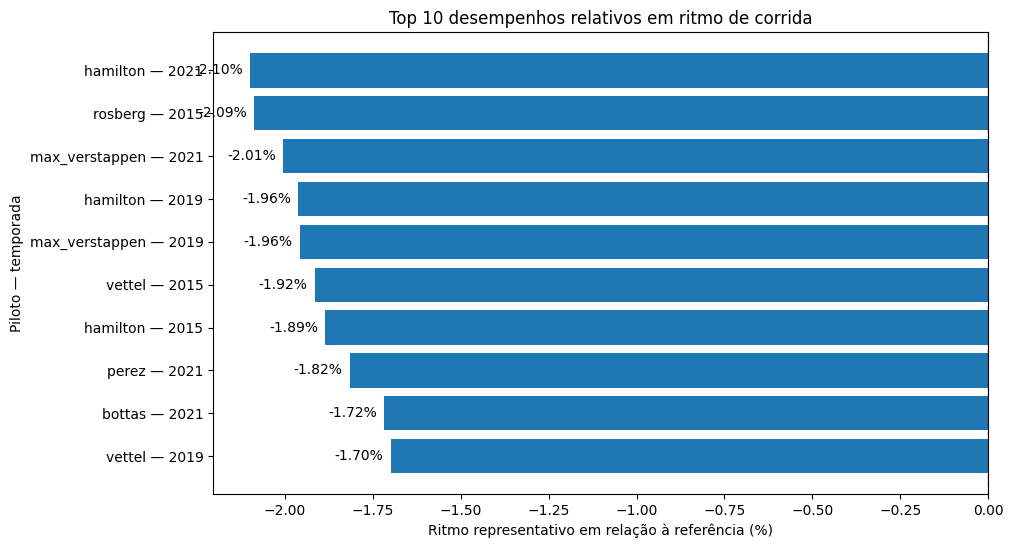

In [81]:
top_ritmos_plot = (
    top_ritmos
    .sort_values(
        "ritmo_representativo_pct",
        ascending=False
    )
    .copy()
)

plt.figure(figsize=(10, 6))

barras = plt.barh(
    top_ritmos_plot["piloto_ano"],
    top_ritmos_plot["ritmo_representativo_pct"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Ritmo representativo em relação à referência (%)"
)

plt.ylabel("Piloto — temporada")

plt.title(
    "Top 10 desempenhos relativos em ritmo de corrida"
)

for barra, valor in zip(
    barras,
    top_ritmos_plot["ritmo_representativo_pct"]
):
    plt.text(
        valor - 0.02,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        ha="right"
    )

plt.show()

#### Destaques de ritmo representativo

Considerando apenas pilotos com pelo menos 20 voltas comparáveis,
Lewis Hamilton em 2021 apresentou o maior destaque relativo da amostra,
com ritmo representativo de aproximadamente -2,10% em relação à
referência das mesmas voltas.

Na sequência aparecem Nico Rosberg em 2015 (-2,09%) e Max Verstappen
em 2021 (-2,01%).

Os dez maiores destaques possuem entre 63 e 68 voltas analisadas e
cobertura superior a 92%, reduzindo o risco de o ranking ser explicado
por amostras excepcionalmente pequenas.

Observou-se também concentração dos dez maiores valores nas temporadas
de 2015, 2019 e 2021. Esse comportamento é tratado como um padrão
exploratório e não como evidência causal, uma vez que diferenças de
contexto, competitividade e condições de corrida podem influenciar o
desempenho relativo observado.

A métrica representa vantagem relativa aos demais pilotos no contexto
da respectiva corrida e não uma comparação direta de velocidade
absoluta entre temporadas.

### Conclusões — Tempos de volta e ritmo de corrida

A análise demonstrou que os tempos absolutos de volta apresentam forte
assimetria e são influenciados por pit stops e eventos coletivos
extremos, tornando a média simples inadequada como representação direta
do ritmo competitivo.

A investigação permitiu definir voltas comparáveis e construir uma
métrica relativa baseada na mediana do desempenho de cada piloto em
relação aos concorrentes presentes na mesma volta.

Dos 12.589 registros disponíveis, 12.008 (95,38%) foram considerados
comparáveis para a análise de ritmo. A cobertura mediana por
piloto-corrida foi de 95,71%.

O `ritmo_representativo_pct` será utilizado nas análises seguintes como
indicador do desempenho relativo em corrida. Valores negativos
representam desempenho superior à referência da volta e valores
positivos representam desempenho inferior.

A próxima etapa investigará se melhor ritmo representativo está
associado a melhores posições finais e como essa relação se compara ao
efeito observado anteriormente para a posição de largada.

## 5.5 Relação entre ritmo representativo e posição final

Com a métrica de ritmo definida e validada, esta seção avalia sua associação
com o resultado final e compara essa relação com a observada anteriormente
para a posição de largada.


### 5.5.1 Objetivo da análise

Após a construção do `ritmo_representativo_pct`, esta etapa investiga
se o desempenho relativo apresentado pelo piloto durante a corrida está
associado à sua posição final.

A pergunta exploratória é:

> **Pilotos que apresentam melhor ritmo relativo durante a corrida tendem
> a terminar em posições melhores?**

O `ritmo_representativo_pct` corresponde à mediana dos deltas de ritmo
do piloto nas voltas consideradas comparáveis. Valores menores indicam
desempenho superior à referência dos concorrentes presentes nas mesmas
voltas.

Como tanto o ritmo quanto a posição final possuem a mesma direção de
interpretação — valores menores representam melhor desempenho — uma
associação positiva é esperada caso pilotos com melhor ritmo também
tendam a obter melhores posições finais.

Como `position` possui natureza ordinal, a correlação de Spearman será
utilizada como principal medida de associação. A correlação de Pearson
será apresentada como medida complementar.

In [82]:
dados_ritmo_resultado = (
    ritmo_piloto_corrida[
        ritmo_piloto_corrida["position"].notna()
    ]
    .copy()
)

print(
    "Pilotos-corrida disponíveis:",
    len(dados_ritmo_resultado)
)

print(
    "Amostras reduzidas:",
    dados_ritmo_resultado["amostra_reduzida"].sum()
)

Pilotos-corrida disponíveis: 189
Amostras reduzidas: 6


### 5.5.2 Preparação dos dados

Para esta análise são considerados os registros piloto-corrida que
possuem posição final válida e uma métrica de ritmo representativo
calculada.

O conjunto resultante possui **189 observações piloto-corrida**.

Dessas observações, **6 foram previamente classificadas como
`amostra_reduzida`**, por possuírem menos de 20 voltas comparáveis.

Esses casos não são removidos inicialmente. A análise será realizada
primeiro com todas as observações e posteriormente repetida sem as
amostras reduzidas, permitindo avaliar a sensibilidade dos resultados
ao número de voltas disponíveis.

In [83]:
pearson_ritmo = (
    dados_ritmo_resultado[
        ["ritmo_representativo_pct", "position"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

spearman_ritmo = (
    dados_ritmo_resultado[
        ["ritmo_representativo_pct", "position"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    f"Pearson — ritmo × posição final: "
    f"{pearson_ritmo:.3f}"
)

print(
    f"Spearman — ritmo × posição final: "
    f"{spearman_ritmo:.3f}"
)

Pearson — ritmo × posição final: 0.652
Spearman — ritmo × posição final: 0.721


### 5.5.3 Correlação entre ritmo e posição final

Considerando os 189 registros piloto-corrida, foram obtidos:

- **Pearson:** 0,652
- **Spearman:** 0,721

Os resultados indicam associação positiva entre o ritmo representativo
e a posição final.

Como valores menores representam simultaneamente melhor ritmo e melhor
posição final, o sinal positivo indica que pilotos com melhor desempenho
relativo durante a corrida tendem a terminar em posições melhores.

A correlação de Spearman de **0,721** indica uma associação monotônica
forte na amostra analisada.

A correlação, entretanto, não deve ser interpretada como evidência de
causalidade. O resultado demonstra associação entre as variáveis, mas
outros fatores da corrida podem influenciar tanto o ritmo quanto a
posição final.

In [84]:
dados_ritmo_robusto = (
    dados_ritmo_resultado[
        ~dados_ritmo_resultado["amostra_reduzida"]
    ]
    .copy()
)

pearson_robusto = (
    dados_ritmo_robusto[
        ["ritmo_representativo_pct", "position"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

spearman_robusto = (
    dados_ritmo_robusto[
        ["ritmo_representativo_pct", "position"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    f"Observações: {len(dados_ritmo_robusto)}"
)

print(
    f"Pearson — sem amostra reduzida: "
    f"{pearson_robusto:.3f}"
)

print(
    f"Spearman — sem amostra reduzida: "
    f"{spearman_robusto:.3f}"
)

Observações: 183
Pearson — sem amostra reduzida: 0.663
Spearman — sem amostra reduzida: 0.735


### 5.5.4 Análise de sensibilidade

Para verificar se a associação observada poderia estar sendo influenciada
por pilotos com poucas voltas disponíveis, a análise foi repetida
excluindo os registros classificados como `amostra_reduzida`.

Foram mantidas **183 observações piloto-corrida**, todas com pelo menos
20 voltas comparáveis.

Os resultados foram:

| Amostra | Pearson | Spearman |
|---|---:|---:|
| Todos os registros (189) | 0,652 | 0,721 |
| Pelo menos 20 voltas (183) | 0,663 | 0,735 |

Após a retirada das seis amostras reduzidas, as correlações apresentaram
pequeno aumento.

A correlação de Spearman passou de **0,721 para 0,735**, enquanto Pearson
passou de **0,652 para 0,663**.

Essa estabilidade indica que a associação entre ritmo representativo e
posição final não depende dos casos com menor quantidade de voltas.
O resultado permanece consistente quando considerada apenas a amostra
com maior representatividade.

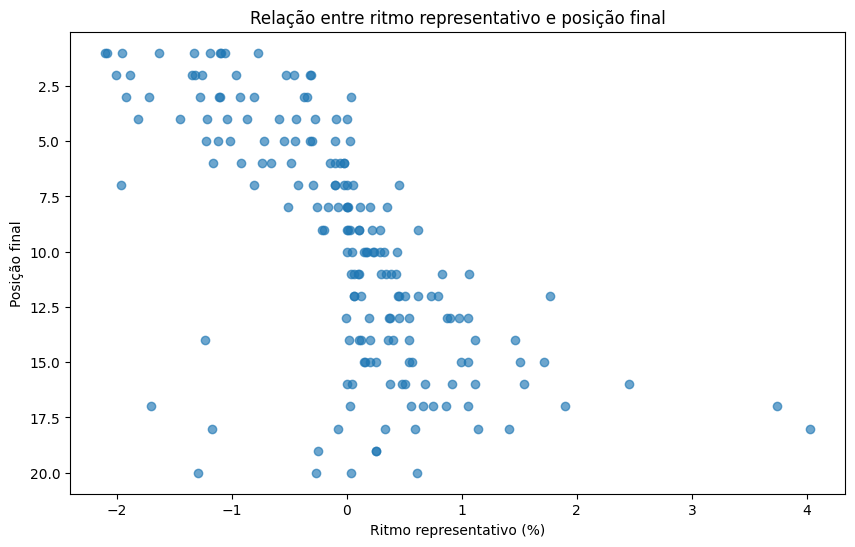

In [85]:
plt.figure(figsize=(10, 6))

plt.scatter(
    dados_ritmo_robusto["ritmo_representativo_pct"],
    dados_ritmo_robusto["position"],
    alpha=0.65
)

plt.xlabel("Ritmo representativo (%)")
plt.ylabel("Posição final")

plt.title(
    "Relação entre ritmo representativo e posição final"
)

# P1 visualmente no topo
plt.gca().invert_yaxis()

plt.show()

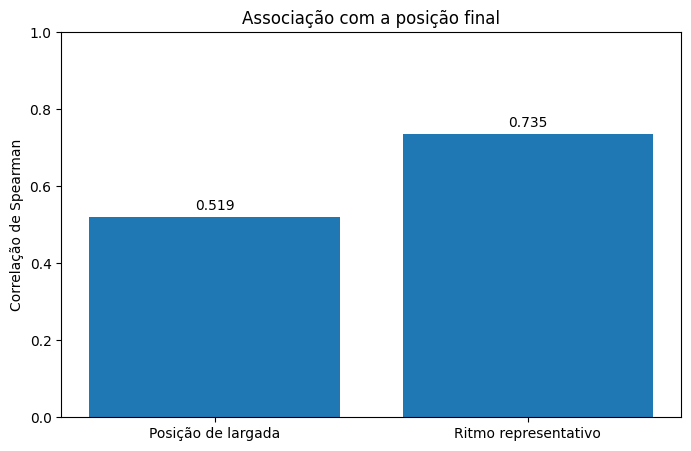

In [86]:
comparacao_correlacoes = pd.DataFrame({
    "Variável": [
        "Posição de largada",
        "Ritmo representativo"
    ],
    "Spearman": [
        0.519,
        spearman_robusto
    ]
})

plt.figure(figsize=(8, 5))

barras = plt.bar(
    comparacao_correlacoes["Variável"],
    comparacao_correlacoes["Spearman"]
)

plt.ylabel("Correlação de Spearman")
plt.title("Associação com a posição final")
plt.ylim(0, 1)

for barra, valor in zip(
    barras,
    comparacao_correlacoes["Spearman"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center"
    )

plt.show()

### 5.5.5 Comparação com a posição de largada e conclusão

Considerando os 189 registros piloto-corrida disponíveis, foi observada
correlação de Pearson de 0,652 e correlação de Spearman de 0,721 entre
ritmo representativo e posição final.

Como valores menores representam simultaneamente melhor ritmo relativo e
melhor posição final, o sinal positivo indica que pilotos com melhor ritmo
tendem a ocupar melhores posições ao término da corrida.

Para avaliar a influência de amostras pequenas, a análise foi repetida
considerando somente piloto-corrida com pelo menos 20 voltas comparáveis.
Nesse conjunto, composto por 183 observações, foram obtidos Pearson de
0,663 e Spearman de 0,735.

A pequena elevação das correlações após a retirada das seis amostras
reduzidas indica que a associação observada não depende desses casos e
permanece consistente na amostra com maior representatividade.

A associação ordinal entre ritmo e posição final (Spearman = 0,735) foi
superior à anteriormente observada entre posição de largada e posição
final (Spearman = 0,519).

Na amostra analisada, portanto, o ritmo representativo apresentou
associação mais forte com o resultado final do que a posição de largada.
Esse resultado não implica relação causal.


### Hipótese exploratória

Os resultados sugerem que a posição de largada possui relação relevante
com o resultado final, porém não determina isoladamente o desempenho da
corrida.

O ritmo representativo apresentou associação mais forte com a posição
final, indicando que o desempenho desenvolvido ao longo da prova pode
contribuir para explicar resultados que não seriam previstos apenas pelo
grid.

Nas próximas análises serão investigados fatores capazes de influenciar
esse ritmo e o resultado da corrida, como estratégia de pit stops, pneus
e condições climáticas.

## 6. Análise de pit stops

Após identificar na seção de ritmo que voltas associadas a pit stops possuem
comportamento distinto das demais, esta seção passa a analisar as paradas
como objeto estratégico.

As análises iniciais do notebook colaborativo foram aproveitadas, mas os
valores extremos não são removidos por uma faixa fixa arbitrária. Primeiro
serão descritos e investigados; somente depois serão definidos critérios
específicos para análises de duração típica, se necessário.


### 6.1 Quantidade de pit stops por temporada

A primeira análise avalia como o número de paradas registradas varia entre
as edições de Interlagos. A contagem representa registros de pit stop e não,
isoladamente, eficiência estratégica.


In [87]:
pit_stops_por_temporada = (
    pit_stops
    .groupby("season")
    .size()
    .reset_index(name="pit_stops")
    .sort_values("season")
)

display(pit_stops_por_temporada)


,season,pit_stops
0,2015,49
1,2016,62
2,2017,69
3,2018,25
4,2019,45
5,2021,79
6,2022,44
7,2023,67
8,2024,35
9,2025,37


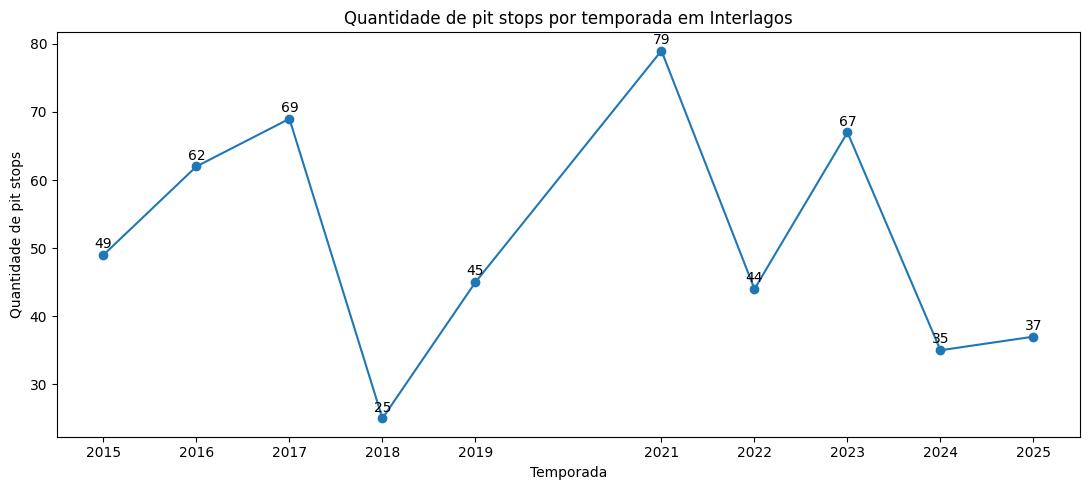

In [88]:
plt.figure(figsize=(11, 5))

plt.plot(
    pit_stops_por_temporada["season"],
    pit_stops_por_temporada["pit_stops"],
    marker="o"
)

for x, y in zip(
    pit_stops_por_temporada["season"],
    pit_stops_por_temporada["pit_stops"]
):
    plt.text(x, y + 1, str(y), ha="center")

plt.title("Quantidade de pit stops por temporada em Interlagos")
plt.xlabel("Temporada")
plt.ylabel("Quantidade de pit stops")
plt.xticks(pit_stops_por_temporada["season"])
plt.tight_layout()
plt.show()


### 6.2 Distribuição da duração dos pit stops

A duração é avaliada por média, mediana, percentis e extremos. Como a média
é sensível a valores muito elevados, a mediana e os percentis são utilizados
como medidas robustas de referência.

Nenhum registro é removido nesta etapa.


In [89]:
pit_stops_eda = pit_stops.copy()

pit_stops_eda["duration"] = pd.to_numeric(
    pit_stops_eda["duration"],
    errors="coerce"
)

display(
    pit_stops_eda["duration"]
    .describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99])
    .round(2)
)

duracao_pit_temporada = (
    pit_stops_eda
    .groupby("season")["duration"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .round(2)
    .reset_index()
)

display(duracao_pit_temporada)


count     512.00
mean      234.72
std       543.87
min        17.67
1%         17.72
5%         17.91
25%        22.83
50%        23.61
75%        25.36
90%      1418.01
95%      1484.59
99%      2009.74
max      2011.27
Name: duration, dtype: float64

,season,quantidade,media,mediana,minimo,maximo
0,2015,49,24.38,23.98,22.94,30.08
1,2016,62,1024.77,1483.13,17.84,2011.27
2,2017,69,20.29,18.93,17.72,34.44
3,2018,25,24.20,23.40,22.55,33.75
4,2019,45,23.69,23.16,22.44,30.76
5,2021,79,21.18,19.44,17.67,41.17
6,2022,44,24.68,23.84,22.87,31.68
7,2023,67,381.24,23.96,18.49,1584.01
8,2024,35,661.29,58.98,24.57,1425.70
9,2025,37,25.12,23.49,22.90,40.08


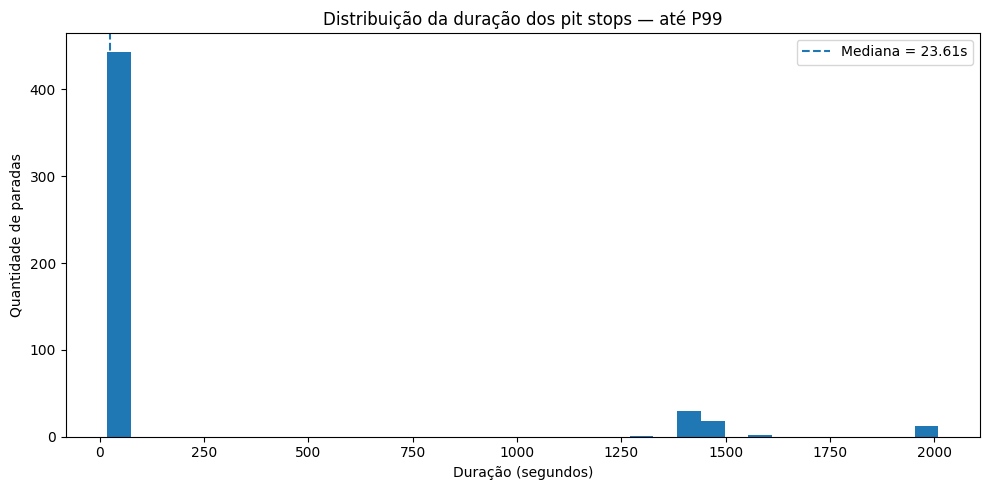

In [90]:
limite_p99_pit = pit_stops_eda["duration"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    pit_stops_eda.loc[
        pit_stops_eda["duration"] <= limite_p99_pit,
        "duration"
    ],
    bins=35
)

plt.axvline(
    pit_stops_eda["duration"].median(),
    linestyle="--",
    label=f"Mediana = {pit_stops_eda['duration'].median():.2f}s"
)

plt.title("Distribuição da duração dos pit stops — até P99")
plt.xlabel("Duração (segundos)")
plt.ylabel("Quantidade de paradas")
plt.legend()
plt.tight_layout()
plt.show()


### 6.3 Investigação das durações extremas

O notebook colaborativo identificou durações muito elevadas em algumas
temporadas. Em vez de classificá-las automaticamente como erros ou aplicar
o intervalo fixo de 15 a 60 segundos, os maiores registros são inspecionados
e comparados aos eventos coletivos extremos encontrados anteriormente na
análise das voltas.

Essa comparação ajuda a verificar se parte das durações excepcionais pode
estar associada ao contexto geral da corrida.


In [91]:
display(
    pit_stops_eda[
        ["season", "round", "driver_id", "lap", "stop", "duration"]
    ]
    .sort_values("duration", ascending=False)
    .head(20)
)


,season,round,driver_id,lap,stop,duration
90,2016,20,kvyat,20,3,2011.266
81,2016,20,gutierrez,20,2,2011.147
77,2016,20,vettel,20,2,2010.637
51,2016,20,hamilton,20,1,2010.361
67,2016,20,button,20,2,2010.062
98,2016,20,rosberg,20,1,2009.747
71,2016,20,max_verstappen,20,2,2009.643
91,2016,20,massa,20,2,2009.630
94,2016,20,ocon,20,1,2009.052
102,2016,20,kevin_magnussen,20,2,2008.979


In [92]:
eventos_coletivos_extremos = (
    voltas_contexto.loc[
        voltas_contexto["evento_coletivo_extremo"],
        ["season", "round", "lap"]
    ]
    .drop_duplicates()
    .assign(evento_coletivo_extremo=True)
)

pit_stops_contexto = pit_stops_eda.merge(
    eventos_coletivos_extremos,
    on=["season", "round", "lap"],
    how="left"
)

pit_stops_contexto["evento_coletivo_extremo"] = (
    pit_stops_contexto["evento_coletivo_extremo"]
    .fillna(False)
    .astype(bool)
)

display(
    pit_stops_contexto[
        [
            "season",
            "round",
            "driver_id",
            "lap",
            "stop",
            "duration",
            "evento_coletivo_extremo"
        ]
    ]
    .sort_values("duration", ascending=False)
    .head(30)
)


C:\Users\vinic\AppData\Local\Temp\ipykernel_26292\4024650551.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,season,round,driver_id,lap,stop,duration,evento_coletivo_extremo
90,2016,20,kvyat,20,3,2011.266,False
81,2016,20,gutierrez,20,2,2011.147,False
77,2016,20,vettel,20,2,2010.637,False
51,2016,20,hamilton,20,1,2010.361,False
67,2016,20,button,20,2,2010.062,False
98,2016,20,rosberg,20,1,2009.747,False
71,2016,20,max_verstappen,20,2,2009.643,False
91,2016,20,massa,20,2,2009.630,False
94,2016,20,ocon,20,1,2009.052,False
102,2016,20,kevin_magnussen,20,2,2008.979,False


In [93]:
# Verifica se o evento coletivo aparece na mesma volta,
# na volta anterior ou na volta seguinte ao registro do pit stop.

eventos_extremos_lookup = set(
    voltas_contexto.loc[
        voltas_contexto["evento_coletivo_extremo"],
        ["season", "round", "lap"]
    ].itertuples(index=False, name=None)
)

# Define explicitamente os pit stops extremos antes de utilizá-los.
# O limiar de 60 s é diagnóstico/contextual e não remove registros da base.
pits_extremos = (
    pit_stops_eda.loc[
        pit_stops_eda["duration"] > 60
    ]
    .copy()
)

print("Pit stops com duração > 60 s:", len(pits_extremos))

pits_extremos_contexto = pits_extremos.copy()

pits_extremos_contexto["evento_mesma_volta"] = (
    pits_extremos_contexto.apply(
        lambda row: (
            row["season"],
            row["round"],
            row["lap"]
        ) in eventos_extremos_lookup,
        axis=1
    )
)

pits_extremos_contexto["evento_volta_seguinte"] = (
    pits_extremos_contexto.apply(
        lambda row: (
            row["season"],
            row["round"],
            row["lap"] + 1
        ) in eventos_extremos_lookup,
        axis=1
    )
)

pits_extremos_contexto["evento_volta_anterior"] = (
    pits_extremos_contexto.apply(
        lambda row: (
            row["season"],
            row["round"],
            row["lap"] - 1
        ) in eventos_extremos_lookup,
        axis=1
    )
)

print(
    "Mesma volta:",
    pits_extremos_contexto["evento_mesma_volta"].sum()
)

print(
    "Evento na volta seguinte:",
    pits_extremos_contexto["evento_volta_seguinte"].sum()
)

print(
    "Evento na volta anterior:",
    pits_extremos_contexto["evento_volta_anterior"].sum()
)


Pit stops com duração > 60 s: 70
Mesma volta: 0
Evento na volta seguinte: 67
Evento na volta anterior: 0


In [94]:
resumo_extremos_contexto = (
    pits_extremos_contexto
    .groupby(["season", "lap"])
    .agg(
        quantidade=("driver_id", "size"),
        pilotos=("driver_id", "nunique"),
        mediana_duration=("duration", "median"),
        evento_mesma_volta=("evento_mesma_volta", "max"),
        evento_volta_seguinte=("evento_volta_seguinte", "max"),
        evento_volta_anterior=("evento_volta_anterior", "max")
    )
    .round(2)
    .reset_index()
)

display(resumo_extremos_contexto)

,season,lap,quantidade,pilotos,mediana_duration,evento_mesma_volta,evento_volta_seguinte,evento_volta_anterior
0,2016,20,18,18,2009.02,False,True,False
1,2016,28,18,18,1484.17,False,True,False
2,2023,1,2,2,1580.37,False,False,False
3,2023,2,15,15,1413.70,False,True,False
4,2024,31,1,1,1283.15,False,False,False
5,2024,32,16,16,1420.26,False,True,False


#### 6.3.1 Relação com os eventos coletivos identificados nas voltas

A inspeção dos pit stops com duração superior a 60 segundos revelou que
esses registros não estão distribuídos aleatoriamente pela amostra.

Foram encontrados **70 registros** nessa condição, concentrados em apenas
seis combinações de temporada e volta.

Os principais grupos foram:

| Temporada | Volta do pit | Pilotos | Mediana da duração |
|---|---:|---:|---:|
| 2016 | 20 | 18 | 2009,02 s |
| 2016 | 28 | 18 | 1484,17 s |
| 2023 | 1 | 2 | 1580,37 s |
| 2023 | 2 | 15 | 1413,70 s |
| 2024 | 31 | 1 | 1283,15 s |
| 2024 | 32 | 16 | 1420,26 s |

A concentração de vários pilotos na mesma volta, apresentando durações
muito superiores às observadas em condições usuais, indica que esses
registros não devem ser tratados automaticamente como erros individuais
ou simplesmente removidos como outliers estatísticos.

Para investigar a relação com os eventos coletivos extremos identificados
na análise dos tempos de volta, foram comparadas a mesma volta do pit stop,
a volta anterior e a volta seguinte.

Dos **70 pit stops com duração superior a 60 segundos**, **67 (95,7%)**
ocorreram imediatamente antes de uma volta anteriormente classificada como
evento coletivo extremo.

Não houve associação com a mesma volta ou com a volta anterior.

O padrão foi observado em diferentes temporadas:

- pit stops registrados na volta 20 de 2016 precederam o evento da volta 21;
- pit stops registrados na volta 28 de 2016 precederam o evento da volta 29;
- pit stops registrados na volta 2 de 2023 precederam o evento da volta 3;
- pit stops registrados na volta 32 de 2024 precederam o evento da volta 33.

Três registros não apresentaram essa correspondência: dois na volta 1 de
2023 e um na volta 31 de 2024.

Os dados demonstram, portanto, uma forte associação temporal entre a maior
parte das durações extremas de pit stop e contextos coletivos extremos
observados nos tempos de volta. Entretanto, as bases utilizadas não
identificam diretamente a causa desses eventos, não sendo possível
classificá-los apenas com esta análise como Safety Car, bandeira vermelha
ou outro tipo específico de interrupção.

#### 6.3.2 Decisão metodológica

As durações extremas serão preservadas na base original, pois representam
informação real da fonte e apresentam forte associação com contextos
coletivos da corrida.

Entretanto, esses registros não representam adequadamente a duração de uma
parada convencional e podem distorcer métricas como média e duração
acumulada de pit stops.

Por esse motivo, as análises seguintes distinguirão dois contextos:

1. **Pit stops convencionais:** utilizados quando o objetivo for comparar
   duração típica das paradas entre pilotos ou corridas.

2. **Pit stops em contexto extremo:** preservados para análises de eventos
   excepcionais e contexto estratégico da corrida.

O limite de 60 segundos utilizado durante a investigação serviu inicialmente
como critério diagnóstico para identificar a cauda extrema da distribuição.
A classificação final também considera a associação temporal encontrada
com eventos coletivos, evitando interpretar automaticamente todo valor
elevado como erro de qualidade.


### 6.4 Pit stops por piloto-corrida

Além da duração individual de cada parada, é construída uma visão na
granularidade piloto-corrida. Essa tabela permitirá relacionar quantidade
de paradas e duração acumulada com posição final, ganho/perda de posições
e ritmo representativo nas análises seguintes.

As métricas de duração permanecem descritivas até que a investigação dos
extremos seja concluída.


In [95]:
pit_stops_analitico = pit_stops_eda.copy()

pit_stops_analitico["pit_duracao_extrema"] = (
    pit_stops_analitico["duration"] > 60
)

pit_stops_analitico["pit_convencional"] = (
    ~pit_stops_analitico["pit_duracao_extrema"]
)

print(
    pit_stops_analitico["pit_duracao_extrema"]
    .value_counts()
)

print(
    "\nPercentual de pits extremos:",
    f"{pit_stops_analitico['pit_duracao_extrema'].mean() * 100:.2f}%"
)

pit_duracao_extrema
False    442
True      70
Name: count, dtype: int64

Percentual de pits extremos: 13.67%


In [96]:
pit_piloto_corrida = (
    pit_stops_analitico
    .groupby(["season", "round", "driver_id"])
    .agg(
        quantidade_pits=("stop", "count"),
        quantidade_pits_convencionais=("pit_convencional", "sum"),
        quantidade_pits_extremos=("pit_duracao_extrema", "sum")
    )
    .reset_index()
)

duracao_pits_convencionais = (
    pit_stops_analitico[
        pit_stops_analitico["pit_convencional"]
    ]
    .groupby(["season", "round", "driver_id"])
    .agg(
        duracao_pit_convencional_total=("duration", "sum"),
        duracao_pit_convencional_media=("duration", "mean"),
        duracao_pit_convencional_mediana=("duration", "median"),
        duracao_pit_convencional_maxima=("duration", "max")
    )
    .reset_index()
)

pit_piloto_corrida = pit_piloto_corrida.merge(
    duracao_pits_convencionais,
    on=["season", "round", "driver_id"],
    how="left"
)

pit_piloto_corrida = pit_piloto_corrida.merge(
    resultados[
        [
            "season",
            "round",
            "driver_id",
            "grid",
            "position",
            "status"
        ]
    ],
    on=["season", "round", "driver_id"],
    how="left"
)

pit_piloto_corrida = pit_piloto_corrida.merge(
    ritmo_piloto_corrida[
        [
            "season",
            "round",
            "driver_id",
            "ritmo_representativo_pct",
            "voltas_analisadas",
            "amostra_reduzida"
        ]
    ],
    on=["season", "round", "driver_id"],
    how="left"
)

pit_piloto_corrida["posicoes_ganhas"] = (
    pit_piloto_corrida["grid"]
    - pit_piloto_corrida["position"]
)

display(pit_piloto_corrida.head(10))

,season,round,driver_id,quantidade_pits,quantidade_pits_convencionais,quantidade_pits_extremos,duracao_pit_convencional_total,duracao_pit_convencional_media,duracao_pit_convencional_mediana,duracao_pit_convencional_maxima,grid,position,status,ritmo_representativo_pct,voltas_analisadas,amostra_reduzida,posicoes_ganhas
0,2015,18,alonso,3,3,0,70.009,23.336333,23.2180,23.810,20,15,+1 Lap,0.539711,67,False,5
1,2015,18,bottas,2,2,0,48.649,24.324500,24.3245,24.913,7,5,+1 Lap,-0.541148,68,False,2
2,2015,18,button,3,3,0,70.909,23.636333,23.4020,24.265,16,14,+1 Lap,0.403668,67,False,2
3,2015,18,ericsson,3,3,0,78.949,26.316333,25.1020,29.148,12,16,+2 Laps,0.047236,66,False,-4
4,2015,18,grosjean,3,3,0,72.220,24.073333,23.9580,24.475,14,8,+1 Lap,-0.079199,67,False,6
5,2015,18,hamilton,3,3,0,70.412,23.470667,23.1480,24.328,2,2,Finished,-1.885755,68,False,0
6,2015,18,hulkenberg,2,2,0,48.208,24.104000,24.1040,24.199,5,6,+1 Lap,-0.061722,68,False,-1
7,2015,18,kvyat,2,2,0,47.785,23.892500,23.8925,24.155,6,7,+1 Lap,-0.105899,68,False,-1
8,2015,18,maldonado,2,2,0,54.197,27.098500,27.0985,30.082,15,10,+1 Lap,0.434524,68,False,5
9,2015,18,massa,3,3,0,71.215,23.738333,23.8870,23.927,8,20,Excluded,-0.264201,67,False,-12


### 6.5 Relação entre quantidade de pit stops e resultado final

Após separar as paradas convencionais dos registros associados a durações
extremas, esta etapa investiga se a quantidade de pit stops apresenta
associação com o resultado final da corrida.

A quantidade total de paradas é mantida independentemente da duração, pois
uma parada realizada em contexto extremo continua representando um evento
estratégico registrado para o piloto.

A análise possui caráter exploratório. Uma quantidade maior ou menor de
pit stops não deve ser interpretada diretamente como uma estratégia melhor
ou pior, pois o número de paradas também pode estar relacionado ao contexto
da corrida, incidentes, pneus utilizados e quantidade de voltas completadas.

In [97]:
distribuicao_quantidade_pits = (
    pit_piloto_corrida["quantidade_pits"]
    .value_counts()
    .sort_index()
    .rename_axis("quantidade_pits")
    .reset_index(name="pilotos_corrida")
)

distribuicao_quantidade_pits["percentual"] = (
    distribuicao_quantidade_pits["pilotos_corrida"]
    / distribuicao_quantidade_pits["pilotos_corrida"].sum()
    * 100
).round(2)

display(distribuicao_quantidade_pits)

,quantidade_pits,pilotos_corrida,percentual
0,1,21,11.29
1,2,70,37.63
2,3,39,20.97
3,4,46,24.73
4,5,10,5.38


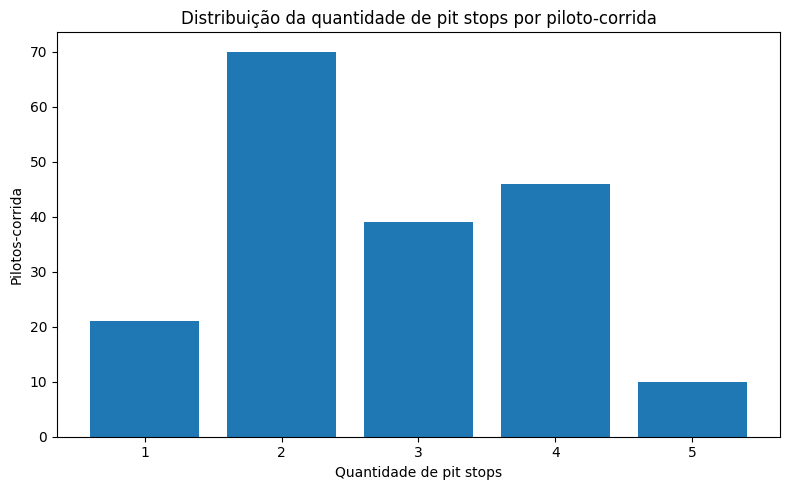

In [98]:
plt.figure(figsize=(8, 5))

plt.bar(
    distribuicao_quantidade_pits["quantidade_pits"].astype(str),
    distribuicao_quantidade_pits["pilotos_corrida"]
)

plt.title("Distribuição da quantidade de pit stops por piloto-corrida")
plt.xlabel("Quantidade de pit stops")
plt.ylabel("Pilotos-corrida")

plt.tight_layout()
plt.show()

#### 6.5.1 Distribuição da quantidade de pit stops

A quantidade de pit stops foi analisada inicialmente na granularidade
piloto-corrida, com o objetivo de compreender quais estratégias de número
de paradas são mais frequentes na amostra.

Foram identificados **186 registros piloto-corrida** com pelo menos um
pit stop registrado.

A distribuição observada foi:

| Quantidade de pit stops | Pilotos-corrida | Percentual |
|---:|---:|---:|
| 1 | 21 | 11,29% |
| 2 | 70 | 37,63% |
| 3 | 39 | 20,97% |
| 4 | 46 | 24,73% |
| 5 | 10 | 5,38% |

A estratégia com **2 pit stops** foi a mais frequente, representando
37,63% dos registros analisados. Em seguida aparecem estratégias com
4 paradas (24,73%) e 3 paradas (20,97%).

Embora duas paradas sejam o comportamento mais frequente, existe
variabilidade relevante entre as corridas, com estratégias variando
entre 1 e 5 pit stops.

Essa distribuição deve ser interpretada como descrição das estratégias
registradas na amostra e não como evidência de que determinada quantidade
de paradas seja superior às demais. O número de pit stops pode depender
de diversos fatores, incluindo contexto da corrida, pneus, condições de
pista, incidentes e quantidade de voltas completadas.

In [99]:
resultado_por_quantidade_pits = (
    pit_piloto_corrida[
        pit_piloto_corrida["position"].notna()
    ]
    .groupby("quantidade_pits")
    .agg(
        observacoes=("driver_id", "size"),
        posicao_final_media=("position", "mean"),
        posicao_final_mediana=("position", "median"),
        posicoes_ganhas_media=("posicoes_ganhas", "mean"),
        posicoes_ganhas_mediana=("posicoes_ganhas", "median")
    )
    .round(2)
    .reset_index()
)

display(resultado_por_quantidade_pits)

,quantidade_pits,observacoes,posicao_final_media,posicao_final_mediana,posicoes_ganhas_media,posicoes_ganhas_mediana
0,1,21,8.43,8.0,2.29,1.0
1,2,70,9.84,10.0,0.26,0.0
2,3,39,11.31,12.0,0.36,0.0
3,4,46,9.17,9.5,0.85,0.0
4,5,10,10.50,10.0,-0.20,0.0


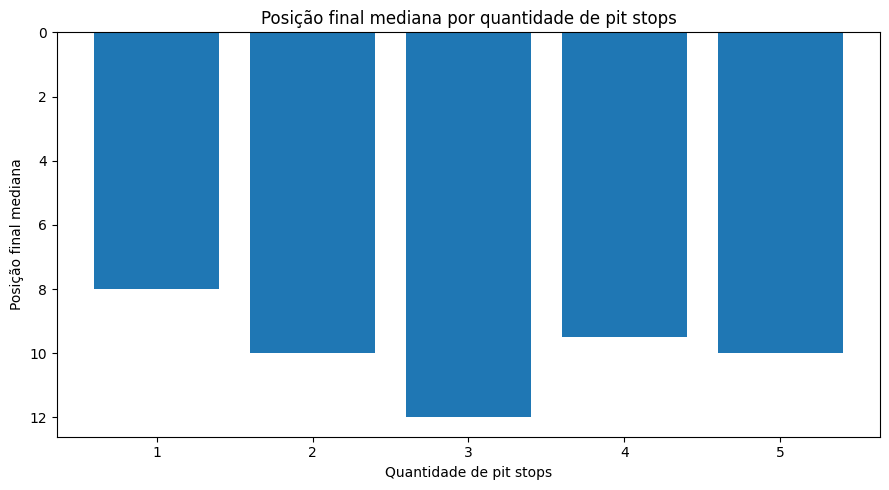

In [100]:
plt.figure(figsize=(9, 5))

plt.bar(
    resultado_por_quantidade_pits["quantidade_pits"].astype(str),
    resultado_por_quantidade_pits["posicao_final_mediana"]
)

plt.title("Posição final mediana por quantidade de pit stops")
plt.xlabel("Quantidade de pit stops")
plt.ylabel("Posição final mediana")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

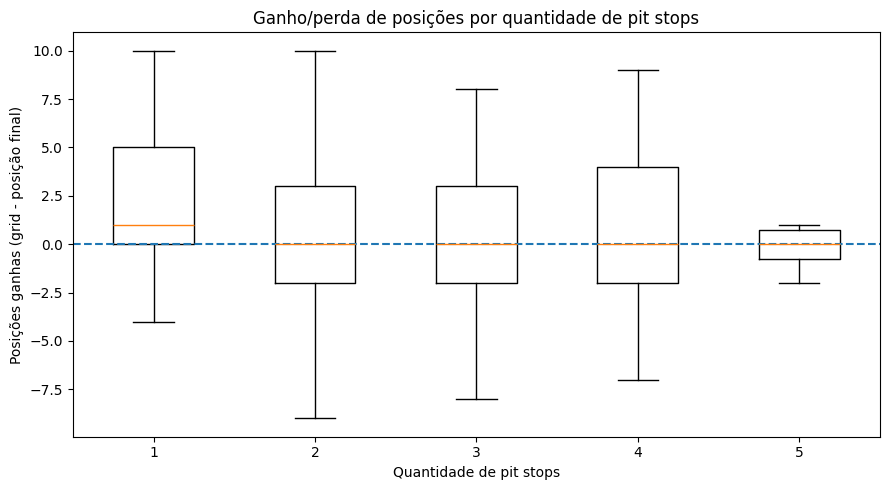

In [101]:
plt.figure(figsize=(9, 5))

dados_boxplot_pits = [
    grupo["posicoes_ganhas"].dropna().values
    for _, grupo in pit_piloto_corrida.groupby("quantidade_pits")
]

labels_boxplot_pits = [
    str(valor)
    for valor in sorted(
        pit_piloto_corrida["quantidade_pits"].dropna().unique()
    )
]

plt.boxplot(
    dados_boxplot_pits,
    tick_labels=labels_boxplot_pits,
    showfliers=False
)

plt.axhline(0, linestyle="--")

plt.title("Ganho/perda de posições por quantidade de pit stops")
plt.xlabel("Quantidade de pit stops")
plt.ylabel("Posições ganhas (grid - posição final)")

plt.tight_layout()
plt.show()

#### 6.5.2 Quantidade de pit stops e desempenho na corrida

Para investigar se o número de paradas apresenta relação com o resultado,
os pilotos foram agrupados pela quantidade de pit stops realizados e
comparados em relação à posição final e ao ganho ou perda de posições
em relação ao grid de largada.

Os resultados foram:

| Pit stops | Observações | Posição média | Posição mediana | Posições ganhas — média | Posições ganhas — mediana |
|---:|---:|---:|---:|---:|---:|
| 1 | 21 | 8,43 | 8,0 | 2,29 | 1,0 |
| 2 | 70 | 9,84 | 10,0 | 0,26 | 0,0 |
| 3 | 39 | 11,31 | 12,0 | 0,36 | 0,0 |
| 4 | 46 | 9,17 | 9,5 | 0,85 | 0,0 |
| 5 | 10 | 10,50 | 10,0 | -0,20 | 0,0 |

Os pilotos com apenas uma parada apresentaram, descritivamente, a melhor
posição final média (8,43), a melhor posição mediana (8ª) e o maior ganho
mediano em relação ao grid (+1 posição).

Entretanto, os resultados não apresentam um comportamento monotônico à
medida que o número de pit stops aumenta.

Por exemplo, pilotos com 4 paradas apresentaram posição final média de
9,17, superior à média de 11,31 observada entre pilotos com 3 paradas.
Da mesma forma, a mediana de posições ganhas foi igual a zero para os
grupos de 2, 3, 4 e 5 paradas.

Além disso, os tamanhos dos grupos são diferentes. A estratégia de uma
parada possui 21 observações e a de cinco paradas apenas 10, enquanto
a estratégia de duas paradas possui 70 registros.

Portanto, os resultados não sustentam uma relação simples em que aumentar
ou reduzir o número de pit stops esteja diretamente associado a melhores
resultados.

A quantidade de paradas deve ser interpretada como uma característica
estratégica e contextual da corrida, e não isoladamente como indicador
de eficiência.

### 6.6 Duração dos pit stops convencionais e desempenho

A duração das paradas é analisada separadamente da quantidade total de
pit stops.

Para evitar que contextos coletivos extremos dominem as métricas de
duração, são consideradas nesta comparação apenas as paradas classificadas
como convencionais.

A análise utiliza principalmente a duração mediana das paradas convencionais
de cada piloto-corrida. A mediana reduz a influência de uma parada
individual excepcionalmente lenta e permite comparar de forma mais robusta
a duração típica das paradas registradas para cada piloto.

Ainda assim, diferenças de duração não devem ser interpretadas isoladamente
como causa do resultado final.

In [102]:
dados_duracao_resultado = (
    pit_piloto_corrida[
        pit_piloto_corrida["duracao_pit_convencional_mediana"].notna()
        & pit_piloto_corrida["position"].notna()
    ]
    .copy()
)

print(
    "Pilotos-corrida disponíveis:",
    len(dados_duracao_resultado)
)

pearson_pit_posicao = (
    dados_duracao_resultado[
        ["duracao_pit_convencional_mediana", "position"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

spearman_pit_posicao = (
    dados_duracao_resultado[
        ["duracao_pit_convencional_mediana", "position"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    f"Pearson — duração do pit × posição final: "
    f"{pearson_pit_posicao:.3f}"
)

print(
    f"Spearman — duração do pit × posição final: "
    f"{spearman_pit_posicao:.3f}"
)

Pilotos-corrida disponíveis: 176
Pearson — duração do pit × posição final: 0.166
Spearman — duração do pit × posição final: 0.212


### 6.7 Pit stops e ritmo representativo

Como o ritmo representativo apresentou forte associação com a posição final,
esta etapa investiga se características dos pit stops também apresentam
associação com o desempenho relativo do piloto durante a corrida.

São avaliadas separadamente a quantidade de paradas e a duração mediana das
paradas convencionais.

O objetivo não é estabelecer causalidade, mas identificar se características
da estratégia de parada apresentam padrões associados ao ritmo observado.

In [103]:
dados_pit_ritmo = (
    pit_piloto_corrida[
        pit_piloto_corrida["ritmo_representativo_pct"].notna()
        & ~pit_piloto_corrida["amostra_reduzida"]
    ]
    .copy()
)

correlacoes_pit_ritmo = pd.DataFrame({
    "variavel": [
        "quantidade_pits",
        "duracao_pit_convencional_mediana"
    ],
    "pearson": [
        dados_pit_ritmo[
            ["quantidade_pits", "ritmo_representativo_pct"]
        ].corr(method="pearson").iloc[0, 1],

        dados_pit_ritmo[
            ["duracao_pit_convencional_mediana", "ritmo_representativo_pct"]
        ].corr(method="pearson").iloc[0, 1]
    ],
    "spearman": [
        dados_pit_ritmo[
            ["quantidade_pits", "ritmo_representativo_pct"]
        ].corr(method="spearman").iloc[0, 1],

        dados_pit_ritmo[
            ["duracao_pit_convencional_mediana", "ritmo_representativo_pct"]
        ].corr(method="spearman").iloc[0, 1]
    ]
})

display(
    correlacoes_pit_ritmo.round(3)
)

,variavel,pearson,spearman
0,quantidade_pits,-0.021,0.016
1,duracao_pit_convencional_mediana,0.141,0.183


### 6.8 Síntese dos resultados de pit stops

A análise dos **512 pit stops** registrados nas dez edições disponíveis de
Interlagos revelou dois aspectos distintos: o comportamento estratégico das
paradas convencionais e a presença de registros extremos associados ao
contexto geral da corrida.

A quantidade de pit stops apresentou variação relevante entre temporadas e
entre pilotos. Na granularidade piloto-corrida, a estratégia de duas paradas
foi a mais frequente, representando **37,63%** dos registros, seguida por
quatro paradas (**24,73%**) e três paradas (**20,97%**).

Apesar dessas diferenças, não foi identificado um comportamento monotônico
entre quantidade de paradas e resultado final. Pilotos com uma parada
apresentaram descritivamente melhores resultados médios na amostra, mas os
demais grupos não seguiram uma progressão consistente conforme o número de
paradas aumentou.

A análise das durações revelou uma distribuição fortemente assimétrica.
Enquanto a duração mediana global foi de aproximadamente **23,61 segundos**,
foram encontrados **70 registros superiores a 60 segundos**, concentrados
principalmente em determinados momentos das corridas de 2016, 2023 e 2024.

A investigação desses registros mostrou que **67 dos 70 casos (95,7%)**
ocorreram imediatamente antes de voltas classificadas anteriormente como
eventos coletivos extremos. Esse resultado demonstra que a maior parte das
durações excepcionais não está distribuída aleatoriamente entre pilotos e
corridas, estando temporalmente associada a contextos coletivos também
observados na base de voltas.

Por esse motivo, esses registros foram preservados como informação da fonte,
mas separados das métricas utilizadas para representar a duração de uma
parada convencional.

Quando consideradas somente as paradas convencionais, a duração mediana
apresentou associação fraca com a posição final
(**Spearman = 0,212**) e com o ritmo representativo
(**Spearman = 0,183**).

A quantidade de pit stops apresentou associação praticamente nula com o
ritmo representativo (**Spearman = 0,016**).

Em conjunto, os resultados indicam que **quantidade e duração dos pit stops,
quando analisadas isoladamente, não apresentam associação forte com o
desempenho geral do piloto na amostra estudada**.

Isso não torna os pit stops irrelevantes do ponto de vista estratégico.
A análise demonstra que seu efeito provavelmente depende do contexto em que
a parada ocorre, incluindo momento da corrida, pneus utilizados e condições
da prova.

Essa conclusão direciona a próxima etapa da EDA para a análise de pneus,
na qual será possível investigar não apenas quantas paradas foram realizadas,
mas também **como os stints foram construídos, quais compostos foram
utilizados e como essas escolhas se relacionam com ritmo e resultado**.

## 7. Pneus e estratégia de stints

A estratégia de pneus é analisada em três granularidades complementares:
**volta**, **stint** e **piloto-corrida**.

Antes das comparações de desempenho, os identificadores da FastF1 são
compatibilizados com os identificadores da Jolpica por meio da dimensão
`driver_mapping`. Em seguida, a estrutura dos stints é validada para evitar
interpretações incorretas de composto, duração e idade acumulada do pneu.

A seção segue esta ordem:

1. preparação e validação da base canônica;
2. reconstrução e consistência dos stints;
3. participação dos compostos;
4. duração dos stints;
5. estratégias por piloto e temporada;
6. composto e ritmo relativo;
7. idade do pneu e evolução dentro do stint;
8. síntese dos principais achados.


### 7.1 Preparação da base canônica de pneus

A FastF1 e a Jolpica utilizam identificadores diferentes para os pilotos.
Por isso, a análise de pneus utiliza uma cópia enriquecida com o
`jolpica_driver_id`.

A associação deve preservar a cardinalidade da base original: cada registro
de pneu deve encontrar exatamente um mapeamento válido por temporada e piloto.


In [104]:
mapping_pneus = (
    driver_mapping.loc[
        driver_mapping["match_status"].eq("MATCH_OK"),
        [
            "season",
            "fastf1_driver_id",
            "jolpica_driver_id",
            "match_status"
        ]
    ]
    .drop_duplicates(["season", "fastf1_driver_id"])
)

pneus_canonicos = (
    pneus
    .merge(
        mapping_pneus,
        left_on=["season", "driver_id"],
        right_on=["season", "fastf1_driver_id"],
        how="left",
        validate="many_to_one"
    )
)

mapeamentos_ausentes = pneus_canonicos["jolpica_driver_id"].isna().sum()

print("Registros originais de pneus:", len(pneus))
print("Registros após o mapeamento:", len(pneus_canonicos))
print("Registros sem mapeamento:", mapeamentos_ausentes)

if len(pneus_canonicos) != len(pneus):
    raise ValueError(
        "A associação com driver_mapping alterou a cardinalidade da base de pneus."
    )

if mapeamentos_ausentes > 0:
    raise ValueError(
        f"Foram encontrados {mapeamentos_ausentes} registros de pneus sem mapeamento."
    )

if (pneus_canonicos["season"] == 2020).any():
    raise ValueError(
        "A base canônica de pneus contém 2020, temporada que deveria ter sido removida."
    )


Registros originais de pneus: 8815
Registros após o mapeamento: 8815
Registros sem mapeamento: 0


### 7.2 Validação e reconstrução dos stints

Um stint deve possuir um único composto e uma sequência coerente de voltas.
Também é necessário distinguir `tyre_life` da quantidade de voltas observadas:
`tyre_life` representa a idade acumulada registrada do pneu e pode começar
acima de 1.


In [105]:
validacao_composto_stint = (
    pneus_canonicos
    .groupby(
        [
            "season",
            "session",
            "jolpica_driver_id",
            "stint"
        ],
        dropna=False
    )
    .agg(
        quantidade_compostos=("compound", "nunique"),
        compostos=("compound", lambda x: sorted(x.dropna().unique())),
        primeira_volta=("lap_number", "min"),
        ultima_volta=("lap_number", "max"),
        registros=("lap_number", "size")
    )
    .reset_index()
)

print(
    "Total de stints identificados:",
    len(validacao_composto_stint)
)

print(
    "Stints com mais de um composto:",
    (validacao_composto_stint["quantidade_compostos"] > 1).sum()
)

display(
    validacao_composto_stint[
        validacao_composto_stint["quantidade_compostos"] > 1
    ]
    .sort_values(
        ["season", "jolpica_driver_id", "stint"]
    )
)

Total de stints identificados: 468
Stints com mais de um composto: 0


,season,session,jolpica_driver_id,stint,quantidade_compostos,compostos,primeira_volta,ultima_volta,registros


In [106]:
validacao_continuidade_stint = (
    pneus_canonicos
    .groupby(
        [
            "season",
            "session",
            "jolpica_driver_id",
            "stint",
            "compound"
        ],
        dropna=False
    )
    .agg(
        primeira_volta=("lap_number", "min"),
        ultima_volta=("lap_number", "max"),
        voltas_observadas=("lap_number", "nunique")
    )
    .reset_index()
)

validacao_continuidade_stint["voltas_esperadas"] = (
    validacao_continuidade_stint["ultima_volta"]
    - validacao_continuidade_stint["primeira_volta"]
    + 1
)

validacao_continuidade_stint["voltas_ausentes"] = (
    validacao_continuidade_stint["voltas_esperadas"]
    - validacao_continuidade_stint["voltas_observadas"]
)

print(
    "Segmentos analisados:",
    len(validacao_continuidade_stint)
)

print(
    "Segmentos com lacunas:",
    (validacao_continuidade_stint["voltas_ausentes"] > 0).sum()
)

display(
    validacao_continuidade_stint[
        validacao_continuidade_stint["voltas_ausentes"] > 0
    ]
    .sort_values(
        "voltas_ausentes",
        ascending=False
    )
    .head(20)
)

Segmentos analisados: 468
Segmentos com lacunas: 0


,season,session,jolpica_driver_id,stint,compound,primeira_volta,ultima_volta,voltas_observadas,voltas_esperadas,voltas_ausentes


In [107]:
validacao_tyre_life = (
    pneus_canonicos
    .groupby(
        [
            "season",
            "session",
            "jolpica_driver_id",
            "stint",
            "compound"
        ],
        dropna=False
    )
    .agg(
        primeira_volta=("lap_number", "min"),
        ultima_volta=("lap_number", "max"),
        voltas_observadas=("lap_number", "nunique"),
        tyre_life_inicial=("tyre_life", "min"),
        tyre_life_final=("tyre_life", "max"),
        registros_tyre_life=("tyre_life", "count")
    )
    .reset_index()
)

display(
    validacao_tyre_life[
        [
            "season",
            "jolpica_driver_id",
            "stint",
            "compound",
            "primeira_volta",
            "ultima_volta",
            "voltas_observadas",
            "tyre_life_inicial",
            "tyre_life_final"
        ]
    ].head(20)
)

,season,jolpica_driver_id,stint,compound,primeira_volta,ultima_volta,voltas_observadas,tyre_life_inicial,tyre_life_final
0,2018,alonso,1,SOFT,1,15,15,1,15
1,2018,alonso,2,MEDIUM,16,54,39,1,39
2,2018,alonso,3,SUPERSOFT,55,69,15,1,15
3,2018,bottas,1,SUPERSOFT,1,18,18,4,21
4,2018,bottas,2,MEDIUM,19,59,41,1,41
5,2018,bottas,3,SOFT,60,71,12,1,12
6,2018,brendon_hartley,1,MEDIUM,1,49,49,1,49
7,2018,brendon_hartley,2,SUPERSOFT,50,70,21,1,21
8,2018,ericsson,1,SUPERSOFT,1,18,18,6,23
9,2018,ericsson,2,MEDIUM,19,20,2,1,2


In [108]:
print("Resumo da quantidade de voltas observadas por stint:")

display(
    validacao_tyre_life["voltas_observadas"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
    .round(2)
)

print("\nResumo do tyre_life final:")

display(
    validacao_tyre_life["tyre_life_final"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
    .round(2)
)

Resumo da quantidade de voltas observadas por stint:


count    468.00
mean      18.84
std       11.72
min        1.00
25%        7.00
50%       20.00
75%       26.00
90%       33.30
95%       37.00
max       53.00
Name: voltas_observadas, dtype: float64


Resumo do tyre_life final:


count    468.00
mean      20.65
std       11.65
min        1.00
25%        9.75
50%       22.00
75%       28.00
90%       35.30
95%       39.00
max       69.00
Name: tyre_life_final, dtype: float64

In [109]:
print(
    "Total de stints:",
    len(validacao_composto_stint)
)

print(
    "Stints com mais de um composto:",
    (validacao_composto_stint["quantidade_compostos"] > 1).sum()
)

print(
    "Segmentos analisados:",
    len(validacao_continuidade_stint)
)

print(
    "Segmentos com lacunas:",
    (validacao_continuidade_stint["voltas_ausentes"] > 0).sum()
)


resumo_inicio_pneu = pd.DataFrame({
    "tipo": [
        "Pneu iniciado com tyre_life = 1",
        "Pneu iniciado com tyre_life > 1"
    ],
    "stints": [
        (validacao_tyre_life["tyre_life_inicial"] == 1).sum(),
        (validacao_tyre_life["tyre_life_inicial"] > 1).sum()
    ]
})

resumo_inicio_pneu["percentual"] = (
    resumo_inicio_pneu["stints"]
    / len(validacao_tyre_life)
    * 100
).round(2)

display(resumo_inicio_pneu)

Total de stints: 468
Stints com mais de um composto: 0
Segmentos analisados: 468
Segmentos com lacunas: 0


,tipo,stints,percentual
0,Pneu iniciado com tyre_life = 1,273,58.33
1,Pneu iniciado com tyre_life > 1,195,41.67


#### 7.2.1 Critérios de interpretação

A variável `voltas_observadas` representa a extensão do stint efetivamente
presente na corrida. Já `tyre_life` é mantida como informação sobre a idade
acumulada registrada do pneu.

Essa distinção evita interpretar automaticamente um pneu que começa com
`tyre_life > 1` como se estivesse na primeira volta de utilização.


### 7.3 Participação dos compostos nos registros de volta

As contagens desta etapa representam **registros de volta utilizando cada
composto**. Portanto, não equivalem ao número de jogos de pneus nem ao número
de stints.

A nomenclatura original da FastF1 é preservada; não é assumida equivalência
direta entre nomes de compostos de temporadas diferentes.


In [110]:
distribuicao_compostos = (
    pneus_canonicos
    .groupby("compound")
    .agg(
        registros_volta=("lap_number", "size"),
        temporadas=("season", "nunique")
    )
    .reset_index()
)

distribuicao_compostos["percentual"] = (
    distribuicao_compostos["registros_volta"]
    / distribuicao_compostos["registros_volta"].sum()
    * 100
).round(2)

distribuicao_compostos = (
    distribuicao_compostos
    .sort_values("registros_volta", ascending=False)
)

display(distribuicao_compostos)

,compound,registros_volta,temporadas,percentual
2,MEDIUM,3555,6,40.33
3,SOFT,2781,6,31.55
1,INTERMEDIATE,1116,1,12.66
0,HARD,948,4,10.75
4,SUPERSOFT,397,1,4.50
5,WET,18,1,0.20


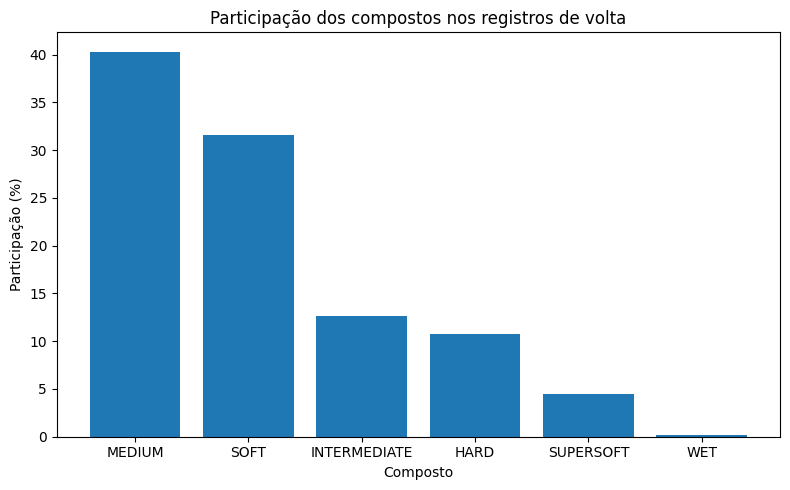

In [111]:
plt.figure(figsize=(8, 5))

plt.bar(
    distribuicao_compostos["compound"],
    distribuicao_compostos["percentual"]
)

plt.title("Participação dos compostos nos registros de volta")
plt.xlabel("Composto")
plt.ylabel("Participação (%)")

plt.tight_layout()
plt.show()

#### 7.3.1 Variação dos compostos por temporada

A distribuição agregada pode ocultar diferenças importantes entre edições.
Por isso, a participação dos compostos também é segmentada por temporada.


In [112]:
compostos_temporada = (
    pneus_canonicos
    .groupby(["season", "compound"])
    .agg(
        registros_volta=("lap_number", "size")
    )
    .reset_index()
)

compostos_temporada["percentual_temporada"] = (
    compostos_temporada["registros_volta"]
    / compostos_temporada.groupby("season")["registros_volta"].transform("sum")
    * 100
).round(2)

display(
    compostos_temporada
    .sort_values(["season", "percentual_temporada"],
                 ascending=[True, False])
)

,season,compound,registros_volta,percentual_temporada
0,2018,MEDIUM,538,40.82
2,2018,SUPERSOFT,397,30.12
1,2018,SOFT,383,29.06
5,2019,SOFT,759,54.80
4,2019,MEDIUM,526,37.98
3,2019,HARD,100,7.22
6,2021,HARD,746,54.85
7,2021,MEDIUM,608,44.71
8,2021,SOFT,6,0.44
11,2022,SOFT,646,51.31


compound,HARD,INTERMEDIATE,MEDIUM,SOFT,SUPERSOFT,WET
season,,,,,,
2018,0.00,0.00,40.82,29.06,30.12,0.00
2019,7.22,0.00,37.98,54.80,0.00,0.00
2021,54.85,0.00,44.71,0.44,0.00,0.00
2022,1.27,0.00,47.42,51.31,0.00,0.00
2023,0.00,0.00,33.12,66.88,0.00,0.00
2024,0.00,98.41,0.00,0.00,0.00,1.59
2025,6.87,0.00,73.46,19.66,0.00,0.00


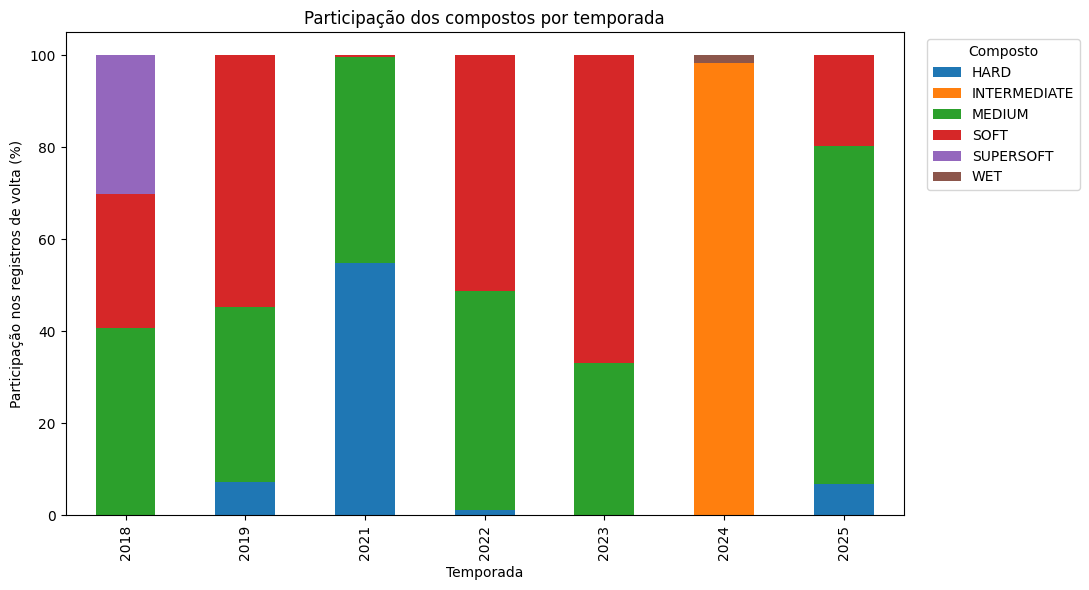

In [113]:
compostos_temporada_pivot = (
    compostos_temporada
    .pivot(
        index="season",
        columns="compound",
        values="percentual_temporada"
    )
    .fillna(0)
)

display(compostos_temporada_pivot.round(2))

compostos_temporada_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Participação dos compostos por temporada")
plt.xlabel("Temporada")
plt.ylabel("Participação nos registros de volta (%)")
plt.legend(title="Composto", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### 7.4 Duração dos stints por composto

A análise passa da granularidade de volta para a granularidade de stint.
A duração é medida por `voltas_observadas`, evitando confundir extensão do
stint com idade acumulada do pneu.

Os resultados são descritivos: duração de stint depende também de estratégia,
momento da troca, condições da pista e distância efetivamente completada.


In [114]:
resumo_stints_composto = (
    validacao_tyre_life
    .groupby("compound")
    .agg(
        quantidade_stints=("stint", "size"),
        voltas_media=("voltas_observadas", "mean"),
        voltas_mediana=("voltas_observadas", "median"),
        voltas_p25=("voltas_observadas", lambda x: x.quantile(0.25)),
        voltas_p75=("voltas_observadas", lambda x: x.quantile(0.75)),
        maior_stint=("voltas_observadas", "max"),
        tyre_life_final_mediano=("tyre_life_final", "median")
    )
    .round(2)
    .reset_index()
    .sort_values("quantidade_stints", ascending=False)
)

display(resumo_stints_composto)

,compound,quantidade_stints,voltas_media,voltas_mediana,voltas_p25,voltas_p75,maior_stint,tyre_life_final_mediano
2,MEDIUM,182,19.53,21.0,7.00,26.00,53,23.0
3,SOFT,167,16.65,19.0,6.50,24.00,41,21.0
0,HARD,50,18.96,19.0,11.25,28.75,40,19.0
1,INTERMEDIATE,47,23.74,27.0,6.00,37.00,37,30.0
4,SUPERSOFT,17,23.35,21.0,18.00,32.00,39,23.0
5,WET,5,3.60,4.0,3.00,4.00,5,10.0


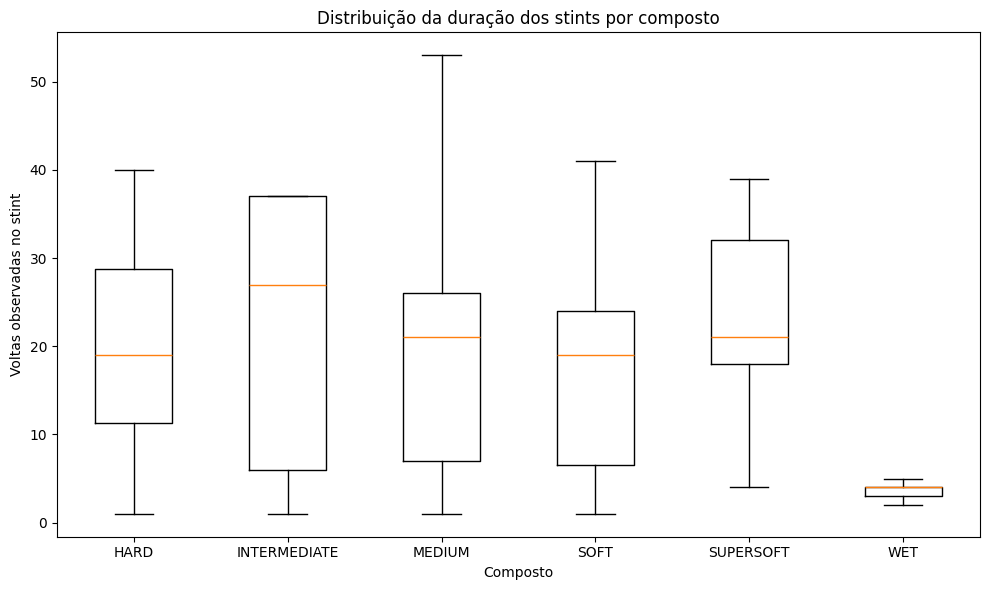

In [115]:
compostos = sorted(
    validacao_tyre_life["compound"]
    .dropna()
    .unique()
)

dados_boxplot = [
    validacao_tyre_life.loc[
        validacao_tyre_life["compound"] == composto,
        "voltas_observadas"
    ].dropna().values
    for composto in compostos
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    dados_boxplot,
    tick_labels=compostos,
    showfliers=True
)

plt.title("Distribuição da duração dos stints por composto")
plt.xlabel("Composto")
plt.ylabel("Voltas observadas no stint")

plt.tight_layout()
plt.show()

### 7.5 Estratégias de pneus por piloto e temporada

A estratégia é reconstruída preservando a ordem dos stints de cada piloto.
Como sequências exatas podem ter baixa frequência, também é analisada a
quantidade de stints por piloto-corrida.


In [116]:
stints_estrategia = (
    validacao_tyre_life
    .sort_values(
        ["season", "session", "jolpica_driver_id", "stint"]
    )
    .copy()
)

estrategia_piloto = (
    stints_estrategia
    .groupby(
        ["season", "session", "jolpica_driver_id"]
    )
    .agg(
        quantidade_stints=("stint", "nunique"),
        sequencia_compostos=(
            "compound",
            lambda x: " → ".join(x.astype(str))
        ),
        compostos_distintos=("compound", "nunique"),
        voltas_observadas=("voltas_observadas", "sum")
    )
    .reset_index()
)

display(
    estrategia_piloto
    .sort_values(
        ["season", "jolpica_driver_id"]
    )
    .head(30)
)

,season,session,jolpica_driver_id,quantidade_stints,sequencia_compostos,compostos_distintos,voltas_observadas
0,2018,R,alonso,3,SOFT → MEDIUM → SUPERSOFT,3,69
1,2018,R,bottas,3,SUPERSOFT → MEDIUM → SOFT,3,71
2,2018,R,brendon_hartley,2,MEDIUM → SUPERSOFT,2,70
3,2018,R,ericsson,2,SUPERSOFT → MEDIUM,2,20
4,2018,R,gasly,2,SUPERSOFT → MEDIUM,2,70
5,2018,R,grosjean,2,SUPERSOFT → MEDIUM,2,71
6,2018,R,hamilton,2,SUPERSOFT → MEDIUM,2,71
7,2018,R,hulkenberg,1,SOFT,1,32
8,2018,R,kevin_magnussen,2,SOFT → SUPERSOFT,2,71
9,2018,R,leclerc,2,SUPERSOFT → MEDIUM,2,71


In [117]:
estrategias_frequentes = (
    estrategia_piloto
    .groupby(
        ["season", "sequencia_compostos"]
    )
    .agg(
        pilotos=("jolpica_driver_id", "nunique")
    )
    .reset_index()
    .sort_values(
        ["season", "pilotos"],
        ascending=[True, False]
    )
)

display(estrategias_frequentes)

,season,sequencia_compostos,pilotos
6,2018,SUPERSOFT → MEDIUM,5
3,2018,SOFT → MEDIUM → SUPERSOFT,4
2,2018,SOFT → MEDIUM,3
8,2018,SUPERSOFT → SOFT,3
0,2018,MEDIUM → SUPERSOFT,1
...,...,...,...
56,2025,MEDIUM,1
57,2025,MEDIUM → SOFT,1
59,2025,SOFT,1
60,2025,SOFT → HARD → MEDIUM → MEDIUM,1


In [118]:
distribuicao_stints = (
    estrategia_piloto
    .groupby(["season", "quantidade_stints"])
    .agg(
        pilotos=("jolpica_driver_id", "nunique")
    )
    .reset_index()
)

distribuicao_stints["percentual_temporada"] = (
    distribuicao_stints["pilotos"]
    / distribuicao_stints.groupby("season")["pilotos"].transform("sum")
    * 100
).round(2)

display(distribuicao_stints)

,season,quantidade_stints,pilotos,percentual_temporada
0,2018,1,1,5.00
1,2018,2,13,65.00
2,2018,3,6,30.00
3,2019,2,1,5.00
4,2019,3,14,70.00
5,2019,4,4,20.00
6,2019,5,1,5.00
7,2021,4,5,25.00
8,2021,5,11,55.00
9,2021,6,4,20.00


quantidade_stints,1,2,3,4,5,6
season,,,,,,
2018,5.00,65.00,30.00,0.00,0.00,0.00
2019,0.00,5.00,70.00,20.00,5.00,0.00
2021,0.00,0.00,0.00,25.00,55.00,20.00
2022,10.00,0.00,50.00,40.00,0.00,0.00
2023,10.53,0.00,0.00,10.53,73.68,5.26
2024,0.00,27.78,61.11,5.56,5.56,0.00
2025,10.00,10.00,65.00,15.00,0.00,0.00


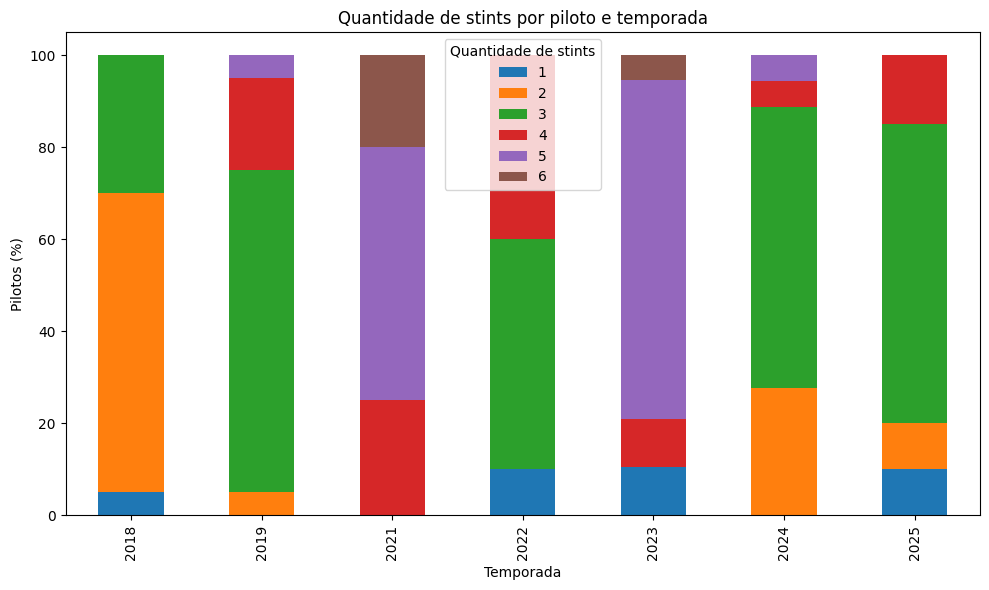

In [119]:
pivot_stints = (
    distribuicao_stints
    .pivot(
        index="season",
        columns="quantidade_stints",
        values="percentual_temporada"
    )
    .fillna(0)
)

display(pivot_stints.round(2))

pivot_stints.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Quantidade de stints por piloto e temporada")
plt.xlabel("Temporada")
plt.ylabel("Pilotos (%)")
plt.legend(title="Quantidade de stints")
plt.tight_layout()
plt.show()

### 7.6 Composto utilizado e ritmo relativo

Os registros de pneus são associados às voltas da Jolpica utilizando temporada,
piloto canonizado e número da volta.

A comparação usa `delta_contexto_volta_pct`, calculado anteriormente em relação
à mediana dos pilotos comparáveis na mesma volta. Valores negativos indicam
ritmo relativamente mais rápido que a mediana daquele contexto; valores
positivos indicam ritmo relativamente mais lento.


In [120]:
pneus_voltas = (
    pneus_canonicos
    .merge(
        voltas_contexto[
            [
                "season",
                "round",
                "driver_id",
                "lap",
                "lap_time_seconds",
                "pit_stop",
                "evento_coletivo_extremo",
                "volta_comparavel",
                "delta_contexto_volta_pct"
            ]
        ],
        left_on=[
            "season",
            "jolpica_driver_id",
            "lap_number"
        ],
        right_on=[
            "season",
            "driver_id",
            "lap"
        ],
        how="left"
    )
)

print("Registros de pneus:", len(pneus_canonicos))

print(
    "Com volta correspondente:",
    pneus_voltas["lap_time_seconds"].notna().sum()
)

print(
    "Sem volta correspondente:",
    pneus_voltas["lap_time_seconds"].isna().sum()
)

Registros de pneus: 8815
Com volta correspondente: 8803
Sem volta correspondente: 12


In [121]:
pneus_voltas_comparaveis = (
    pneus_voltas[
        pneus_voltas["volta_comparavel"]
        .astype("boolean")
        .fillna(False)
        & pneus_voltas["delta_contexto_volta_pct"].notna()
    ]
    .copy()
)

print(
    "Voltas pneu × ritmo disponíveis:",
    len(pneus_voltas_comparaveis)
)

print(
    "Cobertura sobre registros com volta:",
    f"{len(pneus_voltas_comparaveis) / pneus_voltas['lap_time_seconds'].notna().sum() * 100:.2f}%"
)

Voltas pneu × ritmo disponíveis: 8438
Cobertura sobre registros com volta: 95.85%


#### 7.6.1 Ritmo relativo agregado por composto


In [122]:
ritmo_composto = (
    pneus_voltas_comparaveis
    .groupby("compound")
    .agg(
        voltas=("lap_number", "size"),
        pilotos=("jolpica_driver_id", "nunique"),
        temporadas=("season", "nunique"),
        delta_medio_pct=("delta_contexto_volta_pct", "mean"),
        delta_mediano_pct=("delta_contexto_volta_pct", "median"),
        p25=("delta_contexto_volta_pct", lambda x: x.quantile(0.25)),
        p75=("delta_contexto_volta_pct", lambda x: x.quantile(0.75))
    )
    .round(3)
    .reset_index()
    .sort_values("delta_mediano_pct")
)

display(ritmo_composto)

,compound,voltas,pilotos,temporadas,delta_medio_pct,delta_mediano_pct,p25,p75
0,HARD,913,23,4,1.674,-0.940,-1.347,0.009
2,MEDIUM,3409,37,6,2.560,-0.212,-1.030,0.511
1,INTERMEDIATE,1069,18,1,3.980,-0.129,-1.613,1.876
4,SUPERSOFT,387,16,1,0.118,0.197,-2.009,1.374
3,SOFT,2647,35,6,4.652,0.273,-1.144,1.088
5,WET,13,5,1,34.986,40.354,23.847,40.354


A leitura desta tabela deve ser contextual. Um composto não é utilizado nas
mesmas temporadas, condições ou momentos estratégicos que os demais. Assim,
o resultado não deve ser interpretado como ranking de velocidade intrínseca.


#### 7.6.2 Ritmo por composto e temporada


In [123]:
ritmo_composto_temporada = (
    pneus_voltas_comparaveis
    .groupby(["season", "compound"])
    .agg(
        voltas=("lap_number", "size"),
        pilotos=("jolpica_driver_id", "nunique"),
        delta_mediano_pct=("delta_contexto_volta_pct", "median"),
        delta_medio_pct=("delta_contexto_volta_pct", "mean")
    )
    .round(3)
    .reset_index()
)

display(
    ritmo_composto_temporada
    .sort_values(["season", "delta_mediano_pct"])
)

,season,compound,voltas,pilotos,delta_mediano_pct,delta_medio_pct
0,2018,MEDIUM,532,14,-0.554,-0.837
2,2018,SUPERSOFT,387,16,0.197,0.118
1,2018,SOFT,374,14,0.460,0.451
3,2019,HARD,95,5,-1.175,-0.866
4,2019,MEDIUM,506,20,-0.890,1.677
5,2019,SOFT,735,20,0.429,6.520
6,2021,HARD,724,20,-0.999,0.275
7,2021,MEDIUM,552,18,0.654,5.878
8,2021,SOFT,5,2,0.760,2.164
10,2022,MEDIUM,571,18,-0.234,5.684


A segmentação por temporada reduz parte da mistura de contextos presente no
resultado agregado. A mediana é priorizada na interpretação porque o ritmo
relativo pode apresentar assimetria e voltas individualmente muito lentas.


### 7.7 Idade do pneu e ritmo relativo

A hipótese exploratória é verificar se o aumento de `tyre_life` acompanha piora
do ritmo relativo. A análise é descritiva e não pretende estimar causalmente
degradação física do pneu.


In [124]:
pneus_voltas_comparaveis["faixa_tyre_life"] = pd.cut(
    pneus_voltas_comparaveis["tyre_life"],
    bins=[0, 5, 10, 15, 20, 30, 40, float("inf")],
    labels=[
        "1-5",
        "6-10",
        "11-15",
        "16-20",
        "21-30",
        "31-40",
        "41+"
    ]
)

ritmo_idade_pneu = (
    pneus_voltas_comparaveis
    .groupby(
        ["compound", "faixa_tyre_life"],
        observed=True
    )
    .agg(
        voltas=("lap_number", "size"),
        pilotos=("jolpica_driver_id", "nunique"),
        temporadas=("season", "nunique"),
        delta_mediano_pct=("delta_contexto_volta_pct", "median"),
        delta_medio_pct=("delta_contexto_volta_pct", "mean")
    )
    .round(3)
    .reset_index()
)

display(ritmo_idade_pneu)

,compound,faixa_tyre_life,voltas,pilotos,temporadas,delta_mediano_pct,delta_medio_pct
0,HARD,1-5,189,23,4,-0.422,7.843
1,HARD,6-10,186,22,4,-0.752,1.926
2,HARD,11-15,163,22,4,-0.999,-0.268
3,HARD,16-20,130,21,3,-1.100,-0.641
4,HARD,21-30,175,16,3,-1.347,-0.526
5,HARD,31-40,41,8,1,-1.478,-1.281
6,HARD,41+,29,1,1,-1.470,-1.384
7,INTERMEDIATE,1-5,139,18,1,4.604,10.769
8,INTERMEDIATE,6-10,179,18,1,1.371,10.719
9,INTERMEDIATE,11-15,165,18,1,0.019,6.283


In [125]:
ritmo_idade_temporada = (
    pneus_voltas_comparaveis
    .groupby(
        ["season", "compound", "faixa_tyre_life"],
        observed=True
    )
    .agg(
        voltas=("lap_number", "size"),
        pilotos=("jolpica_driver_id", "nunique"),
        delta_mediano_pct=("delta_contexto_volta_pct", "median")
    )
    .round(3)
    .reset_index()
)

display(ritmo_idade_temporada)

,season,compound,faixa_tyre_life,voltas,pilotos,delta_mediano_pct
0,2018,MEDIUM,1-5,67,14,0.188
1,2018,MEDIUM,6-10,65,13,0.044
2,2018,MEDIUM,11-15,65,13,-0.114
3,2018,MEDIUM,16-20,65,13,-0.220
4,2018,MEDIUM,21-30,117,13,-1.030
...,...,...,...,...,...,...
100,2025,SOFT,6-10,65,13,0.089
101,2025,SOFT,11-15,61,13,-0.473
102,2025,SOFT,16-20,41,10,0.971
103,2025,SOFT,21-30,17,5,-1.020


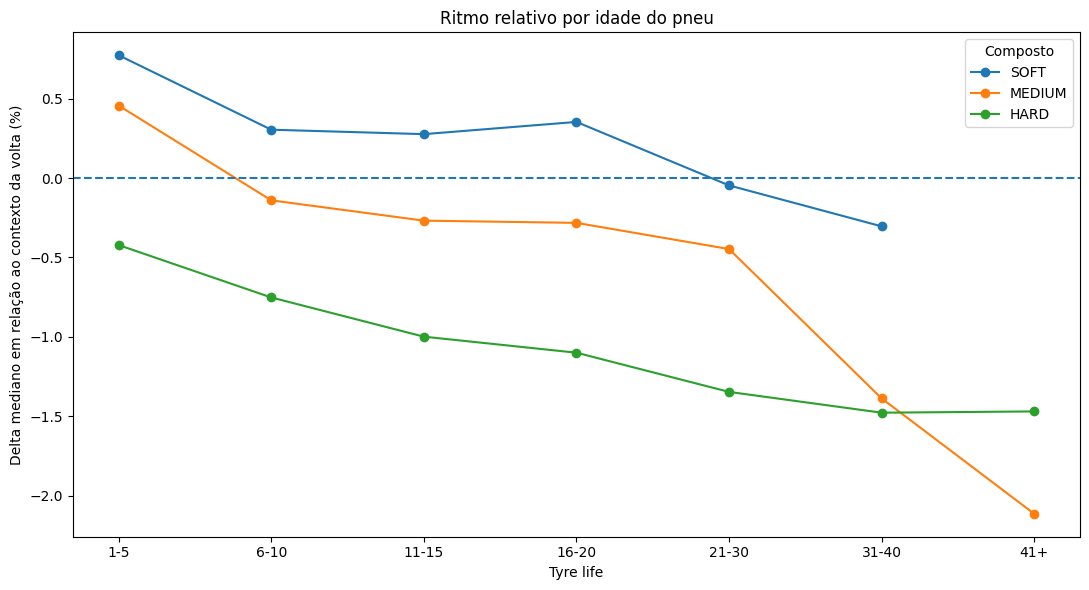

In [126]:
dados_secos = ritmo_idade_pneu[
    ritmo_idade_pneu["compound"].isin(
        ["SOFT", "MEDIUM", "HARD"]
    )
].copy()

plt.figure(figsize=(11, 6))

for composto in ["SOFT", "MEDIUM", "HARD"]:
    dados_composto = dados_secos[
        dados_secos["compound"] == composto
    ]

    plt.plot(
        dados_composto["faixa_tyre_life"].astype(str),
        dados_composto["delta_mediano_pct"],
        marker="o",
        label=composto
    )

plt.axhline(0, linestyle="--")

plt.title("Ritmo relativo por idade do pneu")
plt.xlabel("Tyre life")
plt.ylabel("Delta mediano em relação ao contexto da volta (%)")
plt.legend(title="Composto")

plt.tight_layout()
plt.show()

#### 7.7.1 Evolução do ritmo dentro do próprio stint

Como parte dos stints começa com `tyre_life > 1`, é criada uma medida adicional:
a posição da volta dentro do stint observado.

Cada stint é dividido proporcionalmente em início, meio e final. Essa abordagem
permite estudar a evolução relativa ao longo do stint sem assumir que todos os
pneus começaram a corrida com idade igual a 1.


In [127]:
inicio_stint = (
    validacao_tyre_life[
        [
            "season",
            "session",
            "jolpica_driver_id",
            "stint",
            "compound",
            "primeira_volta"
        ]
    ]
    .drop_duplicates()
)

pneus_voltas_stint = (
    pneus_voltas_comparaveis
    .merge(
        inicio_stint,
        on=[
            "season",
            "session",
            "jolpica_driver_id",
            "stint",
            "compound"
        ],
        how="left",
        validate="many_to_one"
    )
)

pneus_voltas_stint["volta_no_stint"] = (
    pneus_voltas_stint["lap_number"]
    - pneus_voltas_stint["primeira_volta"]
    + 1
)

display(
    pneus_voltas_stint[
        [
            "season",
            "jolpica_driver_id",
            "stint",
            "compound",
            "lap_number",
            "primeira_volta",
            "volta_no_stint",
            "tyre_life"
        ]
    ].head(20)
)

print(
    "Registros:",
    len(pneus_voltas_stint)
)

print(
    "Sem primeira volta:",
    pneus_voltas_stint["primeira_volta"].isna().sum()
)

print(
    "Volta no stint <= 0:",
    (pneus_voltas_stint["volta_no_stint"] <= 0).sum()
)

print(
    "Menor volta no stint:",
    pneus_voltas_stint["volta_no_stint"].min()
)

print(
    "Maior volta no stint:",
    pneus_voltas_stint["volta_no_stint"].max()
)

,season,jolpica_driver_id,stint,compound,lap_number,primeira_volta,volta_no_stint,tyre_life
0,2018,hamilton,1,SUPERSOFT,1,1,1,4
1,2018,hamilton,1,SUPERSOFT,2,1,2,5
2,2018,hamilton,1,SUPERSOFT,3,1,3,6
3,2018,hamilton,1,SUPERSOFT,4,1,4,7
4,2018,hamilton,1,SUPERSOFT,5,1,5,8
5,2018,hamilton,1,SUPERSOFT,6,1,6,9
6,2018,hamilton,1,SUPERSOFT,7,1,7,10
7,2018,hamilton,1,SUPERSOFT,8,1,8,11
8,2018,hamilton,1,SUPERSOFT,9,1,9,12
9,2018,hamilton,1,SUPERSOFT,10,1,10,13


Registros: 8438
Sem primeira volta: 0
Volta no stint <= 0: 0
Menor volta no stint: 1
Maior volta no stint: 53


In [128]:
pneus_voltas_stint["progresso_stint"] = (
    pneus_voltas_stint["volta_no_stint"]
    / pneus_voltas_stint.groupby(
        ["season", "session", "jolpica_driver_id", "stint"]
    )["volta_no_stint"].transform("max")
)

pneus_voltas_stint["fase_stint"] = pd.cut(
    pneus_voltas_stint["progresso_stint"],
    bins=[0, 1/3, 2/3, 1],
    labels=[
        "Início",
        "Meio",
        "Final"
    ],
    include_lowest=True
)


ritmo_fase_stint = (
    pneus_voltas_stint[
        pneus_voltas_stint["compound"].isin(
            ["SOFT", "MEDIUM", "HARD"]
        )
    ]
    .groupby(
        ["compound", "fase_stint"],
        observed=True
    )
    .agg(
        voltas=("lap_number", "size"),
        pilotos=("jolpica_driver_id", "nunique"),
        delta_mediano_pct=("delta_contexto_volta_pct", "median"),
        delta_medio_pct=("delta_contexto_volta_pct", "mean")
    )
    .round(3)
    .reset_index()
)

display(ritmo_fase_stint)

,compound,fase_stint,voltas,pilotos,delta_mediano_pct,delta_medio_pct
0,HARD,Início,290,23,-0.557,4.967
1,HARD,Meio,300,23,-1.062,0.347
2,HARD,Final,323,23,-1.231,-0.048
3,MEDIUM,Início,1091,36,0.203,6.575
4,MEDIUM,Meio,1130,37,-0.290,0.849
5,MEDIUM,Final,1188,37,-0.464,0.500
6,SOFT,Início,828,35,0.450,8.538
7,SOFT,Meio,886,35,0.277,4.044
8,SOFT,Final,933,35,-0.065,1.780


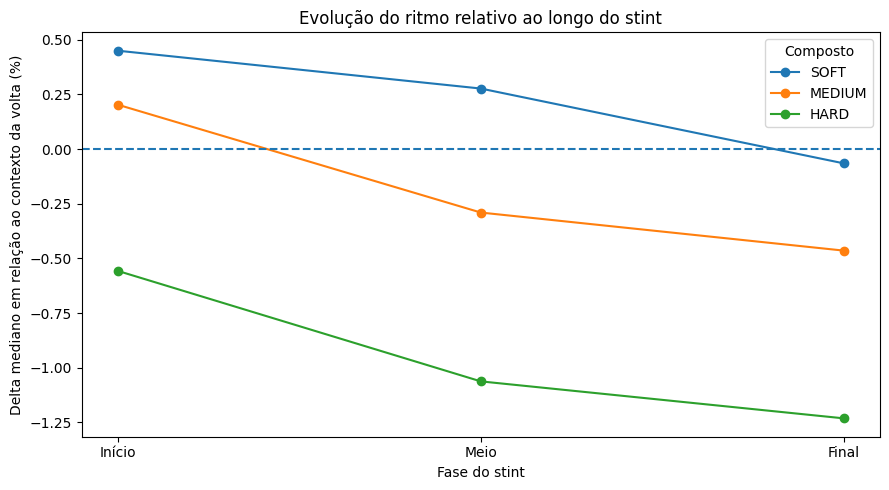

In [129]:
ordem_fases = ["Início", "Meio", "Final"]

plt.figure(figsize=(9, 5))

for composto in ["SOFT", "MEDIUM", "HARD"]:
    dados = (
        ritmo_fase_stint[
            ritmo_fase_stint["compound"] == composto
        ]
        .set_index("fase_stint")
        .reindex(ordem_fases)
    )

    plt.plot(
        ordem_fases,
        dados["delta_mediano_pct"],
        marker="o",
        label=composto
    )

plt.axhline(0, linestyle="--")

plt.title("Evolução do ritmo relativo ao longo do stint")
plt.xlabel("Fase do stint")
plt.ylabel("Delta mediano em relação ao contexto da volta (%)")
plt.legend(title="Composto")

plt.tight_layout()
plt.show()

### 7.8 Síntese da análise de pneus

A seção distingue corretamente registros de volta, stints e idade acumulada do
pneu. A distribuição de compostos e estratégias varia entre temporadas, e as
comparações de ritmo devem permanecer condicionadas ao contexto da corrida.

Os indicadores de ritmo disponíveis são relativos à mesma volta e, isoladamente,
não permitem estimar causalmente degradação do pneu. Para análises futuras,
composto, idade, posição dentro do stint e quantidade de stints podem ser
utilizados em conjunto com clima e demais variáveis de contexto.


## 8. Clima e condições da corrida

As condições climáticas podem afetar aderência, temperatura da pista, escolha
de pneus e decisões estratégicas.

A base climática da FastF1 possui cobertura diferente das bases Jolpica e utiliza
um relógio relativo à sessão. Por isso, esta seção começa pela caracterização
independente do clima e somente depois realiza comparações agregadas com pneus.

Não é realizado merge temporal direto entre clima e voltas sem uma chave
temporal validada.


### 8.1 Cobertura e estrutura da base climática

Primeiro são verificados dimensão, colunas, tipos e quantidade de observações
por temporada. O intervalo de `weather_time_seconds` é usado apenas para
descrever a extensão temporal registrada dentro de cada sessão.


In [130]:
print("Dimensão da base:", clima.shape)

print("\nColunas:")
print(clima.columns.tolist())

print("\nTipos:")
display(
    clima.dtypes
    .astype(str)
    .rename("tipo")
    .to_frame()
)

print("\nPrimeiros registros:")
display(clima.head())

resumo_clima_temporada = (
    clima
    .groupby("season")
    .agg(
        registros=("season", "size"),
        primeiro_registro=("weather_time_seconds", "min"),
        ultimo_registro=("weather_time_seconds", "max")
    )
    .reset_index()
)

resumo_clima_temporada["duracao_minutos"] = (
    (
        resumo_clima_temporada["ultimo_registro"]
        - resumo_clima_temporada["primeiro_registro"]
    ) / 60
).round(1)

display(resumo_clima_temporada)


Dimensão da base: (1117, 17)

Colunas:
['season', 'grand_prix', 'circuit', 'session', 'session_name', 'event_name', 'location', 'event_date', 'weather_time_seconds', 'weather_time_millis', 'air_temp', 'humidity', 'pressure', 'rainfall', 'track_temp', 'wind_direction', 'wind_speed']

Tipos:


,tipo
season,int64
grand_prix,object
circuit,object
session,object
session_name,object
event_name,object
location,object
event_date,datetime64[us]
weather_time_seconds,float64
weather_time_millis,int64



Primeiros registros:


,season,grand_prix,circuit,session,session_name,event_name,location,event_date,weather_time_seconds,weather_time_millis,air_temp,humidity,pressure,rainfall,track_temp,wind_direction,wind_speed
0,2018,Brazilian Grand Prix,Interlagos,R,Race,Brazilian Grand Prix,São Paulo,2018-11-11,19.181,19181,25.0,71.3,924.1,False,43.2,142,3.8
1,2018,Brazilian Grand Prix,Interlagos,R,Race,Brazilian Grand Prix,São Paulo,2018-11-11,79.100,79100,24.9,72.2,924.1,False,43.5,119,1.7
2,2018,Brazilian Grand Prix,Interlagos,R,Race,Brazilian Grand Prix,São Paulo,2018-11-11,139.115,139115,24.9,71.9,924.1,False,43.5,135,1.9
3,2018,Brazilian Grand Prix,Interlagos,R,Race,Brazilian Grand Prix,São Paulo,2018-11-11,199.129,199129,24.8,72.5,924.1,False,42.1,195,2.4
4,2018,Brazilian Grand Prix,Interlagos,R,Race,Brazilian Grand Prix,São Paulo,2018-11-11,259.143,259143,24.9,71.7,924.2,False,41.6,154,1.7


,season,registros,primeiro_registro,ultimo_registro,duracao_minutos
0,2018,125,19.181,7460.883,124.0
1,2019,131,58.100,7858.995,130.0
2,2021,158,18.370,9438.742,157.0
3,2022,167,51.223,10011.319,166.0
4,2023,183,57.616,10978.175,182.0
5,2024,201,22.903,12023.566,200.0
6,2025,152,61.035,9121.811,151.0


### 8.2 Qualidade das variáveis climáticas

A qualidade geral dos datasets já foi tratada na Seção 4. Aqui é feita uma
checagem específica de nulos, cardinalidade e formato da variável `rainfall`,
necessária antes das análises climáticas.


In [131]:
qualidade_clima = pd.DataFrame({
    "tipo": clima.dtypes.astype(str),
    "nulos": clima.isna().sum(),
    "percentual_nulos": (clima.isna().mean() * 100).round(2),
    "valores_unicos": clima.nunique(dropna=True)
})

display(qualidade_clima)

print("\nValores originais encontrados em rainfall:")
display(
    clima["rainfall"]
    .value_counts(dropna=False)
    .rename_axis("rainfall")
    .reset_index(name="registros")
)


,tipo,nulos,percentual_nulos,valores_unicos
season,int64,0,0.0,7
grand_prix,object,0,0.0,2
circuit,object,0,0.0,1
session,object,0,0.0,1
session_name,object,0,0.0,1
event_name,object,0,0.0,2
location,object,0,0.0,1
event_date,datetime64[us],0,0.0,7
weather_time_seconds,float64,0,0.0,1117
weather_time_millis,int64,0,0.0,1117



Valores originais encontrados em rainfall:


,rainfall,registros
0,False,999
1,True,118


### 8.3 Estatísticas descritivas

Temperatura do ar, temperatura da pista, umidade, pressão e vento são
caracterizados globalmente e por temporada. As estatísticas desta etapa são
descritivas e não implicam efeito causal sobre desempenho.


In [132]:
variaveis_clima = [
    "air_temp",
    "humidity",
    "pressure",
    "track_temp",
    "wind_direction",
    "wind_speed"
]

display(
    clima[variaveis_clima]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
    .round(2)
)

resumo_clima_variavel_temporada = (
    clima
    .groupby("season")
    .agg(
        temperatura_ar_media=("air_temp", "mean"),
        temperatura_ar_min=("air_temp", "min"),
        temperatura_ar_max=("air_temp", "max"),
        temperatura_pista_media=("track_temp", "mean"),
        temperatura_pista_min=("track_temp", "min"),
        temperatura_pista_max=("track_temp", "max"),
        umidade_media=("humidity", "mean"),
        umidade_min=("humidity", "min"),
        umidade_max=("humidity", "max"),
        pressao_media=("pressure", "mean"),
        vento_medio=("wind_speed", "mean"),
        vento_max=("wind_speed", "max")
    )
    .round(2)
    .reset_index()
)

display(resumo_clima_variavel_temporada)


,count,mean,std,min,5%,25%,50%,75%,95%,max
air_temp,1117.0,21.45,2.11,16.6,17.3,20.5,21.4,23.1,24.70,25.2
humidity,1117.0,69.86,10.55,54.0,57.0,60.0,70.0,78.2,90.00,92.0
pressure,1117.0,926.08,2.36,921.9,922.0,924.1,926.6,927.7,929.80,930.0
track_temp,1117.0,40.59,9.76,23.2,24.7,30.7,42.2,49.0,53.92,56.3
wind_direction,1117.0,170.97,57.93,0.0,56.4,150.0,171.0,195.0,266.20,354.0
wind_speed,1117.0,1.22,0.68,0.0,0.3,0.7,1.1,1.6,2.50,4.1


,season,temperatura_ar_media,temperatura_ar_min,temperatura_ar_max,temperatura_pista_media,temperatura_pista_min,temperatura_pista_max,umidade_media,umidade_min,umidade_max,pressao_media,vento_medio,vento_max
0,2018,23.77,20.8,25.2,40.07,34.3,44.9,75.41,68.9,87.8,923.93,2.19,4.1
1,2019,21.02,20.1,21.6,46.45,37.8,50.4,60.29,58.0,63.3,924.79,1.29,3.2
2,2021,23.14,22.5,24.0,51.56,42.7,56.3,60.10,54.6,64.2,926.93,0.39,0.8
3,2022,23.01,20.9,25.1,46.05,37.7,53.5,76.08,69.0,85.0,922.16,1.44,2.9
4,2023,20.46,19.6,21.1,46.78,35.8,52.4,58.17,54.0,62.0,927.90,1.31,2.5
5,2024,21.66,20.4,23.4,25.77,23.2,29.5,85.26,75.0,92.0,926.46,0.74,1.8
6,2025,17.35,16.6,18.0,30.69,29.3,32.8,70.57,67.0,75.0,929.71,1.51,2.9


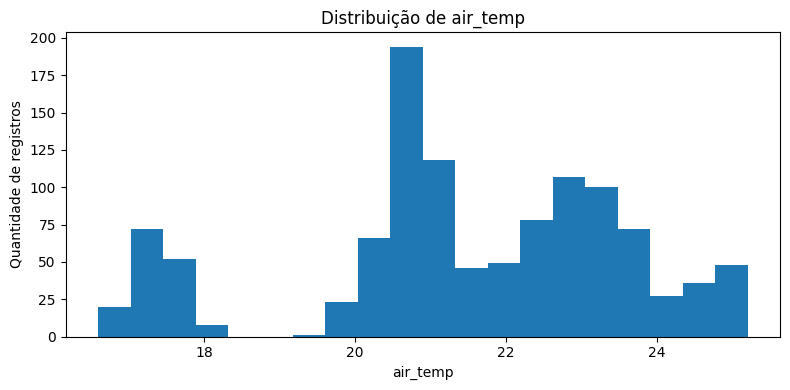

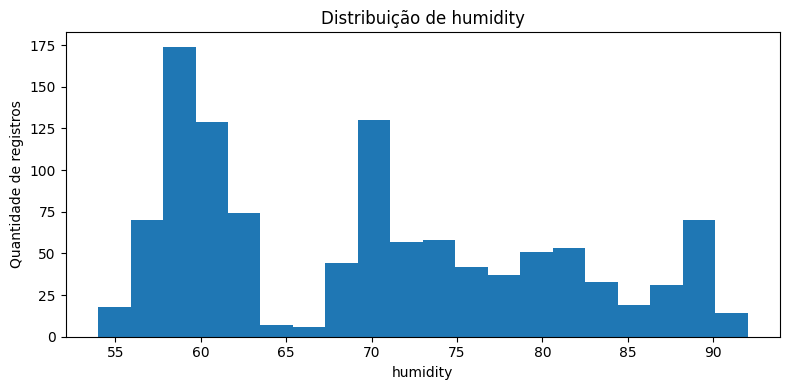

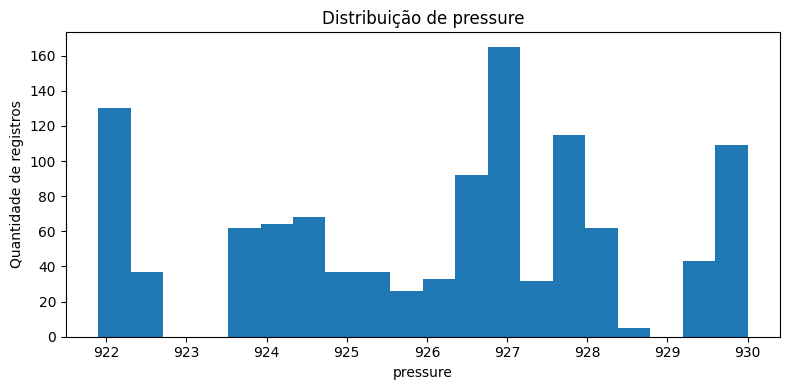

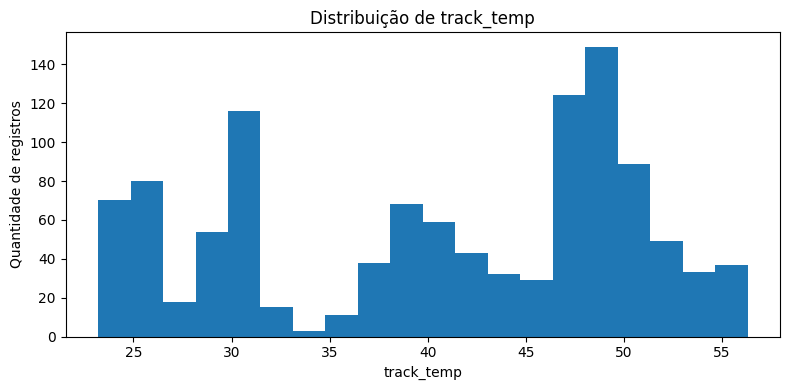

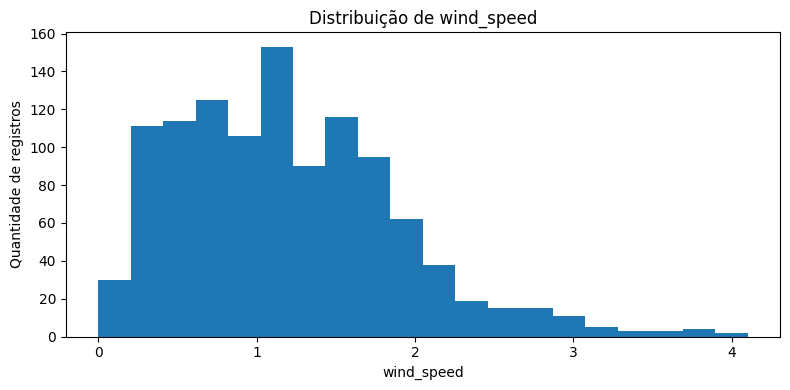

In [133]:
variaveis_clima_grafico = [
    "air_temp",
    "humidity",
    "pressure",
    "track_temp",
    "wind_speed"
]

for coluna in variaveis_clima_grafico:
    plt.figure(figsize=(8, 4))
    plt.hist(clima[coluna].dropna(), bins=20)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Quantidade de registros")
    plt.tight_layout()
    plt.show()


### 8.4 Ocorrência de chuva por temporada

`rainfall` é normalizada para uma representação booleana somente na camada
analítica. A coluna original permanece inalterada.

A proporção de registros com chuva descreve a sessão amostrada pela FastF1;
ela não deve ser interpretada como percentual exato do tempo de pista molhada.


,season,registros,registros_validos,registros_com_chuva,percentual_com_chuva
0,2018,125,125,0,0.0
1,2019,131,131,0,0.0
2,2021,158,158,0,0.0
3,2022,167,167,0,0.0
4,2023,183,183,1,0.55
5,2024,201,201,117,58.21
6,2025,152,152,0,0.0


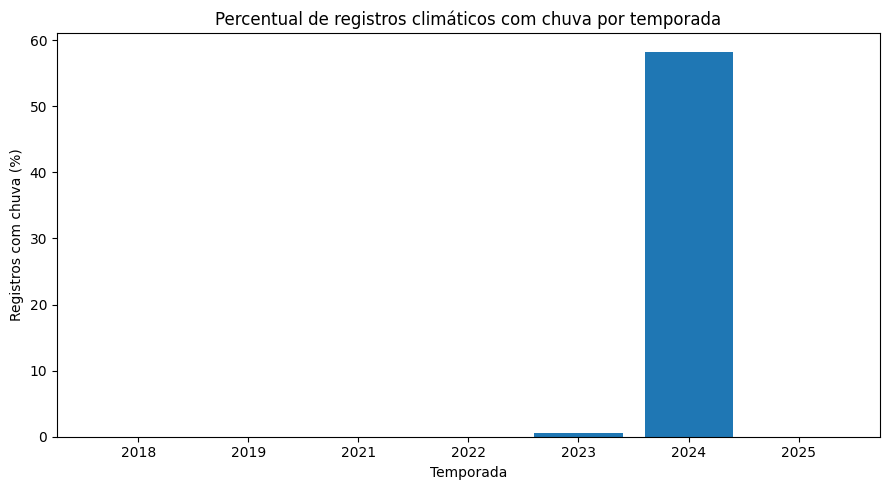

In [134]:
rainfall_original = clima["rainfall"]

if pd.api.types.is_bool_dtype(rainfall_original.dtype):
    rainfall_bool = rainfall_original.astype("boolean")

elif pd.api.types.is_numeric_dtype(rainfall_original.dtype):
    rainfall_bool = rainfall_original.astype("Float64").ne(0).astype("boolean")
    rainfall_bool = rainfall_bool.mask(rainfall_original.isna(), pd.NA)

else:
    mapa_rainfall = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "sim": True,
        "não": False,
        "nao": False
    }

    rainfall_normalizado = (
        rainfall_original
        .astype("string")
        .str.strip()
        .str.lower()
    )

    rainfall_bool = rainfall_normalizado.map(mapa_rainfall).astype("boolean")

    valores_nao_mapeados = sorted(
        rainfall_normalizado[
            rainfall_normalizado.notna()
            & rainfall_bool.isna()
        ].unique()
    )

    if valores_nao_mapeados:
        print(
            "Atenção: valores de rainfall não mapeados:",
            valores_nao_mapeados
        )

clima_analitico = clima.copy()
clima_analitico["rainfall_bool"] = rainfall_bool

chuva_temporada = (
    clima_analitico
    .groupby("season")
    .agg(
        registros=("rainfall_bool", "size"),
        registros_validos=("rainfall_bool", "count"),
        registros_com_chuva=("rainfall_bool", "sum")
    )
    .reset_index()
)

chuva_temporada["percentual_com_chuva"] = (
    chuva_temporada["registros_com_chuva"]
    / chuva_temporada["registros_validos"]
    * 100
).round(2)

display(chuva_temporada)

plt.figure(figsize=(9, 5))
plt.bar(
    chuva_temporada["season"].astype(str),
    chuva_temporada["percentual_com_chuva"]
)
plt.title("Percentual de registros climáticos com chuva por temporada")
plt.xlabel("Temporada")
plt.ylabel("Registros com chuva (%)")
plt.tight_layout()
plt.show()


### 8.5 Temperatura do ar e temperatura da pista

A relação entre as duas temperaturas é investigada por correlação e gráfico de
dispersão. A correlação é descritiva: insolação, chuva, horário e outras
condições também influenciam a temperatura da pista.


Pearson — ar × pista: 0.444
Spearman — ar × pista: 0.419


C:\Users\vinic\AppData\Local\Temp\ipykernel_26292\3549772845.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,season,registros,pearson,spearman
0,2018,125.0,0.766,0.669
1,2019,131.0,0.586,0.210
2,2021,158.0,0.769,0.761
3,2022,167.0,0.976,0.965
4,2023,183.0,0.831,0.646
5,2024,201.0,0.748,0.763
6,2025,152.0,0.751,0.695


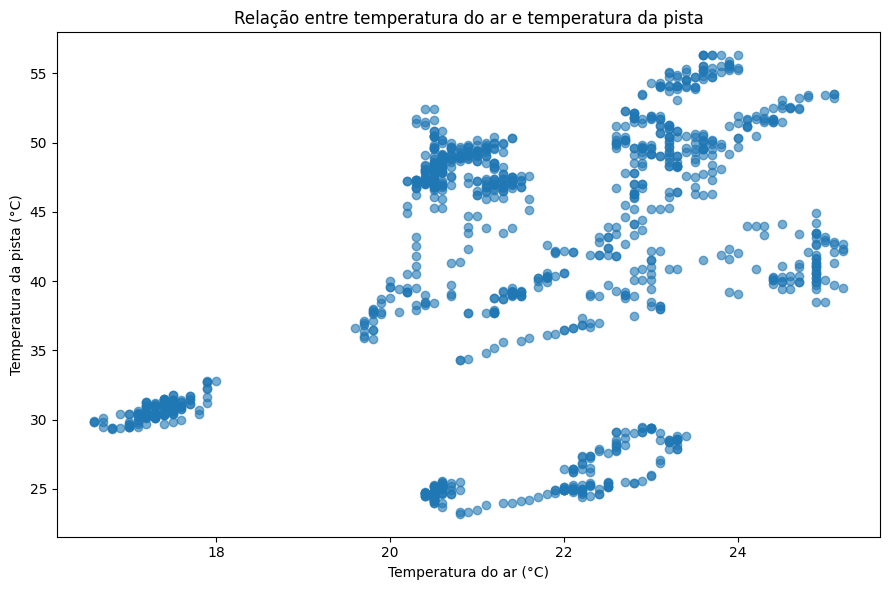

In [135]:
dados_temperatura = (
    clima[
        ["season", "air_temp", "track_temp"]
    ]
    .dropna()
    .copy()
)

pearson_temp = (
    dados_temperatura[
        ["air_temp", "track_temp"]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

spearman_temp = (
    dados_temperatura[
        ["air_temp", "track_temp"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(f"Pearson — ar × pista: {pearson_temp:.3f}")
print(f"Spearman — ar × pista: {spearman_temp:.3f}")

correlacao_temp_temporada = (
    dados_temperatura
    .groupby("season")
    .apply(
        lambda grupo: pd.Series({
            "registros": len(grupo),
            "pearson": grupo["air_temp"].corr(
                grupo["track_temp"],
                method="pearson"
            ),
            "spearman": grupo["air_temp"].corr(
                grupo["track_temp"],
                method="spearman"
            )
        })
    )
    .reset_index()
)

display(correlacao_temp_temporada.round(3))

plt.figure(figsize=(9, 6))
plt.scatter(
    dados_temperatura["air_temp"],
    dados_temperatura["track_temp"],
    alpha=0.6
)
plt.title("Relação entre temperatura do ar e temperatura da pista")
plt.xlabel("Temperatura do ar (°C)")
plt.ylabel("Temperatura da pista (°C)")
plt.tight_layout()
plt.show()


### 8.6 Contexto agregado de chuva e utilização de pneus

Como pneus e clima compartilham a dimensão de temporada, é possível fazer uma
comparação **agregada** entre a incidência de registros com chuva e a
participação de compostos para pista molhada.

Essa comparação serve para contextualização da edição, não para afirmar que
um registro climático específico causou a escolha de pneu em uma determinada
volta.


In [136]:
pneus_regime_temporada = (
    pneus_canonicos
    .assign(
        composto_molhado=lambda df: df["compound"].isin(
            ["INTERMEDIATE", "WET"]
        )
    )
    .groupby("season")
    .agg(
        registros_pneu=("lap_number", "size"),
        registros_composto_molhado=("composto_molhado", "sum")
    )
    .reset_index()
)

pneus_regime_temporada["pct_composto_molhado"] = (
    pneus_regime_temporada["registros_composto_molhado"]
    / pneus_regime_temporada["registros_pneu"]
    * 100
).round(2)

contexto_clima_pneus = (
    chuva_temporada[
        [
            "season",
            "registros_com_chuva",
            "percentual_com_chuva"
        ]
    ]
    .merge(
        pneus_regime_temporada,
        on="season",
        how="outer",
        validate="one_to_one"
    )
    .sort_values("season")
)

display(contexto_clima_pneus)


,season,registros_com_chuva,percentual_com_chuva,registros_pneu,registros_composto_molhado,pct_composto_molhado
0,2018,0,0.0,1318,0,0.0
1,2019,0,0.0,1385,0,0.0
2,2021,0,0.0,1360,0,0.0
3,2022,0,0.0,1259,0,0.0
4,2023,1,0.55,1108,0,0.0
5,2024,117,58.21,1134,1134,100.0
6,2025,0,0.0,1251,0,0.0


#### 8.6.1 Interpretação — clima e utilização de pneus

A comparação entre os registros climáticos e a utilização de pneus evidencia
uma diferença importante entre as temporadas analisadas.

Entre 2018, 2019, 2021 e 2022 não foram registrados períodos de chuva durante
as sessões analisadas e também não houve utilização de compostos
`INTERMEDIATE` ou `WET`. Em 2023, apenas 1 dos 183 registros climáticos
indicou chuva (0,55%), sem registros de voltas com compostos para pista
molhada. Em 2025, novamente não foram observados registros de chuva nem
utilização desses compostos.

A edição de **2024 apresenta comportamento substancialmente diferente**.
Dos 201 registros climáticos, 117 indicaram chuva, correspondendo a
**58,21% das observações**. Na mesma temporada, os **1.134 registros de pneus
(100%)** utilizaram compostos `INTERMEDIATE` ou `WET`.

Esse resultado é consistente com um cenário de corrida em condições de pista
molhada e ajuda a explicar por que a distribuição de compostos de 2024 difere
fortemente das demais temporadas da amostra.

Entretanto, a comparação é realizada na granularidade da temporada e não
estabelece correspondência temporal entre uma observação meteorológica e o
pneu utilizado em uma volta específica. Além disso, `rainfall = False`
representa ausência de precipitação no instante da medição, mas não significa
necessariamente que a pista estivesse seca naquele momento.

Dessa forma, **2024 deve ser tratado como um regime climático distinto nas
comparações envolvendo pneus**, evitando que suas características específicas
distorçam conclusões sobre o comportamento dos compostos em condições
predominantemente secas.

### 8.7 Limitação do alinhamento temporal entre clima e voltas

A variável `weather_time_seconds` representa o tempo relativo à sessão na
FastF1. Já a base de voltas da Jolpica fornece a duração individual de cada
volta, mas não disponibiliza um timestamp absoluto diretamente equivalente
para determinar o instante exato de conclusão de cada volta.

Consequentemente, **não é realizado um relacionamento temporal direto entre
clima e voltas**, pois isso exigiria assumir que as referências temporais das
duas fontes são naturalmente compatíveis.

Uma possível abordagem futura seria reconstruir uma linha temporal aproximada
a partir do tempo acumulado das voltas e associar cada registro a uma medição
climática anterior utilizando uma estratégia `backward/as-of`.

Entretanto, esse relacionamento continuaria sendo uma aproximação e exigiria
a definição de tolerância temporal e auditoria da defasagem entre os registros.

Por esse motivo, nesta EDA as relações entre clima e pneus são analisadas em
nível agregado de temporada. Uma eventual associação clima × volta deverá ser
tratada como construção analítica estimada, sem alteração ou persistência dos
dados originais da camada Silver.

### 8.8 Síntese dos principais achados sobre clima

A análise climática demonstrou que as edições de Interlagos ocorreram sob
condições ambientais significativamente diferentes, reforçando a necessidade
de considerar o contexto de cada temporada nas análises de desempenho e
estratégia.

A base climática contém **1.117 registros válidos**, distribuídos entre
2018, 2019 e 2021–2025, sem valores ausentes nas variáveis analisadas.
A frequência dos registros é próxima de uma observação por minuto, oferecendo
boa resolução para caracterização das condições gerais das sessões.

As temperaturas apresentaram variação relevante entre as edições. A
temperatura média da pista variou de **25,77 °C em 2024** a **51,56 °C em
2021**, enquanto a umidade média variou de **58,17% em 2023** a **85,26% em
2024**. Essas diferenças mostram que uma média global não representa
adequadamente todas as condições observadas em Interlagos.

A temperatura do ar apresentou associação positiva com a temperatura da
pista. Considerando todos os registros, foram obtidas correlações de
**Pearson = 0,444** e **Spearman = 0,419**. Quando a análise é segmentada por
temporada, as relações são geralmente mais fortes, demonstrando a importância
de controlar o contexto de cada edição antes de interpretar relações
agregadas. Essas associações são descritivas e não representam evidência de
causalidade.

O principal destaque climático da amostra é **2024**. Nessa edição,
**58,21% dos registros meteorológicos indicaram chuva**, enquanto **100% dos
registros de pneus utilizaram `INTERMEDIATE` ou `WET`**. O resultado é
consistente com um regime de corrida em pista molhada e explica parte da forte
diferença observada na estratégia de pneus dessa temporada.

Esse comportamento também demonstra que **clima e estratégia de pneus não
devem ser analisados de forma independente do contexto da corrida**.
Especialmente em 2024, comparar diretamente os compostos utilizados com os de
temporadas predominantemente secas poderia produzir interpretações
enganosas.

Por fim, a ausência de uma referência temporal diretamente compatível entre
FastF1 e Jolpica impede uma associação confirmada entre cada medição climática
e cada volta. Por essa razão, a EDA preserva a análise climática em
granularidades suportadas pelas fontes e documenta qualquer relacionamento
temporal mais detalhado como uma possibilidade futura de aproximação
analítica.

Com esses resultados, o clima passa a ser tratado como uma **variável de
contexto relevante para estratégia e desempenho**, que deverá ser considerada
nas análises combinadas juntamente com posição de largada, ritmo de corrida,
pit stops e estratégia de pneus.

## 9. Análises combinadas

Integrar grid, ritmo representativo, pit stops, pneus e clima de acordo com
a granularidade e a cobertura de cada fonte.


## 10. Correlações, padrões e análise de sensibilidade

Comparar associações entre variáveis e resultado final, distinguindo
correlação de causalidade e repetindo análises relevantes quando houver
amostras reduzidas ou coberturas distintas.


## 11. Insights de negócio e hipóteses para modelagem

Consolidar os padrões exploratórios que respondem ao problema do projeto
e convertê-los em hipóteses testáveis para a etapa de modelagem.


## 12. Limitações

Consolidar limitações de cobertura temporal, diferenças entre fontes,
alinhamento temporal de clima, eventos não observados diretamente e
restrições de interpretação das métricas relativas.


## 13. Conclusão

Sintetizar os principais achados da EDA e indicar quais variáveis e
hipóteses seguirão para a modelagem.
